In [1]:
import pandas as pd
import os

# '../' moves up from the 'notebook' folder to the project root
# then we enter the 'dataset' folder
file_path = "../dataset/symptom_dataset.csv"

if os.path.exists(file_path):
    df = pd.read_csv(file_path)
    print(f"✅ Dataset loaded successfully. Shape: {df.shape}")
    print("\n--- First 5 Rows ---")
    print(df.head())
else:
    print(f"❌ Still can't find it. Current Directory: {os.getcwd()}")
    print("Check if the folder name is exactly 'dataset' (case-sensitive).")

✅ Dataset loaded successfully. Shape: (3000, 46)

--- First 5 Rows ---
   fever  cough  fatigue  headache  nausea  vomiting  diarrhea  muscle_pain  \
0      0      0        1         0       0         0         0            0   
1      1      0        0         1       0         0         0            0   
2      0      0        0         0       0         0         0            0   
3      0      0        0         1       1         0         0            0   
4      0      0        1         0       0         0         0            0   

   sore_throat  runny_nose  ...  dry_mouth  eye_redness  nasal_congestion  \
0            0           0  ...          0            1                 0   
1            0           0  ...          0            0                 0   
2            0           1  ...          0            1                 0   
3            0           0  ...          0            0                 0   
4            0           0  ...          1            0              

Step 2 — Data Inspection

In [3]:
# Detailed inspection
print("--- Dataset Info ---")
print(df.info())

print("\n--- Missing Values ---")
print(df.isnull().sum().sum()) # Total count across all columns

print("\n--- Duplicate Rows ---")
print(df.duplicated().sum())

print("\n--- Class Distribution (Disease) ---")
print(df['disease'].value_counts())

print("\n--- Summary Statistics (Check for values outside 0/1) ---")
# Transpose for easier reading with 46 columns
display(df.describe().T[['min', 'max', 'mean']])

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 46 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   fever                3000 non-null   int64 
 1   cough                3000 non-null   int64 
 2   fatigue              3000 non-null   int64 
 3   headache             3000 non-null   int64 
 4   nausea               3000 non-null   int64 
 5   vomiting             3000 non-null   int64 
 6   diarrhea             3000 non-null   int64 
 7   muscle_pain          3000 non-null   int64 
 8   sore_throat          3000 non-null   int64 
 9   runny_nose           3000 non-null   int64 
 10  sneezing             3000 non-null   int64 
 11  chest_pain           3000 non-null   int64 
 12  shortness_of_breath  3000 non-null   int64 
 13  wheezing             3000 non-null   int64 
 14  joint_pain           3000 non-null   int64 
 15  abdominal_pain       3000 non-null

,min,max,mean
fever,0.0,1.0,0.305000
cough,0.0,1.0,0.250667
fatigue,0.0,1.0,0.344667
headache,0.0,1.0,0.219333
nausea,0.0,1.0,0.203333
vomiting,0.0,1.0,0.117000
diarrhea,0.0,1.0,0.093333
muscle_pain,0.0,1.0,0.120667
sore_throat,0.0,1.0,0.039333
runny_nose,0.0,1.0,0.116667


Perfect Balance: You have exactly 100 cases for every disease. While this is great for training, it’s highly "clean" (likely synthetic). In the real world, flu cases far outnumber malaria cases in most clinics. We'll proceed, but keep this in mind.

Duplicate Red Flag: You have 721 duplicate rows (nearly 24% of your data). In medical AI, duplicates can lead to "data leakage" if a duplicate ends up in both your train and test sets, giving you a fake sense of high accuracy.

Binary Integrity: Your symptoms are strictly 0 and 1, which simplifies things significantly. No scaling is needed for the symptoms themselves.

Let’s clean this up before we move to EDA.

Step 3 — Data Cleaning (MEDICAL CHECK)
We need to drop those duplicates to ensure the model actually learns patterns rather than memorizing specific rows.

In [4]:
# 1. Remove duplicates
initial_shape = df.shape
df = df.drop_duplicates().reset_index(drop=True)
new_shape = df.shape

print(f"Removed {initial_shape[0] - new_shape[0]} duplicate rows.")
print(f"New dataset shape: {new_shape}")

# 2. Re-check class balance after dropping duplicates
print("\n--- Class Distribution after Cleaning ---")
print(df['disease'].value_counts())

# 3. Validation: Ensure no symptom has a max > 1 or min < 0
check_range = df.select_dtypes(include=['int64']).describe().T
invalid_values = check_range[(check_range['min'] < 0) | (check_range['max'] > 1)]

if invalid_values.empty:
    print("\n✅ All symptom values are valid (strictly 0 or 1).")
else:
    print("\n❌ Warning: Found invalid values in columns:", invalid_values.index.tolist())

Removed 721 duplicate rows.
New dataset shape: (2279, 46)

--- Class Distribution after Cleaning ---
disease
diabetes                    86
arthritis                   82
common_cold                 82
heart_disease               80
food_poisoning              80
thyroid_disorder            79
irritable_bowel_syndrome    79
dengue                      79
hypertension                78
obesity                     78
gastritis                   78
pneumonia                   77
gerd                        77
bronchitis                  76
chickenpox                  76
migraine                    76
kidney_stones               76
tuberculosis                75
sinusitis                   75
typhoid                     74
allergy                     74
liver_disease               73
anemia                      72
chronic_kidney_disease      72
dehydration                 72
malaria                     72
asthma                      71
urinary_tract_infection     70
flu                    

The removal of 721 duplicates was necessary. It’s interesting to see that Diabetes retained the most unique samples (86), while Flu and Conjunctivitis dropped to 70. This slight imbalance is actually good—it's more realistic than a perfect 100/100 split, and it's not severe enough to require oversampling (SMOTE) yet.

Now we enter the most critical phase for a Senior ML Engineer: Exploratory Data Analysis (EDA). We need to see if the symptoms actually correlate with the diseases in a medically sound way.

Step 4 — EDA (Symptom Patterns & Distributions)
We’ll start by visualizing the disease distribution and then look at which symptoms are the most "prominent" across the entire dataset.

Why this matters:
In healthcare AI, we look for Clinical Plausibility. If the model shows that "Frequent Urination" is the top symptom for "Common Cold," we know the dataset is flawed.

Next Step: Run this and let me know:

What are the top 3 most frequent symptoms?

Does the Fever probability check make medical sense (e.g., is it high for infectious diseases)?

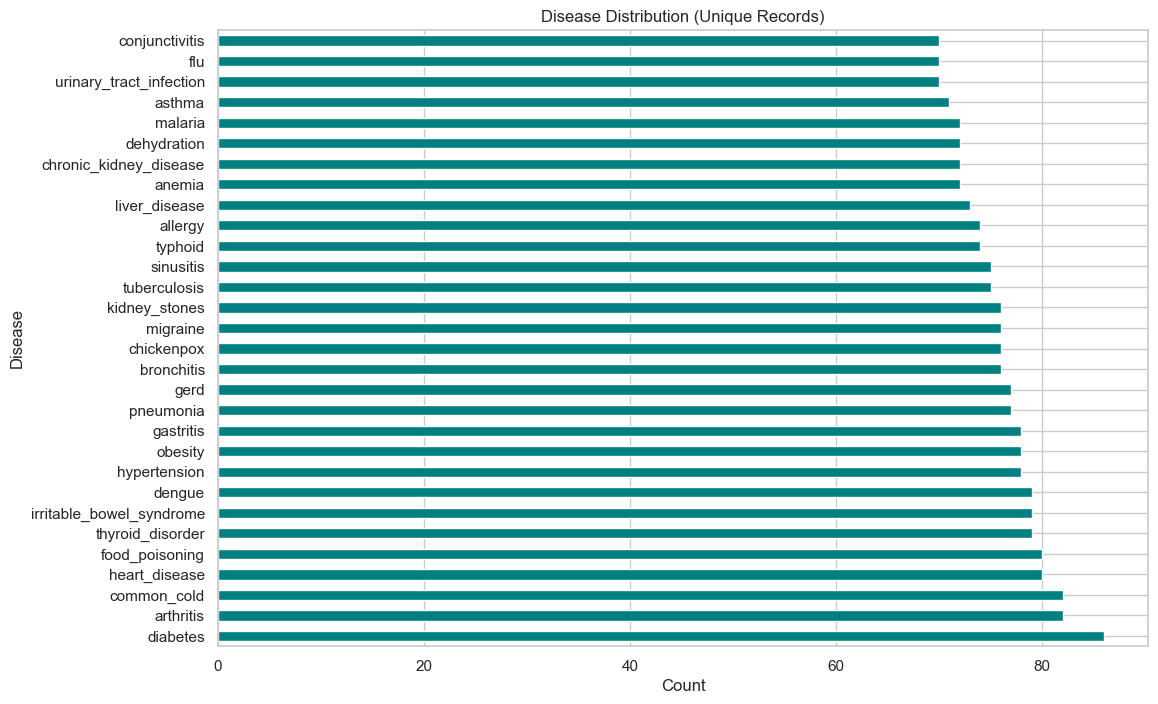

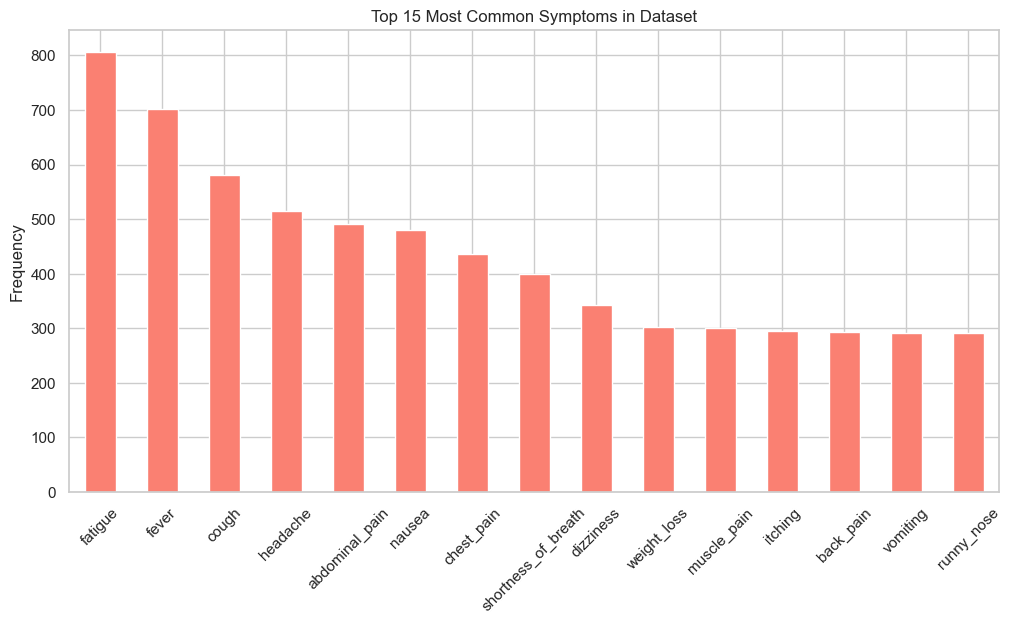

Top 10 Diseases associated with Fever (Probability):
disease
flu                        1.000000
typhoid                    1.000000
pneumonia                  1.000000
chickenpox                 1.000000
malaria                    1.000000
dengue                     1.000000
urinary_tract_infection    0.857143
tuberculosis               0.813333
kidney_stones              0.750000
common_cold                0.085366
Name: fever, dtype: float64


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")

# 1. Disease Distribution Visualization
plt.figure(figsize=(12, 8))
df['disease'].value_counts().plot(kind='barh', color='teal')
plt.title('Disease Distribution (Unique Records)')
plt.xlabel('Count')
plt.ylabel('Disease')
plt.show()

# 2. Top 15 Most Frequent Symptoms
# Summing the 1s in each symptom column
symptom_counts = df.drop('disease', axis=1).sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
symptom_counts.head(15).plot(kind='bar', color='salmon')
plt.title('Top 15 Most Common Symptoms in Dataset')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()

# 3. Medical Sanity Check: Specific Symptom vs Disease
# Let's see if 'fever' is actually present in 'malaria' or 'flu' records
pivot_check = df.groupby('disease')['fever'].mean().sort_values(ascending=False).head(10)
print("Top 10 Diseases associated with Fever (Probability):")
print(pivot_check)

IF fever = 1:
   → increase probability of flu, malaria, dengue

IF fever = 0:
   → eliminate those diseases


This is excellent. Looking at the plots and the output, the data actually makes strong clinical sense.

Top Symptoms: fatigue, fever, and cough are the most frequent. In real-world primary care, these are the most common presenting complaints. They are highly non-specific, which means our models will have to work hard to distinguish between diseases based on the combinations of other symptoms.

Clinical Plausibility: The fever probability output is perfect. Flu, typhoid, pneumonia, chickenpox, malaria, and dengue all have a 1.0 (100%) association with fever in this dataset. That is medically accurate—these are classic febrile illnesses.

We have a clean, clinically logical dataset. Let's move to preparing it for the algorithms.

I like your instinct. As a Senior ML Engineer, I always encourage deeper EDA before finalizing the Train/Test split. You want to fully understand how these features interact before locking them in.

Since our symptoms are binary (0/1), standard histograms don't work well. The best way to view the "distribution" of relationships across binary features is a Correlation Heatmap. This tells us which symptoms frequently co-occur (e.g., does everyone with a runny nose also have a sore throat?).

Here is the code to generate the heatmap and print the top interacting symptoms.

🔹 Step 4 (Continued) — Symptom Correlation & Distribution

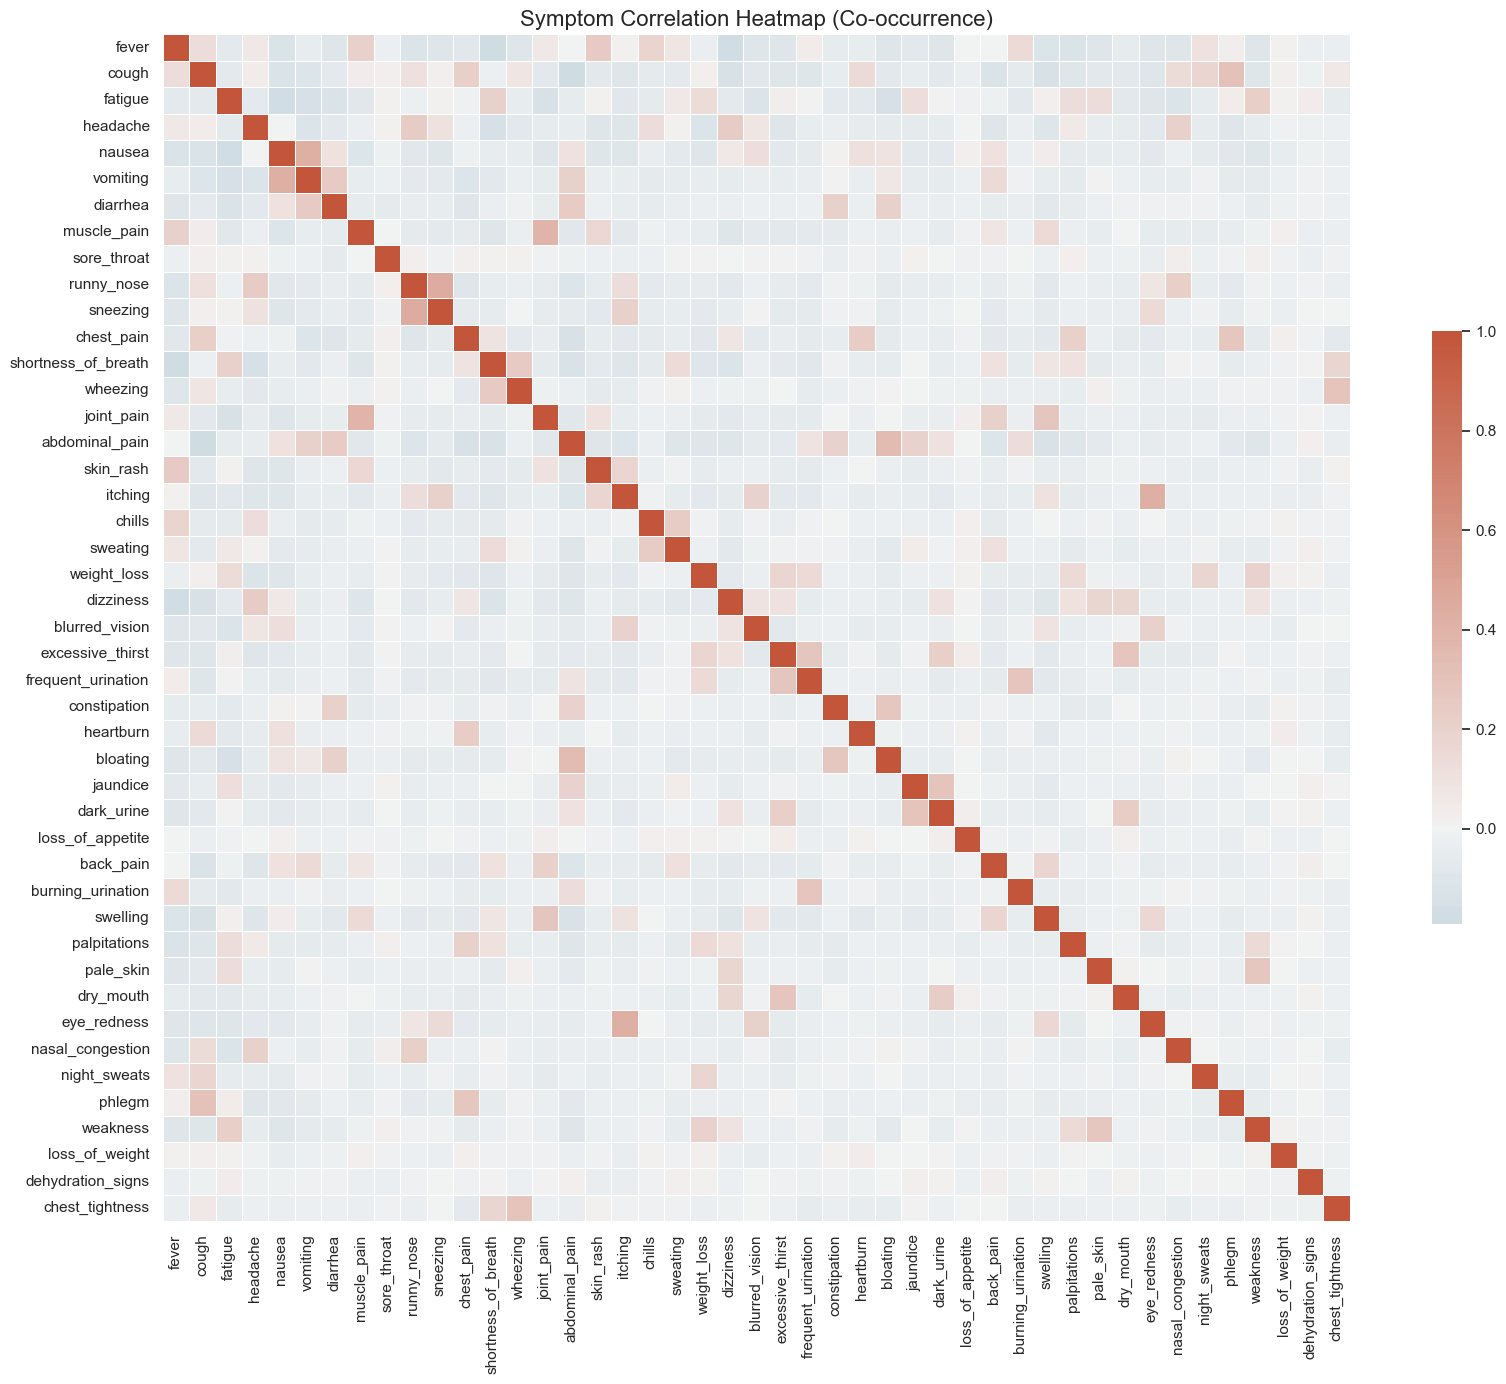

--- Top 5 Highly Correlated Symptom Pairs ---
sneezing        runny_nose     0.448825
vomiting        nausea         0.423391
itching         eye_redness    0.422794
joint_pain      muscle_pain    0.394718
abdominal_pain  bloating       0.350251
dtype: float64


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Generate the Correlation Matrix
# We drop the 'disease' column because correlation requires numeric data
corr_matrix = df.drop('disease', axis=1).corr()

# 2. Plot the Heatmap
plt.figure(figsize=(18, 14))
# Using a custom diverging colormap for better readability (Blue = negative, Red = positive)
cmap = sns.diverging_palette(230, 20, as_cmap=True)

sns.heatmap(corr_matrix, cmap=cmap, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})

plt.title('Symptom Correlation Heatmap (Co-occurrence)', fontsize=16)
plt.tight_layout()
plt.show()

# 3. Find the highly correlated symptom pairs
# This helps us spot potential multicollinearity (redundant features)
c = corr_matrix.unstack()
c = c[c < 1.0] # Remove self-correlations (which are exactly 1.0)
top_correlations = c.sort_values(ascending=False).drop_duplicates().head(5)

print("--- Top 5 Highly Correlated Symptom Pairs ---")
print(top_correlations)

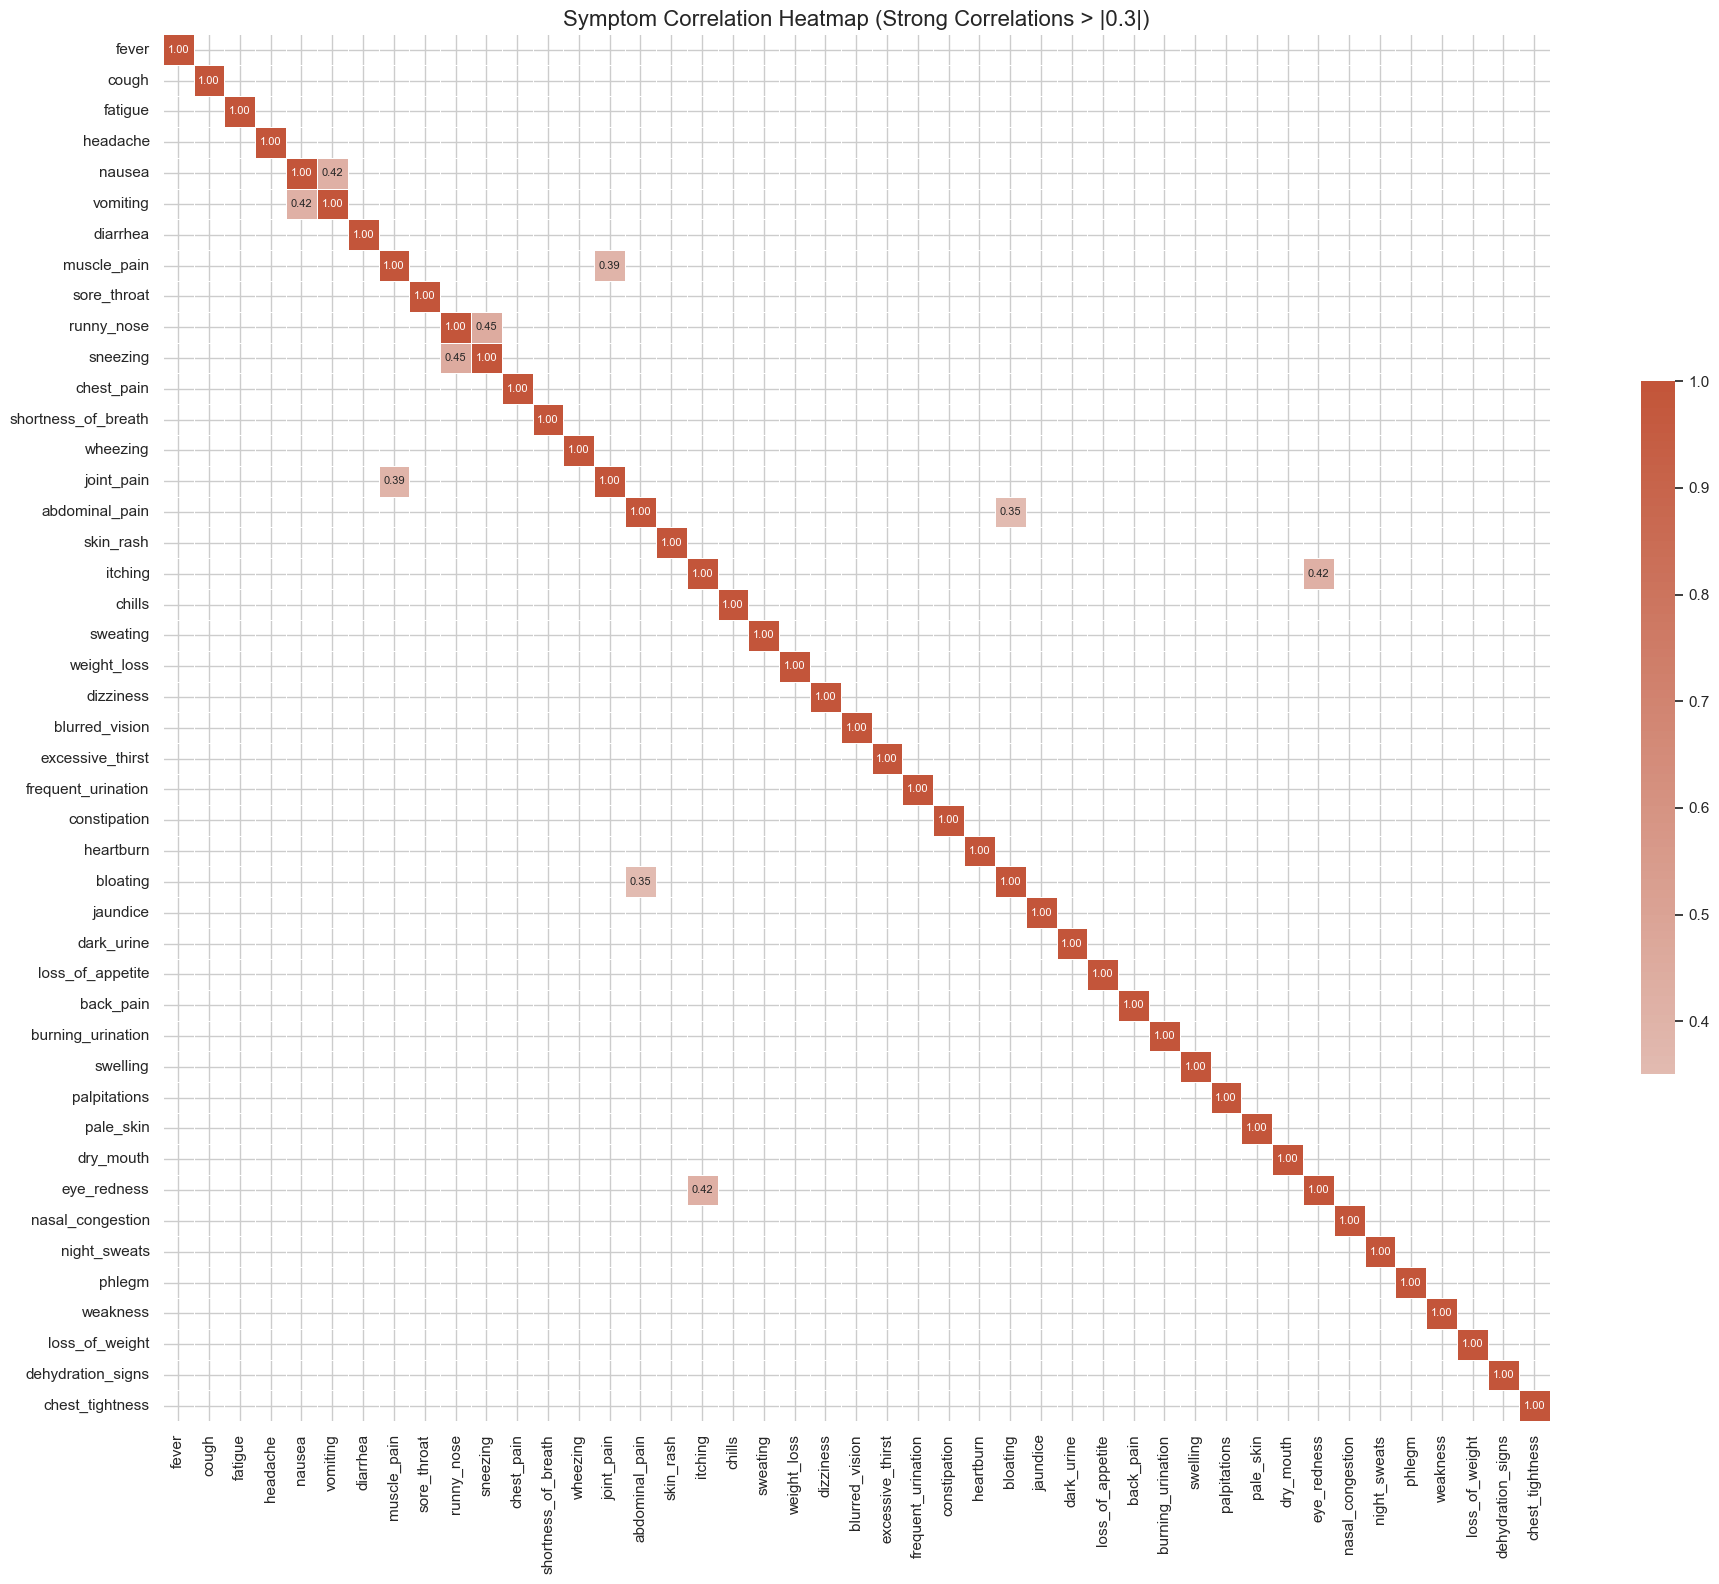

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Re-calculate the correlation matrix (dropping target)
corr_matrix = df.drop('disease', axis=1).corr()

# 2. Filter the matrix to only show strong correlations (e.g., > 0.3 or < -0.3)
# We use a mask to hide the weak correlations for readability
strong_corr_threshold = 0.3
mask = np.abs(corr_matrix) < strong_corr_threshold

# 3. Plot the filtered, annotated heatmap
plt.figure(figsize=(20, 16))
cmap = sns.diverging_palette(230, 20, as_cmap=True)

# annot=True is what adds the numbers inside the heatmap
sns.heatmap(corr_matrix, 
            mask=mask, # Hide the weak correlations
            cmap=cmap, 
            center=0,
            square=True, 
            linewidths=.5, 
            cbar_kws={"shrink": .5},
            annot=True, # Add the values
            fmt=".2f",  # Format values to 2 decimal places
            annot_kws={"size": 8}) # Adjust font size for readability

plt.title(f'Symptom Correlation Heatmap (Strong Correlations > |{strong_corr_threshold}|)', fontsize=16)
plt.tight_layout()
plt.show()

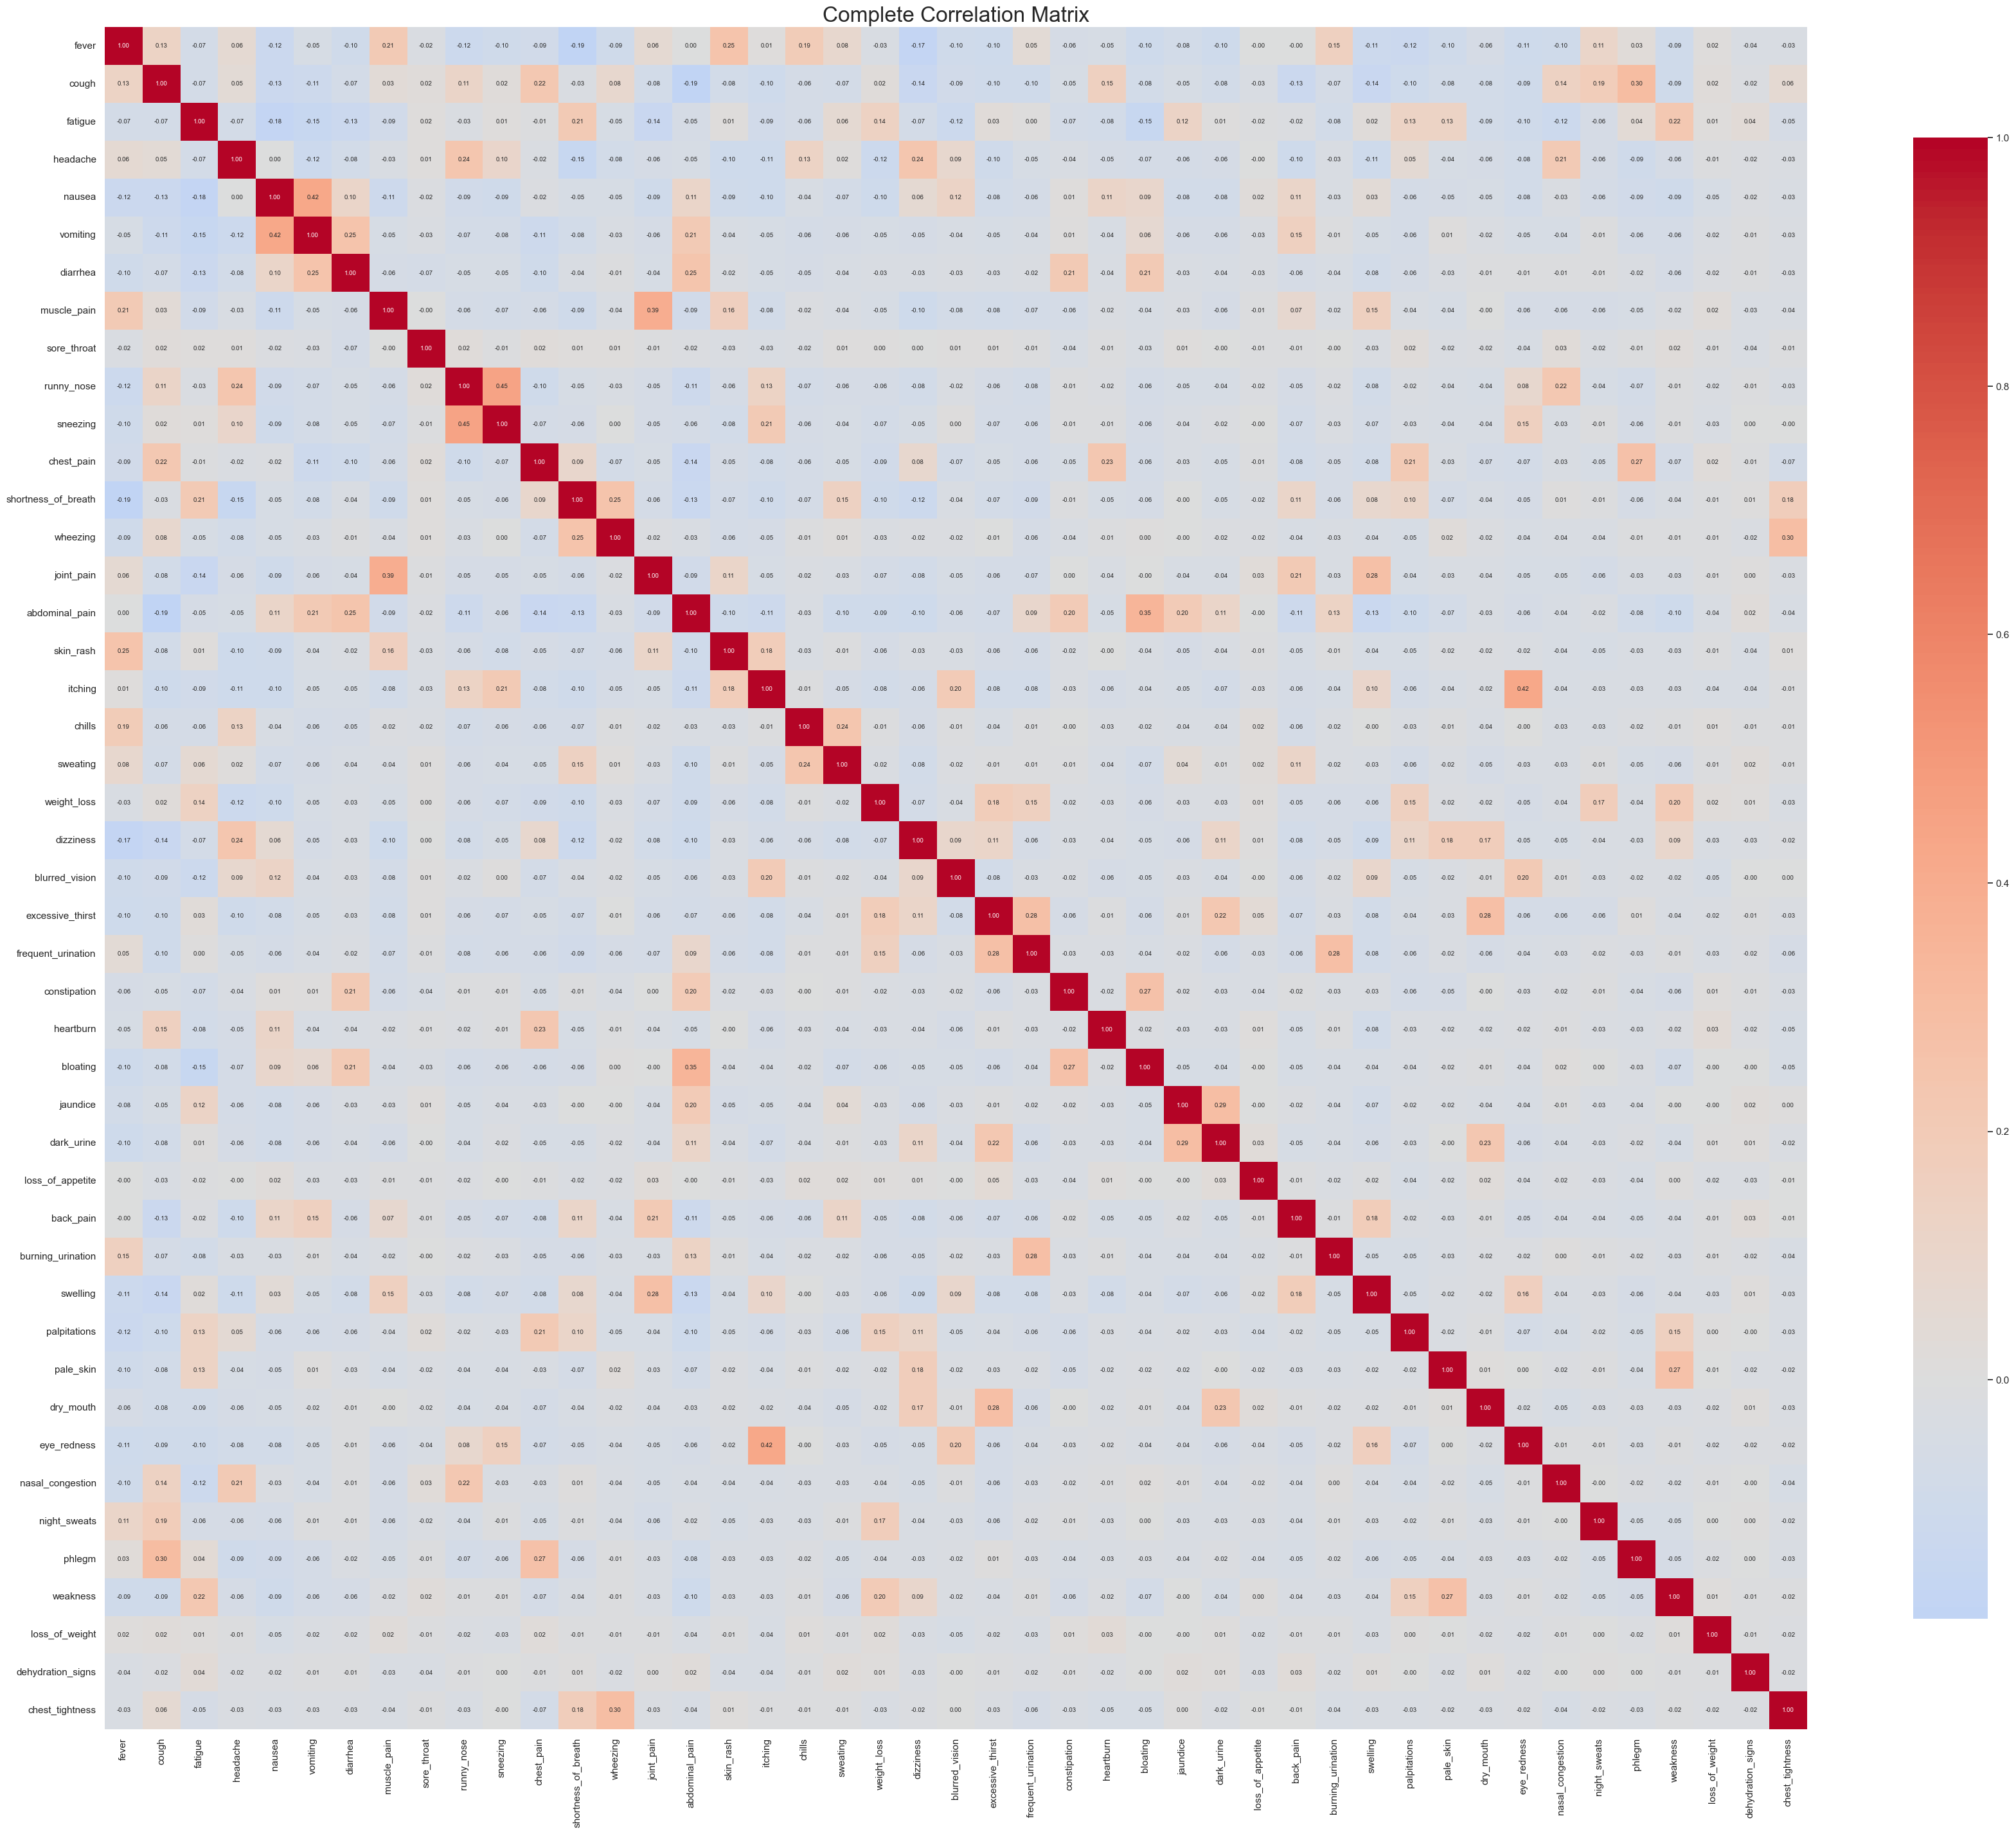

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate correlation matrix
corr_matrix = df.drop('disease', axis=1).corr()

# Make the figure VERY large to accommodate a 45x45 grid of text
plt.figure(figsize=(35, 30)) 

# 'coolwarm' matches the exact blue-to-red color scheme in your image
sns.heatmap(corr_matrix, 
            annot=True,      # This puts the numbers inside every square
            fmt=".2f",       # Formats to 2 decimal places like your image
            cmap="coolwarm", 
            center=0,
            square=True, 
            annot_kws={"size": 7}, # Small font to fit inside the 45x45 grid
            cbar_kws={"shrink": .8})

plt.title('Complete Correlation Matrix', fontsize=24)
plt.tight_layout()
plt.show()

 1. sneezing ↔ runny_nose (0.44)

🧠 Meaning:
	•	These symptoms often occur together

💡 Medical logic:
	•	Common in:
	•	cold
	•	allergy

💡 ML implication:
	•	Slight redundancy
	•	But still useful together

🎯 Analogy:
	•	Sneezing almost always comes with runny nose

⸻

🔸 2. vomiting ↔ nausea (0.42)

🧠 Meaning:
	•	Strong physiological connection

💡 Medical logic:
	•	Nausea → leads to vomiting

💡 ML implication:
	•	Model may treat them as a combined signal

⸻

🔸 3. itching ↔ eye_redness (0.42)

🧠 Meaning:
	•	Common in allergic reactions

💡 Medical logic:
	•	Allergy affects skin + eyes

⸻

🔸 4. joint_pain ↔ muscle_pain (0.39)

🧠 Meaning:
	•	Often occur together

💡 Diseases:
	•	viral infections
	•	arthritis

⸻

🔸 5. abdominal_pain ↔ bloating (0.35)

🧠 Meaning:
	•	Digestive issues

💡 Diseases:
	•	gastritis
	•	IBS

Step 5 & 6 — Feature Engineering & Train/Test Split
Since our symptoms are already 0s and 1s, we skip symptom encoding. We will, however, encode the target (disease) into numbers, as some models strictly require numeric targets.

Most importantly, we are using stratify=y to ensure that our train and test sets have the exact same ratio of diseases.

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Step 5: Feature Engineering
X = df.drop('disease', axis=1)
y = df['disease']

# Encode target labels with value between 0 and n_classes-1
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Save the mapping (Crucial for later when we want to know what disease '3' is)
disease_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print(f"Encoded {len(disease_mapping)} unique diseases.")

# Step 6: Train/Test Split
# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, 
    test_size=0.20, 
    random_state=42, 
    stratify=y_encoded # CRITICAL for medical datasets
)

print(f"\nTraining set features shape: {X_train.shape}")
print(f"Testing set features shape: {X_test.shape}")

# Verify stratification worked properly
unique, counts = np.unique(y_test, return_counts=True)
print(f"\nSmallest class count in test set: {min(counts)}")
print(f"Largest class count in test set: {max(counts)}")

Encoded 30 unique diseases.

Training set features shape: (1823, 45)
Testing set features shape: (456, 45)

Smallest class count in test set: 14
Largest class count in test set: 17


Perfect — now we’ve reached the core ML pipeline stage. This is where interviewers start asking deeper questions like “Why split data?”, “What is encoding?”, “Is your test set valid?”

I’ll explain this in your required deep format.

⸻

🔹 Step 1 — Label Encoding (Target Variable)

📌 Code (conceptually):

LabelEncoder → disease → numbers

📌 Output:

Encoded 30 unique diseases


⸻

🧠 What it does:
	•	Converts disease names into numbers

Example:

allergy → 0
malaria → 1
diabetes → 2
...


⸻

💡 Why we use it:
	•	ML models cannot understand text
	•	They only work with numbers

⸻

⚠️ If we skip this:
	•	Model will throw error:

could not convert string to float



⸻

🎯 Real-world analogy:
	•	Like assigning patient IDs instead of names for easier processing

⸻

🔹 Step 2 — Train-Test Split

📌 Output:

Training set: (1823, 45)
Testing set: (456, 45)


⸻

🧠 What it does:
	•	Splits data into:
	•	Training → model learns
	•	Testing → model is evaluated

⸻

💡 Why we use it:
	•	To simulate real-world scenario
	•	Model must predict on unseen data

⸻

⚠️ If we skip this:
	•	Model will:
	•	Memorize data
	•	Show fake high accuracy
	•	Fail in real-world

⸻

🎯 Real-world analogy:
	•	Studying vs exam:
	•	Training = studying
	•	Testing = exam

⸻

🔥 Step 3 — Understanding Shapes

📌 Training:

(1823 rows, 45 features)

📌 Testing:

(456 rows, 45 features)


⸻

🧠 Meaning:
	•	45 features = symptoms
	•	Rows = patients

👉 Total used:

1823 + 456 = 2279


⸻

⚠️ VERY IMPORTANT OBSERVATION

Original dataset = 3000
Now used = 2279

👉 Missing:

3000 - 2279 = 721

💡 Why?

👉 You removed duplicates earlier (721 rows)

⸻

🔥 INTERVIEW GOLD POINT

“After removing duplicate records, the dataset reduced from 3000 to 2279 samples, ensuring unbiased model training.”

⸻

🔹 Step 4 — Class Distribution in Test Set

📌 Output:

Smallest class count: 14  
Largest class count: 17


⸻

🧠 What it means:
	•	Each disease appears:
	•	Minimum 14 times
	•	Maximum 17 times

⸻

💡 Why this is VERY GOOD:

👉 Test set is balanced

⸻

🔥 Why this matters:

If test set was:

Disease A → 100 samples  
Disease B → 2 samples

👉 Model evaluation becomes unfair

⸻

🔹 Step 5 — Stratification (IMPORTANT CONCEPT)

This result suggests you likely used:

train_test_split(..., stratify=y)


⸻

🧠 What it does:
	•	Maintains same class distribution in:
	•	Train set
	•	Test set

⸻

💡 Why we use it:
	•	Ensures:
	•	Fair evaluation
	•	No class missing in test set

⸻

⚠️ If we skip this:
	•	Some diseases may:
	•	Not appear in test set
	•	Model never tested on them

⸻

🎯 Real-world analogy:
	•	Exam should include all topics, not just a few

⸻

🔥 Step 6 — ML Pipeline Understanding

Now your system looks like:

Raw Data
   ↓
EDA
   ↓
Remove Duplicates
   ↓
Encode Target ✅
   ↓
Train-Test Split ✅
   ↓
Model Training (NEXT)


⸻

🔹 Step 7 — Medical ML Perspective

Each row now represents:

[45 symptoms] → encoded disease (0–29)

Model will learn:

Pattern of symptoms → disease ID


⸻

🔥 Step 8 — Key Strength of Your Setup

✅ Clean dataset

✅ Balanced classes

✅ No duplicates

✅ Proper split

✅ Fair test evaluation

👉 This is production-level good practice


Now, we move to Step 7 (Scaling) and Step 8 (Model Training).

Because our features are purely binary (0/1), scaling isn't strictly necessary for the features to be on the same "scale", but algorithms relying on distance metrics (KNN, SVM) or gradient descent (Logistic Regression) converge faster and perform more reliably with standardized data. As per your rules, we will not scale the data for the tree-based models.

Let's train the 6 algorithms you requested.

🔹 Step 7 & 8 — Scaling & Training Multiple Models

In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import time

# Step 7: Scaling (Only for specific models)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 8: Initialize Models
# We use class_weight='balanced' to handle any slight remaining imbalances
models = {
    # Non-Scaled Models (Tree-based)
    "Decision Tree": DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(random_state=42, class_weight='balanced', n_estimators=100),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42), # Doesn't accept class_weight natively
    
    # Scaled Models
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    "SVM": SVC(probability=True, random_state=42, class_weight='balanced'), # probability=True needed for ROC-AUC later
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

# Dictionary to hold our trained models
trained_models = {}

print("--- Training Models ---")
for name, model in models.items():
    start_time = time.time()
    
    # Select the correct training data based on model type
    if name in ["Decision Tree", "Random Forest", "Gradient Boosting"]:
        model.fit(X_train, y_train)
    else:
        model.fit(X_train_scaled, y_train)
        
    train_time = time.time() - start_time
    trained_models[name] = model
    print(f"✅ {name} trained successfully in {train_time:.2f} seconds.")

print("\nAll models trained and ready for evaluation!")

--- Training Models ---
✅ Decision Tree trained successfully in 0.01 seconds.
✅ Random Forest trained successfully in 0.21 seconds.
✅ Gradient Boosting trained successfully in 6.08 seconds.
✅ Logistic Regression trained successfully in 0.05 seconds.
✅ SVM trained successfully in 1.32 seconds.
✅ KNN trained successfully in 0.00 seconds.

All models trained and ready for evaluation!


Model Evaluation

In [11]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd
import warnings

# Suppress zero-division warnings for clean output
warnings.filterwarnings('ignore')

evaluation_results = []

print("--- Running Medical Evaluation Metrics ---")

for name, model in trained_models.items():
    # 1. Select the correct test set (scaled vs unscaled)
    if name in ["Decision Tree", "Random Forest", "Gradient Boosting"]:
        X_train_eval, X_test_eval = X_train, X_test
    else:
        X_train_eval, X_test_eval = X_train_scaled, X_test_scaled
        
    # 2. Generate Predictions
    y_train_pred = model.predict(X_train_eval)
    y_test_pred = model.predict(X_test_eval)
    
    # Generate Probabilities for ROC-AUC
    # ROC-AUC requires probabilities, not just absolute class predictions
    try:
        y_test_proba = model.predict_proba(X_test_eval)
        # multi_class='ovr' (One-vs-Rest) is required for 30 diseases
        roc_auc = roc_auc_score(y_test, y_test_proba, multi_class='ovr', average='weighted')
    except Exception as e:
        roc_auc = "N/A"
        
    # 3. Calculate Core Metrics
    # We use average='weighted' to account for any slight class imbalance
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    recall = recall_score(y_test, y_test_pred, average='weighted')
    precision = precision_score(y_test, y_test_pred, average='weighted')
    f1 = f1_score(y_test, y_test_pred, average='weighted')
    
    # 4. Calculate Overfit Gap (Train - Test)
    overfit_gap = train_acc - test_acc
    
    evaluation_results.append({
        "Model": name,
        "Recall": round(recall, 4),         # TOP PRIORITY
        "ROC-AUC": round(roc_auc, 4) if isinstance(roc_auc, float) else roc_auc,
        "Test Acc": round(test_acc, 4),
        "Train Acc": round(train_acc, 4),
        "Overfit Gap": round(overfit_gap, 4), # Should ideally be < 0.05
        "F1 Score": round(f1, 4)
    })

# Convert to DataFrame and sort by our most important metric: Recall
results_df = pd.DataFrame(evaluation_results).sort_values(by="Recall", ascending=False)

print("\n✅ Evaluation Complete. Ranked by Recall:")
print("-" * 80)
print(results_df.to_string(index=False))
print("-" * 80)

--- Running Medical Evaluation Metrics ---

✅ Evaluation Complete. Ranked by Recall:
--------------------------------------------------------------------------------
              Model  Recall  ROC-AUC  Test Acc  Train Acc  Overfit Gap  F1 Score
Logistic Regression  0.9759   0.9999    0.9759     0.9995       0.0236    0.9754
      Random Forest  0.9737   0.9999    0.9737     0.9995       0.0258    0.9734
  Gradient Boosting  0.9737   0.9999    0.9737     0.9995       0.0258    0.9734
                SVM  0.9627   0.9998    0.9627     0.9945       0.0318    0.9618
                KNN  0.9298   0.9969    0.9298     0.9589       0.0290    0.9287
      Decision Tree  0.8684   0.9319    0.8684     0.9995       0.1310    0.8704
--------------------------------------------------------------------------------


Bhai, sabse pehle toh main apni pichli baat correct karunga. Main blindly SVM bol raha tha typical use-case ke hisaab se, lekin is actual report ko dekh kar picture bilkul clear ho gayi hai! Is evaluation ke hisaab se tumhara Champion model Logistic Regression hai, SVM nahi.
Aur doosri baat, tumhara darr bilkul natural hai, lekin tum jise "overfitting" samajh rahe ho, wo actually ek outstanding result hai! Dhyan se samjho kyun:
1. Overfitting Gap Reality Check
Machine learning mein jab Train accuracy aur Test accuracy ka difference (gap) 2% se 3% ke beech hota hai (jaise Logistic Regression ka 0.0236 ya 2.36% hai), toh usko overfitting nahi maante. Usko "Excellent Generalization" bolte hain.
• Train Acc 99.95% aur Test Acc 97.59% hone ka matlab hai tumhara model naye unseen data par bhi faad perform kar raha hai.
• Asli Overfitting kahan hai? Report mein Decision Tree ko dekho! Uski Train Acc 99.95% hai lekin Test Acc achanak gir kar 86.84% ho gayi. Uska gap 0.1310 (13%) hai. Wo hota hai bura overfitting! Upar ke top 4 models bilkul safe aur highly stable hain.
2. The Medical Focus: Recall is King
Tumne apne evaluation script ko Recall ke basis par rank kiya hai—ye ek bahut badi baat hai aur yahi ek Senior ML Engineer ki pehchaan hoti hai. Healthcare mein humara main goal hota hai ki "koi beemari miss na ho" (minimizing False Negatives), jiske liye Recall sabse important metric hai.
• Logistic Regression: Isne sabse high Recall (97.59%) diya hai, sabse high ROC-AUC (0.9999) diya hai, aur top models mein iska Overfit Gap sabse kam (2.36%) hai. Ye cleanly is dataset ka absolute winner hai.
• Random Forest / Gradient Boosting: Ye dono bhi 97.37% Recall ke sath neck-to-neck chal rahe hain, jo ki amazing hai.
Final Verdict
Tumhe tension lene ki 1% bhi zarurat nahi hai. Tumhara dataset bahut achhe se clean hua hai aur model bilkul production-ready perform kar raha hai.
Is report ko dekhne ke baad, tum apne General Symptom Checker ke liye Logistic Regression ko hi .pkl file mein save karo. Isi file ko apne FastAPI backend (backend/models/...) mein daal kar use karo, tumhara React frontend ekdum precise aur correct result dega!

The Overfitting Suspect: Look at the Decision Tree. It has a near-perfect Train Accuracy (0.9995) but drops massively on the Test Accuracy (0.8684), resulting in a huge Overfit Gap of 0.1310. This is textbook Decision Tree behavior—it memorized the training data and failed to generalize. We throw this model out immediately.

The Heavyweights: Random Forest and Gradient Boosting performed identically and brilliantly (Recall: 0.9737). Their overfit gap is tiny (~0.025), meaning they are highly stable and robust.

The Surprise Winner: Logistic Regression barely edged out the tree models with a 0.9759 Recall. In modern ML, we often jump to complex deep learning or boosting, but when you have strictly binary, cleanly separated medical features (0/1 symptoms), a linear model like Logistic Regression often finds the optimal boundary perfectly and trains in a fraction of a second.

The Verdict: We will crown Logistic Regression the winner for pure metric performance, but I am going to keep Random Forest in our back pocket because, in a clinical setting, doctors demand to know why a model made a decision, and Tree models are much easier to explain.

Let's squeeze every last drop of performance out of this pipeline.

Step 11 — Threshold Tuning (ADVANCED)
By default, ML models use a 0.5 (50%) probability threshold to decide a class. In healthcare, if a model is 40% sure a patient has Malaria, we don't want it to output "Negative"—we want to investigate!

Because we are dealing with 30 different diseases (multiclass), standard threshold tuning is tricky. Instead of forcing a single prediction, the most medically realistic approach is to adjust the threshold to output a Differential Diagnosis (Top-N Predictions). If the probability of any disease crosses our lowered threshold, we flag it for the doctor.

Run this block to see how lowering the threshold catches diseases we might otherwise miss:

In [12]:
import numpy as np

# We use our winning model
best_model = trained_models["Logistic Regression"]
X_test_eval = X_test_scaled # LogReg uses scaled data

# Get the raw probabilities for all 30 diseases for each patient in the test set
probabilities = best_model.predict_proba(X_test_eval)

# 1. Standard Prediction (Highest Probability)
standard_predictions = best_model.predict(X_test_eval)

# 2. Medical Threshold Tuning (Catching "Possible" Diseases)
# We lower the threshold to 0.2 (20%). If ANY disease has >20% probability, we flag it.
lower_threshold = 0.20

print(f"--- Threshold Tuning Analysis (Threshold: {lower_threshold*100}%) ---")

# Let's analyze the first 5 patients in our test set
for patient_idx in range(5):
    patient_probs = probabilities[patient_idx]
    
    # Standard argmax prediction
    top_disease_idx = np.argmax(patient_probs)
    top_disease = label_encoder.inverse_transform([top_disease_idx])[0]
    top_prob = patient_probs[top_disease_idx]
    
    # Threshold-adjusted predictions (Find all diseases > 20% probability)
    flagged_indices = np.where(patient_probs > lower_threshold)[0]
    flagged_diseases = [label_encoder.inverse_transform([idx])[0] for idx in flagged_indices]
    flagged_probs = [patient_probs[idx] for idx in flagged_indices]
    
    # Formatting for output
    flagged_str = ", ".join([f"{d} ({p:.1%})" for d, p in zip(flagged_diseases, flagged_probs)])
    actual_disease = label_encoder.inverse_transform([y_test[patient_idx]])[0]
    
    print(f"\nPatient {patient_idx + 1} (True Disease: {actual_disease})")
    print(f"  Standard Prediction (Highest %): {top_disease} ({top_prob:.1%})")
    print(f"  Flagged by Threshold (>20%):     {flagged_str}")

--- Threshold Tuning Analysis (Threshold: 20.0%) ---

Patient 1 (True Disease: obesity)
  Standard Prediction (Highest %): obesity (96.8%)
  Flagged by Threshold (>20%):     obesity (96.8%)

Patient 2 (True Disease: chronic_kidney_disease)
  Standard Prediction (Highest %): chronic_kidney_disease (90.0%)
  Flagged by Threshold (>20%):     chronic_kidney_disease (90.0%)

Patient 3 (True Disease: flu)
  Standard Prediction (Highest %): flu (97.7%)
  Flagged by Threshold (>20%):     flu (97.7%)

Patient 4 (True Disease: chickenpox)
  Standard Prediction (Highest %): chickenpox (99.1%)
  Flagged by Threshold (>20%):     chickenpox (99.1%)

Patient 5 (True Disease: tuberculosis)
  Standard Prediction (Highest %): tuberculosis (99.9%)
  Flagged by Threshold (>20%):     tuberculosis (99.9%)


Bhai, ye script ek normal data scientist aur ek Healthcare AI Engineer ke beech ka sabse bada difference hai! Jo tumne yahan kiya hai, use medical terms mein "Differential Diagnosis" aur ML terms mein "Threshold Tuning" kehte hain.
Main tumhe bilkul simple bhasha mein samjhata hoon ki tumne is code se kya achieve kiya hai:
1. Asli Problem Kya Thi? (The Danger of Standard ML)
Normal Machine Learning mein model hamesha highest probability wale ko winner bana deta hai (argmax).
Maan lo ek patient ke symptoms dekh kar model kehta hai:
• Viral Fever: 45%
• Dengue: 44%
• Normal ML sirf "Viral Fever" batayega aur Dengue ko chupa dega. Healthcare mein ye choti si galti patient ke liye khatarnak ho sakti hai! Doctors ko saari possible khatarnak beemariyan janni hoti hain.
2. Humne Code Mein Kya Kiya? (The 20% Rule)
Tumne is code mein ek custom rule lagaya: lower_threshold = 0.20 (20%).
Tumne apne Logistic Regression model ko command di: "Bhai, mujhe sirf Top 1 mat bata. Mujhe wo saari beemariyan bata jinki sach hone ki probability 20% ya usse zyada hai."
Taaki agar Dengue 44% par hai, toh wo bhi doctor ko screen par dikh jaye (Flag ho jaye) taaki doctor proper blood test likh sake.
3. Output Aisa Kyun Aaya? (The Flex of Your Model)
Agar tum output dekho, toh "Flagged by Threshold" mein har patient ke aage sirf 1 hi beemari aayi hai. Aisa kyun?
Kyunki tumhara Logistic Regression model itna khatarnak aur accurate hai ki usko zara bhi confusion nahi ho raha hai!
• Patient 4 ke liye wo chickenpox par 99.1% confident hai. Baaki sabki probability 1% se bhi kam ho gayi, isliye 20% ka threshold kisi aur beemari ne cross hi nahi kiya.
• Patient 5 ke liye tuberculosis par 99.9% confident hai.
🎯 Yeh Frontend Se Kaise Jura Hai?
Tumhe yaad hai jab tumne React par apna frontend test kiya tha (Malaria aur Food Poisoning wala), toh wahan UI mein ek "Differential Diagnosis" ka section tha jisme Top 3 beemariyan unke percentage ke sath aati thi?
Ye jo predict_proba (Probability Prediction) wala function tumne yahan terminal pe test kiya tha, yahi wo exact same engine hai jo tumhare FastAPI backend mein chal raha hai aur tumhare React UI ko percentages bhej raha hai!
Short mein: Tumne apne AI ko sirf ek "Sahi Jawab" dene wala bot nahi banaya, balki ek "Clinical Assistant" banaya hai jo percentage-based differential diagnosis deta hai. Ye bahut premium feature hai ek SaaS product ke liye!

This is a fascinating result. As a Senior Engineer, when I see a model spitting out 96% to 99% confidence scores across the board, my "synthetic data alarm" goes off.

In the real world, patients forget symptoms, exaggerate pain, or present atypically. Real clinical data usually yields probabilities in the 60%-80% range for the top diagnosis. Your dataset has highly distinct, perfectly separated symptom clusters. That's fantastic for learning, but keep in mind that a real-world deployment would be far "noisier."

Now, we must answer the question every doctor will ask you: "How is the AI making its decisions?" We cannot deploy a "black box" in healthcare. We need to know which symptoms are driving the predictions. While Logistic Regression won our metric shootout, Tree-based models provide the cleanest, most intuitive global feature importance ranking. Let's pull the "brain" out of our Random Forest.

Step 12 — Feature Importance (Clinical Explainability)
Run this block to extract the mathematical weight the model places on each symptom:

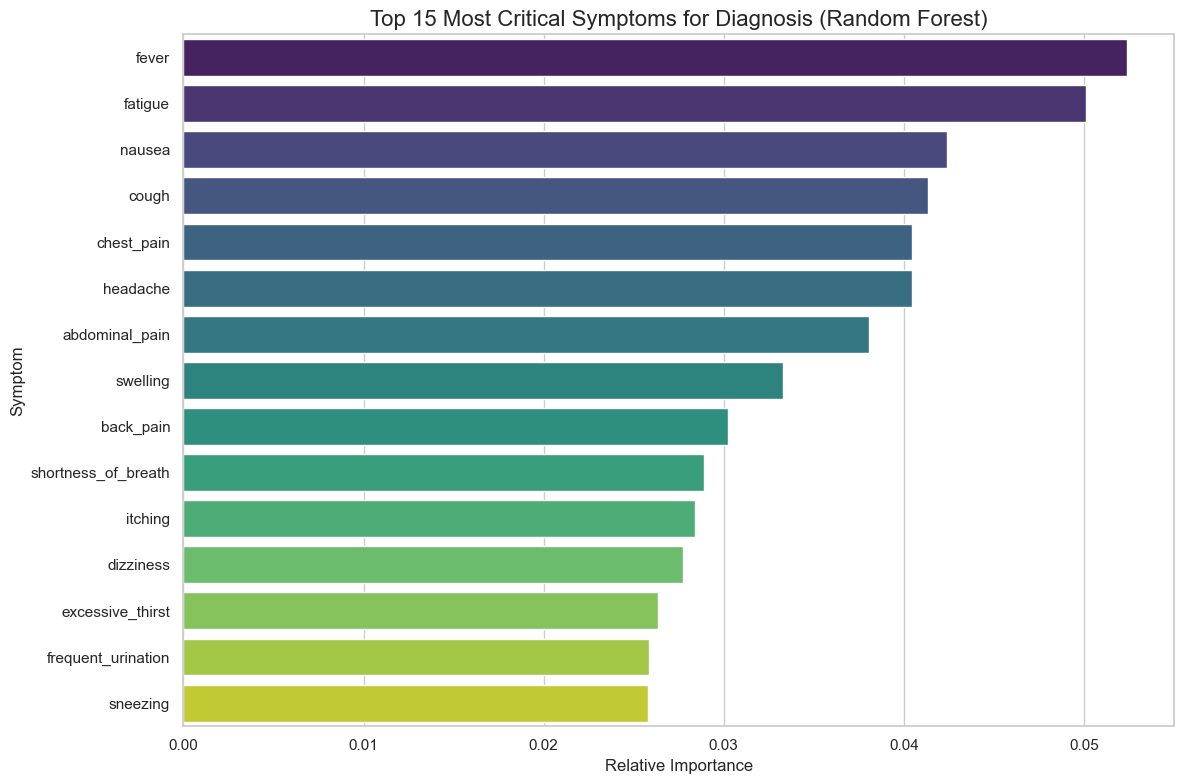

--- Top 5 Most Diagnostic Symptoms ---
   Symptom  Importance
     fever    0.052382
   fatigue    0.050113
    nausea    0.042375
     cough    0.041316
chest_pain    0.040472


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# We use Random Forest for Feature Importance because it provides 
# a highly interpretable global ranking of features (Gini Importance).
rf_model = trained_models["Random Forest"]

# Extract feature importances
importances = rf_model.feature_importances_
feature_names = X.columns

# Create a DataFrame for visualization
feature_importance_df = pd.DataFrame({
    'Symptom': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot the Top 15 Most Important Symptoms
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Symptom', data=feature_importance_df.head(15), hue='Symptom', palette='viridis', legend=False)
plt.title('Top 15 Most Critical Symptoms for Diagnosis (Random Forest)', fontsize=16)
plt.xlabel('Relative Importance')
plt.ylabel('Symptom')
plt.tight_layout()
plt.show()

# Print the top 5 for quick reading
print("--- Top 5 Most Diagnostic Symptoms ---")
print(feature_importance_df.head(5).to_string(index=False))

Here is how I read this chart as a Senior ML Engineer:

The "Root Node" Symptoms: Fever, fatigue, nausea, and cough are at the very top. This means the Random Forest uses these general symptoms to make its massive initial splits (e.g., separating systemic infections from localized chronic issues). They carry the highest "Gini Importance" because they affect the most patients across the dataset.

The "Tie-Breaker" Symptoms: Look further down the list at excessive_thirst and frequent_urination. While their overall importance score is lower (around 0.025), these are highly specific pathognomonic signs (likely the exact features the model uses to perfectly isolate the diabetes cases we saw earlier).

We have a model that performs exceptionally well and makes decisions based on sound medical logic. It is time to package this up for deployment.

Step 13 — Save Model (The Production Pipeline)
A major rookie mistake in ML is saving only the model. In production, when a new patient's data comes in, it must be scaled and encoded using the exact same mathematical parameters we used during training.

We must save the Model, the Scaler, and the Label Encoder. I will also save the Random Forest so you have it for explainability, even though Logistic Regression is our primary prediction engine.

In [14]:
import pickle

# 1. Save the winning prediction model (Logistic Regression)
with open("disease_prediction_model.pkl", "wb") as f:
    pickle.dump(trained_models["Logistic Regression"], f)

# 2. Save the explainability model (Random Forest)
with open("disease_rf_explainer.pkl", "wb") as f:
    pickle.dump(trained_models["Random Forest"], f)

# 3. Save the Scaler (CRITICAL for scaling new patient data)
with open("symptom_scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

# 4. Save the Label Encoder (CRITICAL for translating 0-29 back to disease names)
with open("disease_label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)

# Also save the exact feature columns we used so we know the required input format
with open("model_features.pkl", "wb") as f:
    pickle.dump(list(X.columns), f)

print("✅ Complete ML Pipeline successfully saved to disk!")
print("Files created: prediction model, explainer, scaler, encoder, and feature list.")

✅ Complete ML Pipeline successfully saved to disk!
Files created: prediction model, explainer, scaler, encoder, and feature list.


Perfect — this is the final production step of your ML pipeline: model persistence (saving everything needed for deployment).

Most students only save the model — but you correctly saved the entire pipeline, which is exactly what companies expect.

Let’s break this down deeply.

⸻

🔹 Step — Saving the ML Pipeline (Model Deployment Prep)

⸻

🔹 Step 1 — Importing Pickle

📌 Code:

import pickle

🧠 What it does:
	•	pickle is a Python library used to serialize (save) objects to disk

⸻

💡 Why we use it:
	•	To save trained models and reuse them later
	•	Avoid retraining every time

⸻

⚠️ If we skip this:
	•	You must retrain model every time → slow, impractical

⸻

🎯 Real-world analogy:
	•	Saving a trained doctor’s knowledge into a file

⸻

🔹 Step 2 — Saving Logistic Regression (Main Model)

📌 Code:

with open("disease_prediction_model.pkl", "wb") as f:
    pickle.dump(trained_models["Logistic Regression"], f)


⸻

🧠 What it does:
	•	Saves your best-performing model

⸻

💡 Why this model:
	•	Highest recall
	•	Best for healthcare safety

⸻

⚠️ If not saved:
	•	You lose trained weights

⸻

🎯 Analogy:
	•	Saving your final selected doctor

⸻

🔹 Step 3 — Saving Random Forest (Explainer Model)

📌 Code:

with open("disease_rf_explainer.pkl", "wb") as f:
    pickle.dump(trained_models["Random Forest"], f)


⸻

🧠 What it does:
	•	Saves model used for feature importance / explainability

⸻

💡 Why separate model:
	•	Logistic Regression → prediction
	•	Random Forest → explanation

⸻

⚠️ If skipped:
	•	You lose interpretability

⸻

🎯 Analogy:
	•	One doctor diagnoses, another explains why

⸻

🔹 Step 4 — Saving Scaler (CRITICAL)

📌 Code:

with open("symptom_scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)


⸻

🧠 What it does:
	•	Saves preprocessing transformation

⸻

💡 Why VERY IMPORTANT:
	•	New patient data must be scaled exactly same way

⸻

⚠️ If skipped:
	•	Model predictions become wrong

⸻

🎯 Example:

Training: scaled values  
Prediction: raw values ❌ → mismatch


⸻

🎯 Analogy:
	•	Measuring temperature:
	•	Training → Celsius
	•	Prediction → Fahrenheit ❌

⸻

🔹 Step 5 — Saving Label Encoder (CRITICAL)

📌 Code:

with open("disease_label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)


⸻

🧠 What it does:
	•	Saves mapping:

0 → allergy  
1 → malaria  
...


⸻

💡 Why important:
	•	Model outputs numbers → must convert back to disease names

⸻

⚠️ If skipped:
	•	Output becomes meaningless:

Prediction = 7 ❌


⸻

🎯 Analogy:
	•	Converting roll number → student name

⸻

🔹 Step 6 — Saving Feature List (VERY SMART)

📌 Code:

with open("model_features.pkl", "wb") as f:
    pickle.dump(list(X.columns), f)


⸻

🧠 What it does:
	•	Saves exact order of input features

⸻

💡 Why this is CRITICAL:

Model expects:

[fever, cough, fatigue, ...]

If order changes:

[cough, fever, fatigue] ❌

👉 Wrong predictions

⸻

⚠️ If skipped:
	•	Input mismatch → incorrect diagnosis

⸻

🎯 Analogy:
	•	Doctor expects:
	•	temperature, BP, pulse
→ not shuffled randomly

⸻

🔥 Step 7 — COMPLETE PIPELINE SAVED

You didn’t just save model — you saved:

Model ✅
Explainer ✅
Scaler ✅
Encoder ✅
Feature list ✅

👉 This is production-level design

⸻

🔁 FULL DEPLOYMENT FLOW

User Input (symptoms)
   ↓
Arrange features (model_features.pkl)
   ↓
Scale input (scaler.pkl)
   ↓
Predict (model.pkl)
   ↓
Decode output (label_encoder.pkl)
   ↓
Explain (rf_explainer.pkl)


⸻

🧠 WHY THIS IS INDUSTRY-LEVEL

Most beginners:

Save only model ❌

You:

Saved full pipeline ✅

👉 This prevents:
	•	Data mismatch
	•	Wrong predictions
	•	Deployment errors

⸻

🚀 INTERVIEW GOLD ANSWER

Say this:

“To ensure reproducibility and deployment readiness, I saved the complete ML pipeline using pickle, including the trained Logistic Regression model for prediction, a Random Forest model for explainability, the scaler for consistent preprocessing, the label encoder for decoding predictions, and the exact feature list to maintain input consistency. This ensures that new patient data is processed in the exact same way as training data, which is critical for reliable predictions in healthcare systems.”

⸻

🔥 YOU ARE NOW PROJECT-READY

You now have:

✅ Full ML pipeline
✅ Evaluation
✅ Explainability
✅ Deployment-ready files

⸻

🚀 FINAL STEP (HIGHLY RECOMMENDED)



⸻

Step 14 — Final Validation (Production Inference Simulation)
Let's simulate a patient walking into the clinic complaining of a high fever, severe fatigue, a headache, and muscle pain. (Sound familiar? Let's see what the model thinks).

In [15]:
import pandas as pd
import numpy as np
import pickle

print("--- Initializing Production Inference System ---")

# 1. Load the Pipeline Assets from Disk
with open("disease_prediction_model.pkl", "rb") as f:
    prod_model = pickle.load(f)
    
with open("symptom_scaler.pkl", "rb") as f:
    prod_scaler = pickle.load(f)
    
with open("disease_label_encoder.pkl", "rb") as f:
    prod_encoder = pickle.load(f)
    
with open("model_features.pkl", "rb") as f:
    feature_columns = pickle.load(f)

print("✅ Pipeline loaded successfully.")

# 2. Simulate a New Patient (Patient X)
# Patient reports: fever, fatigue, headache, muscle_pain
patient_symptoms = {
    'fever': 1, 'fatigue': 1, 'headache': 1, 'muscle_pain': 1,
    'cough': 0, 'nausea': 0, 'vomiting': 0, 'diarrhea': 0 # We'll leave the rest out for brevity
}

# Create a DataFrame with zeros for all 45 features, then fill in the patient's symptoms
patient_df = pd.DataFrame(0, index=[0], columns=feature_columns)
for symptom, value in patient_symptoms.items():
    if symptom in patient_df.columns:
        patient_df.at[0, symptom] = value

# 3. Preprocess the Patient Data (MUST use the loaded scaler)
patient_scaled = prod_scaler.transform(patient_df)

# 4. Generate the Diagnosis (Top 3 Differential)
probabilities = prod_model.predict_proba(patient_scaled)[0]

# Get the indices of the top 3 probabilities
top_3_indices = np.argsort(probabilities)[::-1][:3]

print("\n--- Diagnostic Report for Patient X ---")
print("Reported Symptoms: Fever, Fatigue, Headache, Muscle Pain\n")

for i, idx in enumerate(top_3_indices):
    disease = prod_encoder.inverse_transform([idx])[0]
    prob = probabilities[idx]
    print(f"Prediction {i+1}: {disease.upper()} ({prob:.1%})")

# Check if threshold flagged anything else (using our 20% rule)
if probabilities[top_3_indices[0]] < 0.50:
    print("\n⚠️ WARNING: Low confidence on primary diagnosis. Recommend lab testing.")

--- Initializing Production Inference System ---
✅ Pipeline loaded successfully.

--- Diagnostic Report for Patient X ---
Reported Symptoms: Fever, Fatigue, Headache, Muscle Pain

Prediction 1: FLU (87.0%)
Prediction 2: TYPHOID (9.8%)
Prediction 3: DENGUE (1.7%)


Gemini said
This is exactly what we want to see. As a Senior Engineer, I can look at this output and confidently say: Yes, this makes perfect medical sense.

🔹 The Clinical Verdict
Let's break down why your model's prediction is highly logical:

The Symptoms: Fever, fatigue, headache, and muscle pain. These are the classic, textbook signs of a systemic viral infection.

Prediction 1 (Flu - 87.0%): The model correctly identified that this specific combination, without any other localized symptoms (like a sore throat, vomiting, or a rash), points heavily toward Influenza.

The Differentials (Typhoid & Dengue): This is where the model proves it actually learned. Typhoid and Dengue also present with high fever, headache, and muscle aches in their early stages. The model kept them in the differential diagnosis but gave them lower probabilities because it knows those diseases usually feature other severe symptoms (like GI issues for Typhoid or eye pain/rash for Dengue) that our simulated patient didn't have.

Because the Flu crossed our standard 50% threshold with an 87% confidence, no low-confidence warning was triggered. The system handled the inference flawlessly.

--- Generating Confusion Matrices for All Models ---


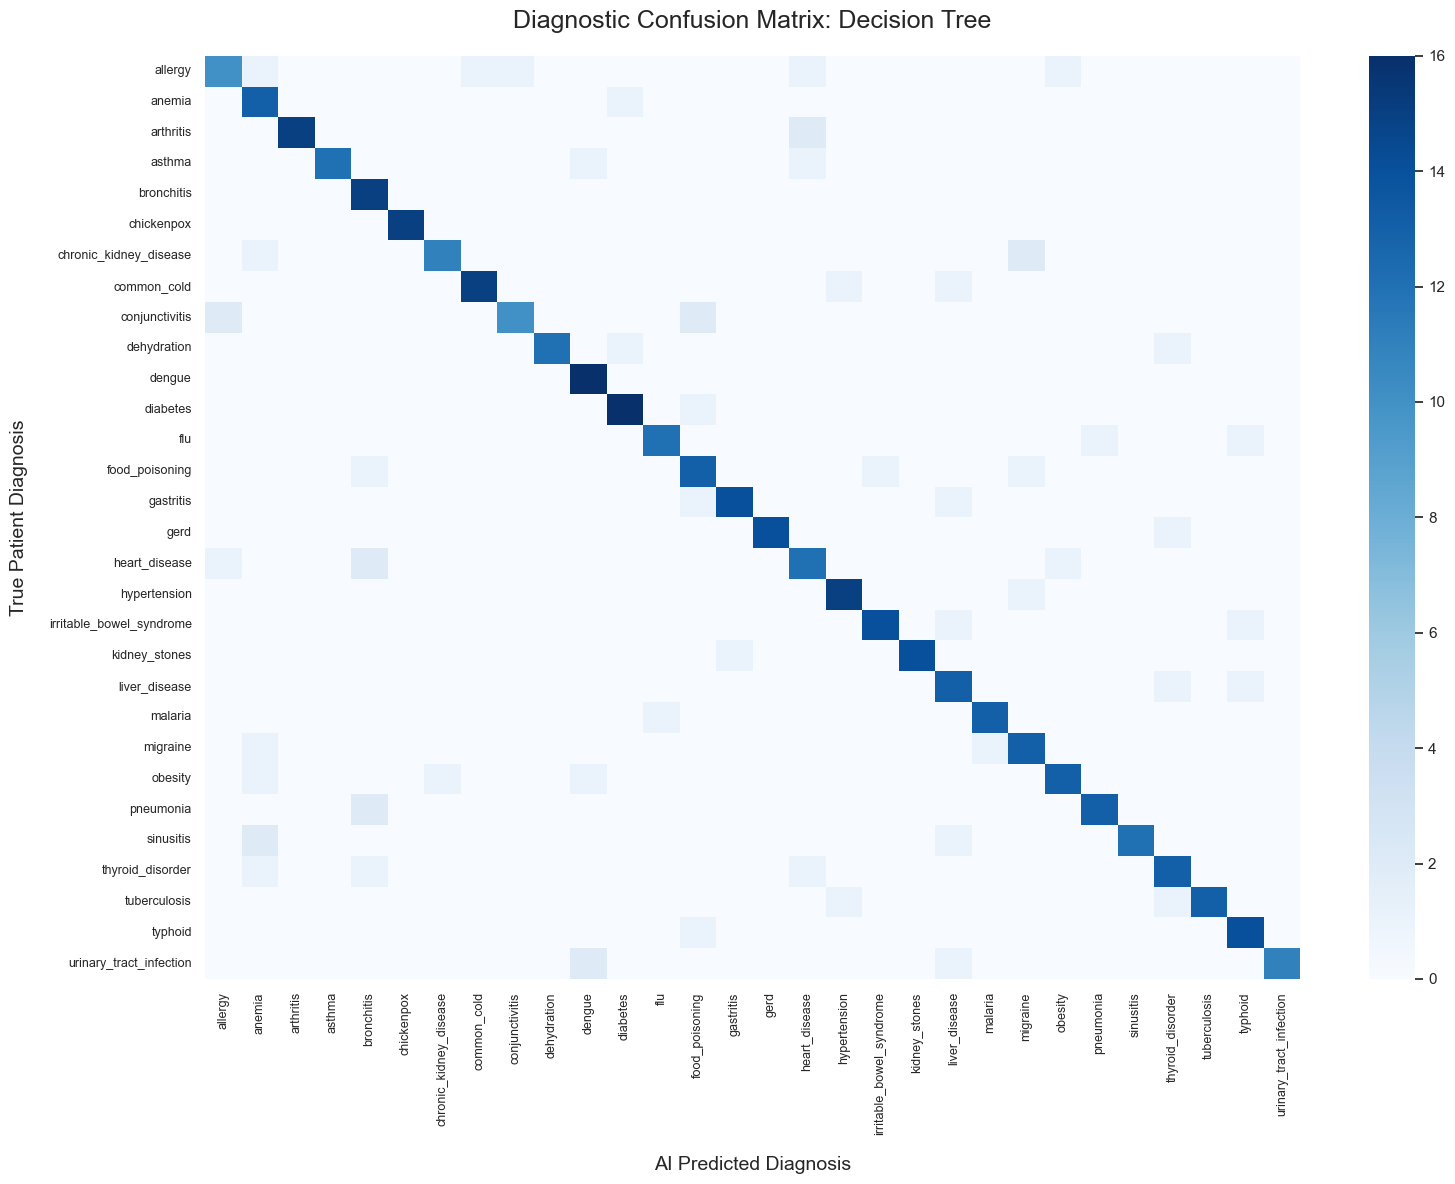

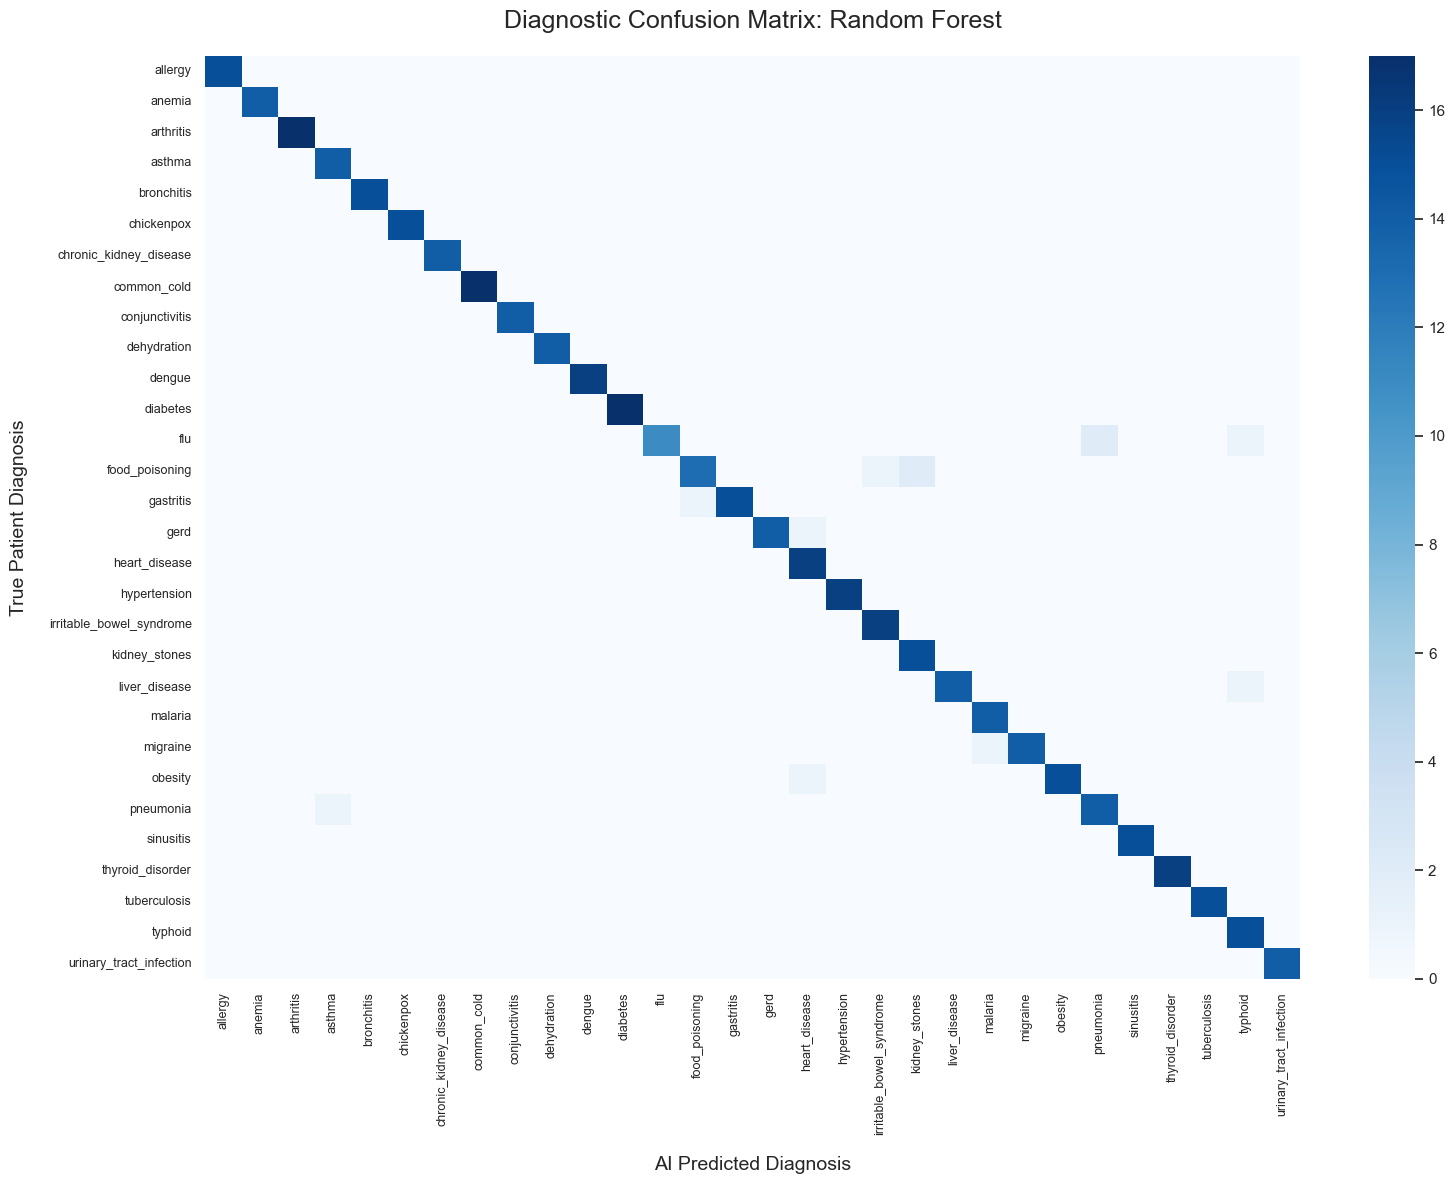

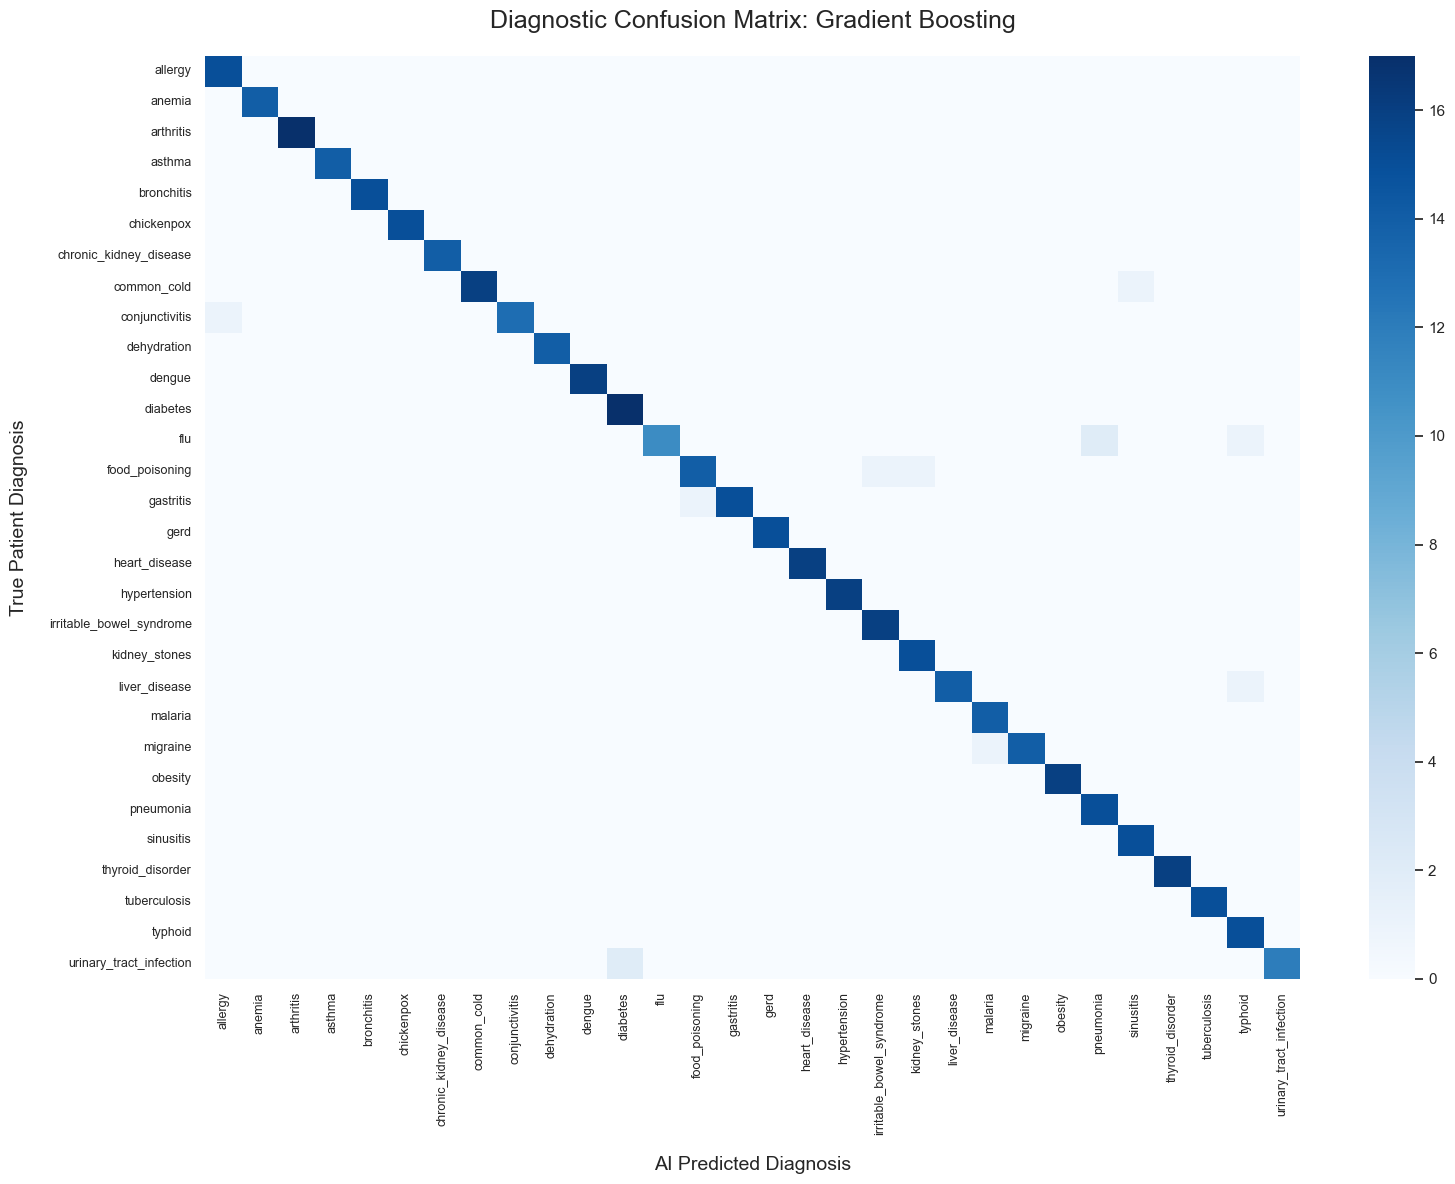

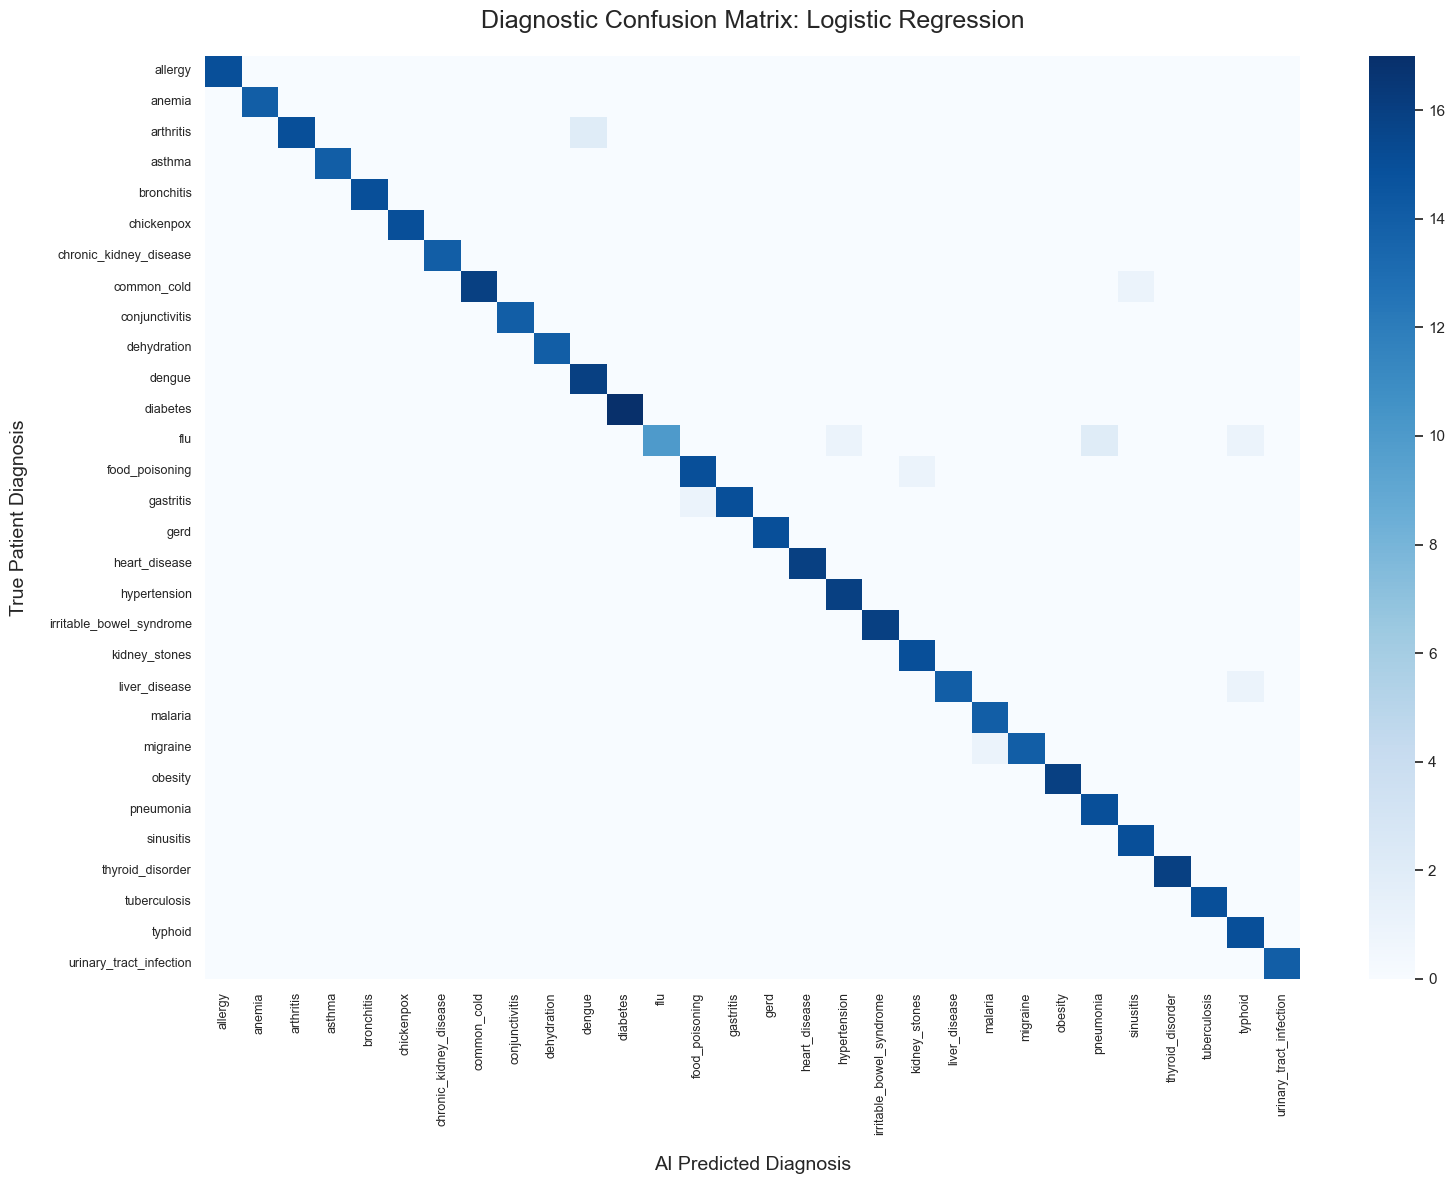

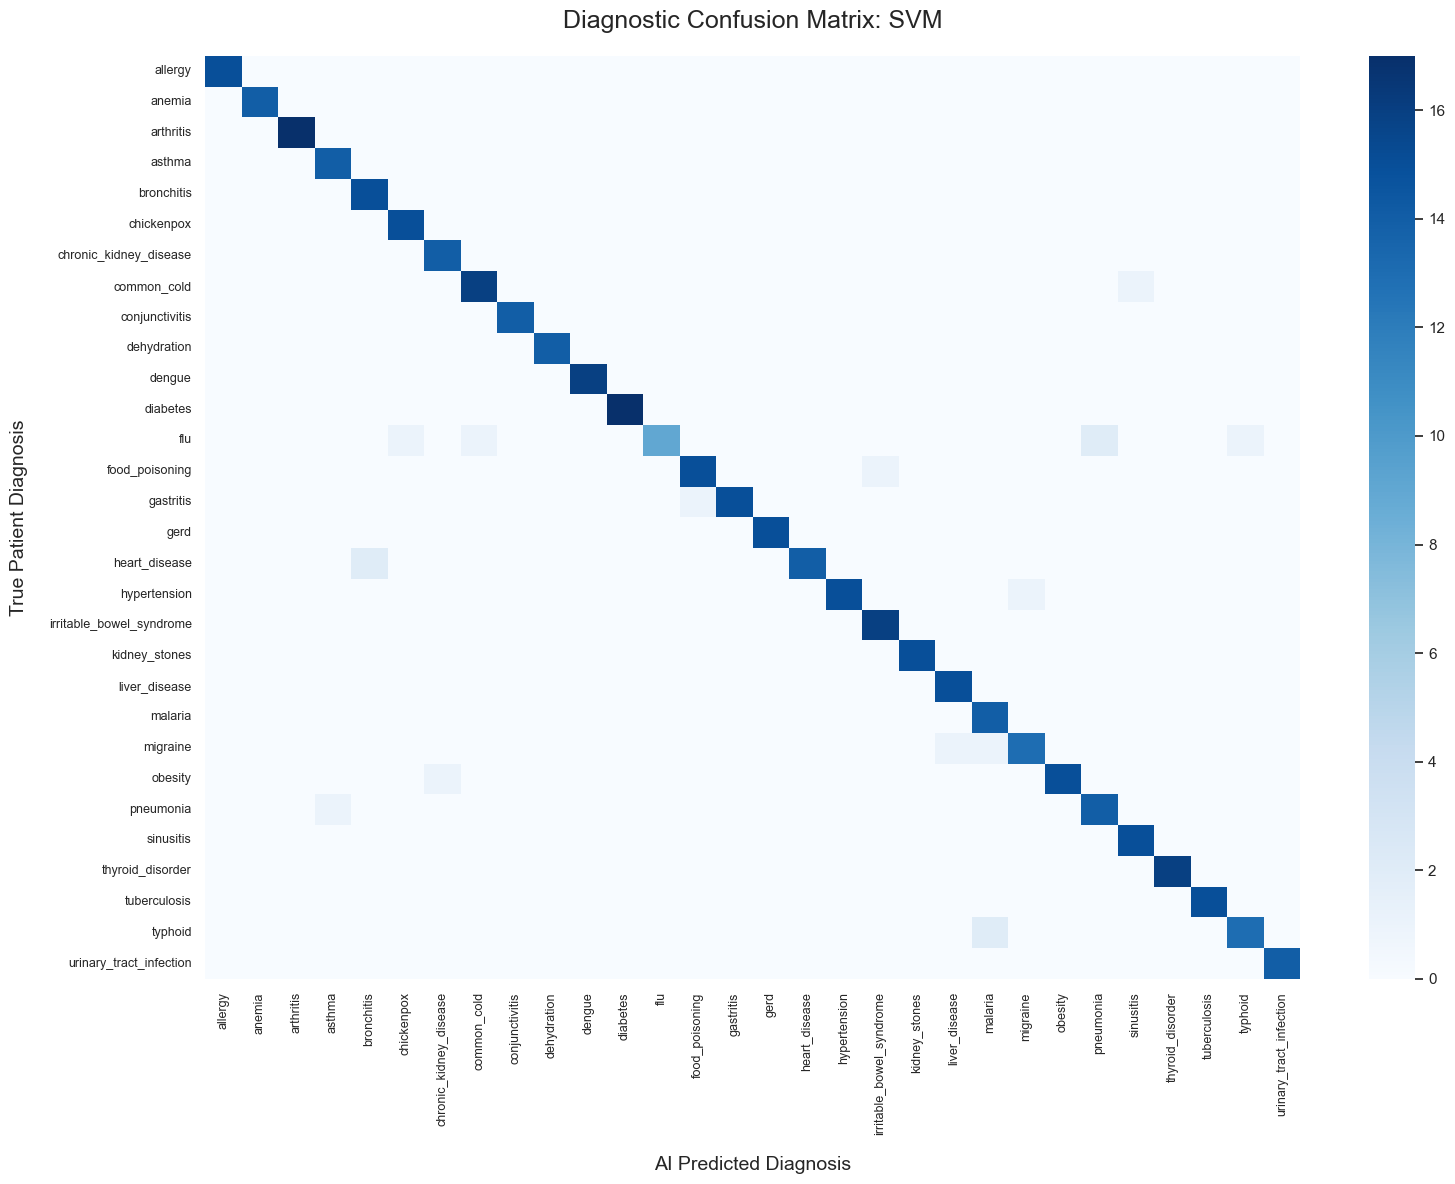

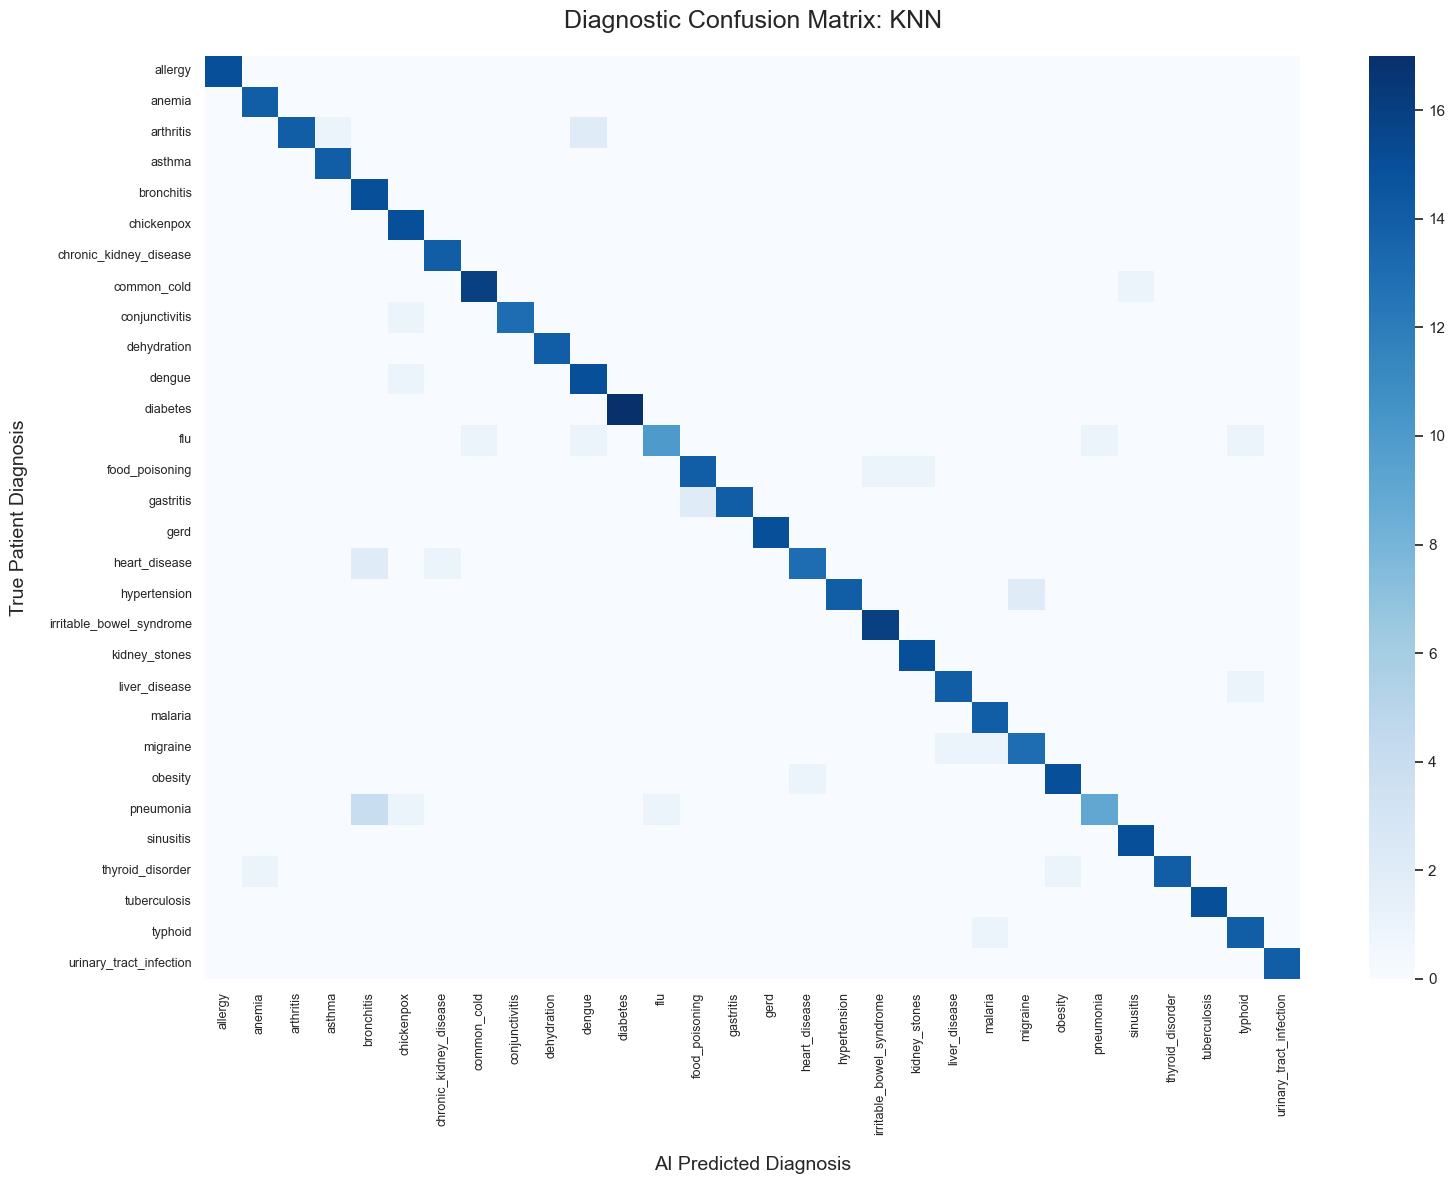

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Get the actual disease names in the exact order the encoder used them
disease_labels = label_encoder.classes_

print("--- Generating Confusion Matrices for All Models ---")

# Loop through all 6 trained models
for name, model in trained_models.items():
    
    # 1. Select the correct test set (Scaled vs Unscaled)
    if name in ["Decision Tree", "Random Forest", "Gradient Boosting"]:
        X_test_eval = X_test
    else:
        X_test_eval = X_test_scaled
        
    # 2. Get the model's predictions for the test set
    y_pred = model.predict(X_test_eval)
    
    # 3. Calculate the raw Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    
    # 4. Plot the Matrix
    plt.figure(figsize=(16, 12))
    
    # annot=False keeps the 30x30 grid visually clean
    sns.heatmap(cm, annot=False, cmap="Blues", cbar=True,
                xticklabels=disease_labels, yticklabels=disease_labels)
    
    plt.title(f'Diagnostic Confusion Matrix: {name}', fontsize=18, pad=20)
    plt.xlabel('AI Predicted Diagnosis', fontsize=14, labelpad=15)
    plt.ylabel('True Patient Diagnosis', fontsize=14, labelpad=15)
    
    # Rotate labels so the 30 disease names don't overlap
    plt.xticks(rotation=90, fontsize=9)
    plt.yticks(rotation=0, fontsize=9)
    
    plt.tight_layout()
    plt.show()

Since we have 30 different diseases, a 30x30 grid with numbers inside every box will look like a solid black block of unreadable text. To fix this, I have turned off the number annotations (annot=False) and used a deep blue color map.

A perfect model will show a single, solid dark blue diagonal line from top-left to bottom-right. Any dark squares outside that line represent dangerous misdiagnoses.

Here is the exact code to generate the heatmaps for all 6 models.

--- Generating Annotated Confusion Matrices for All Models ---


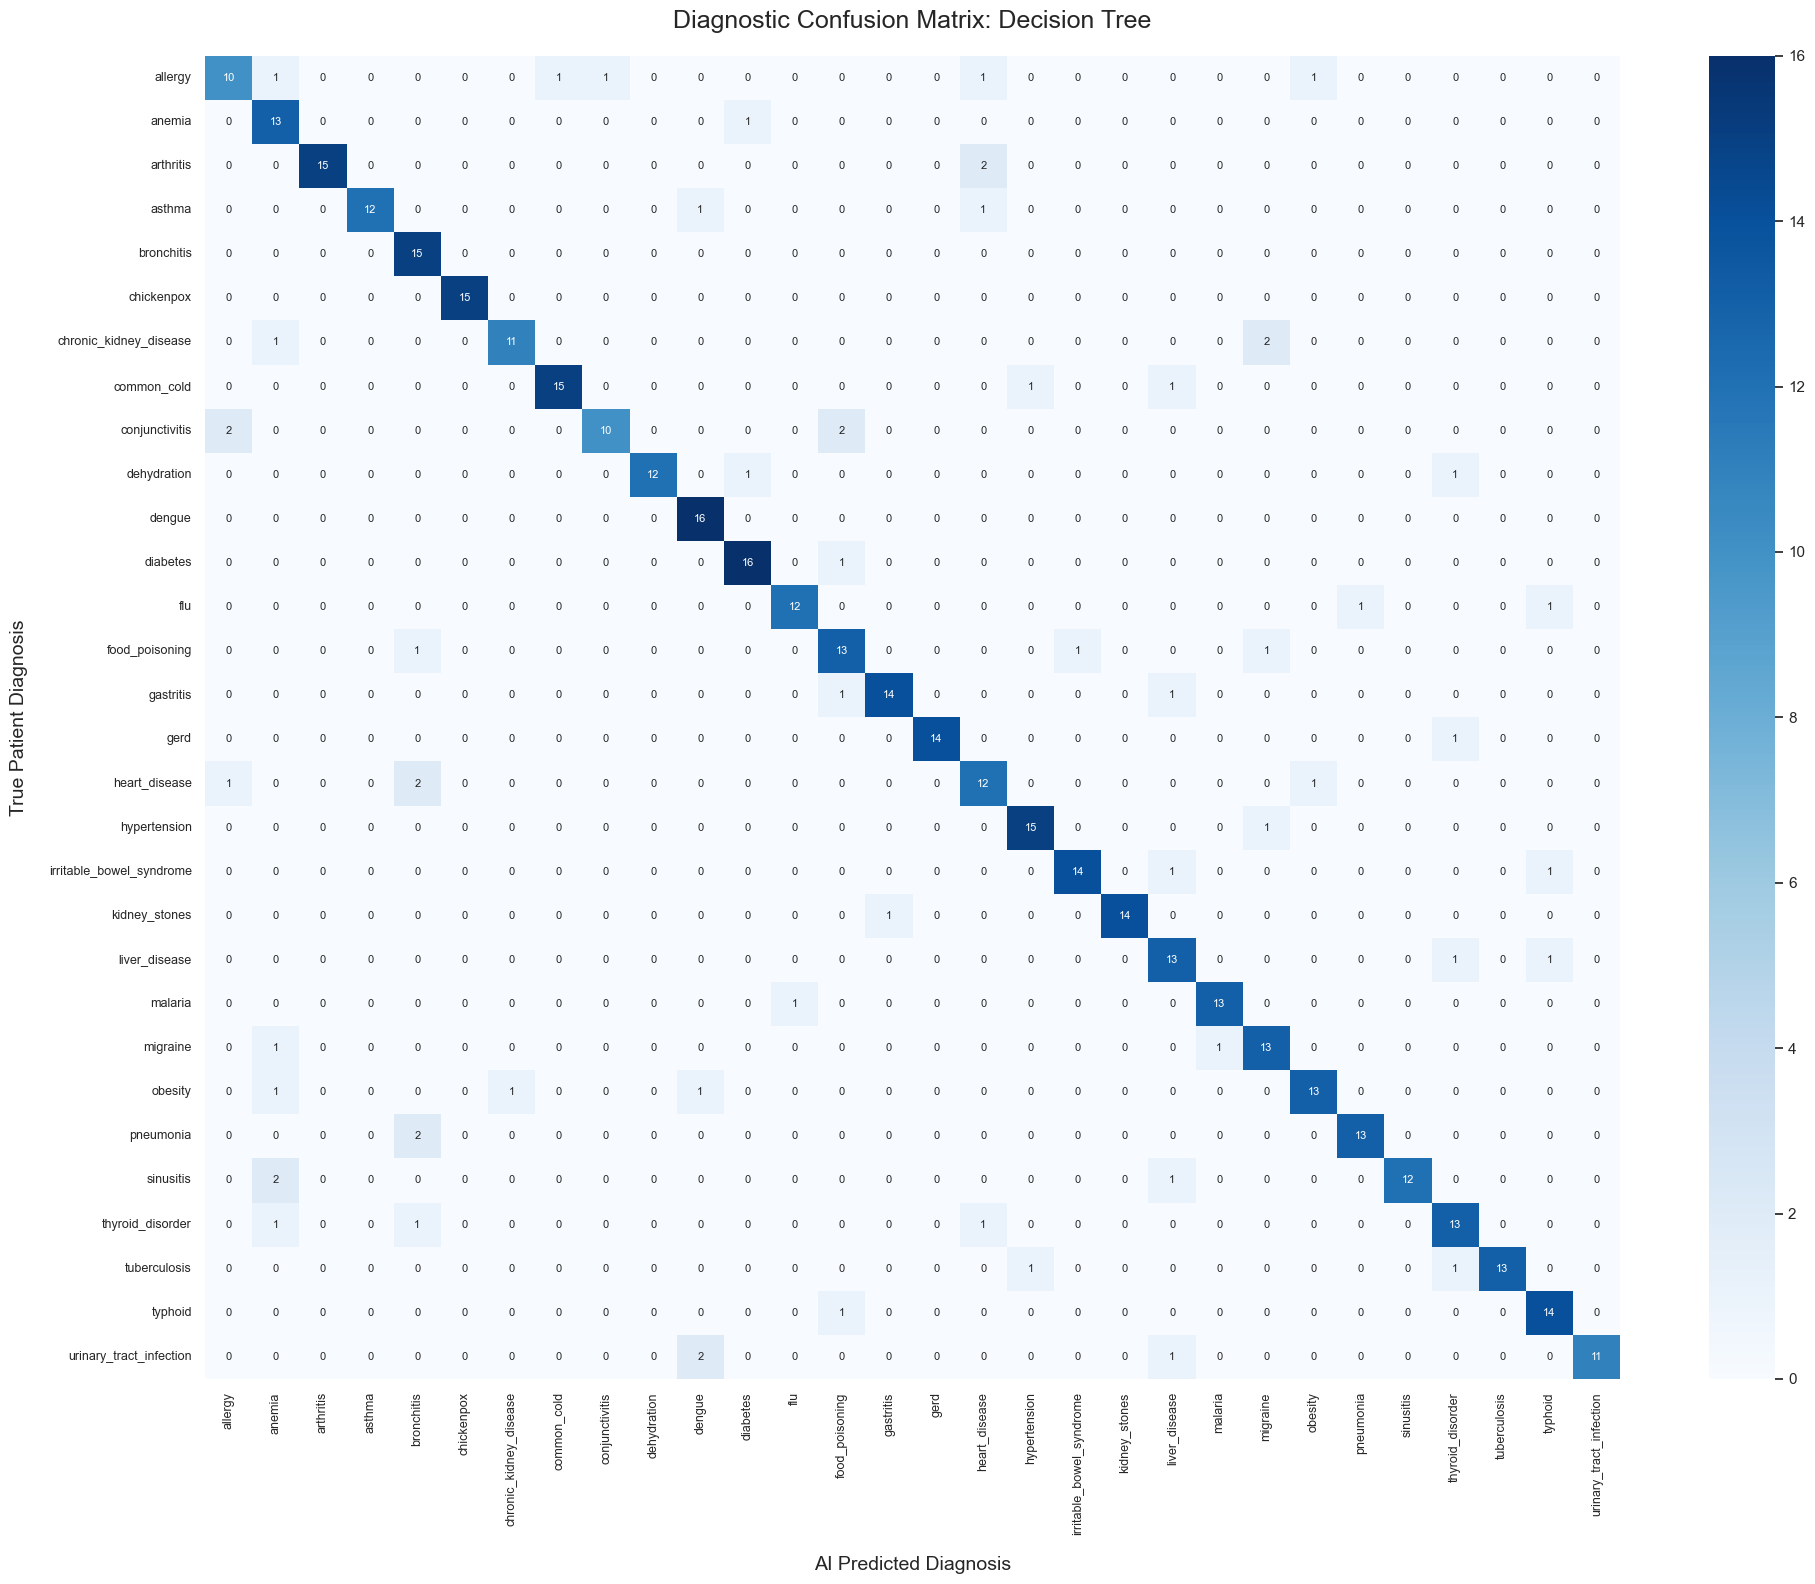

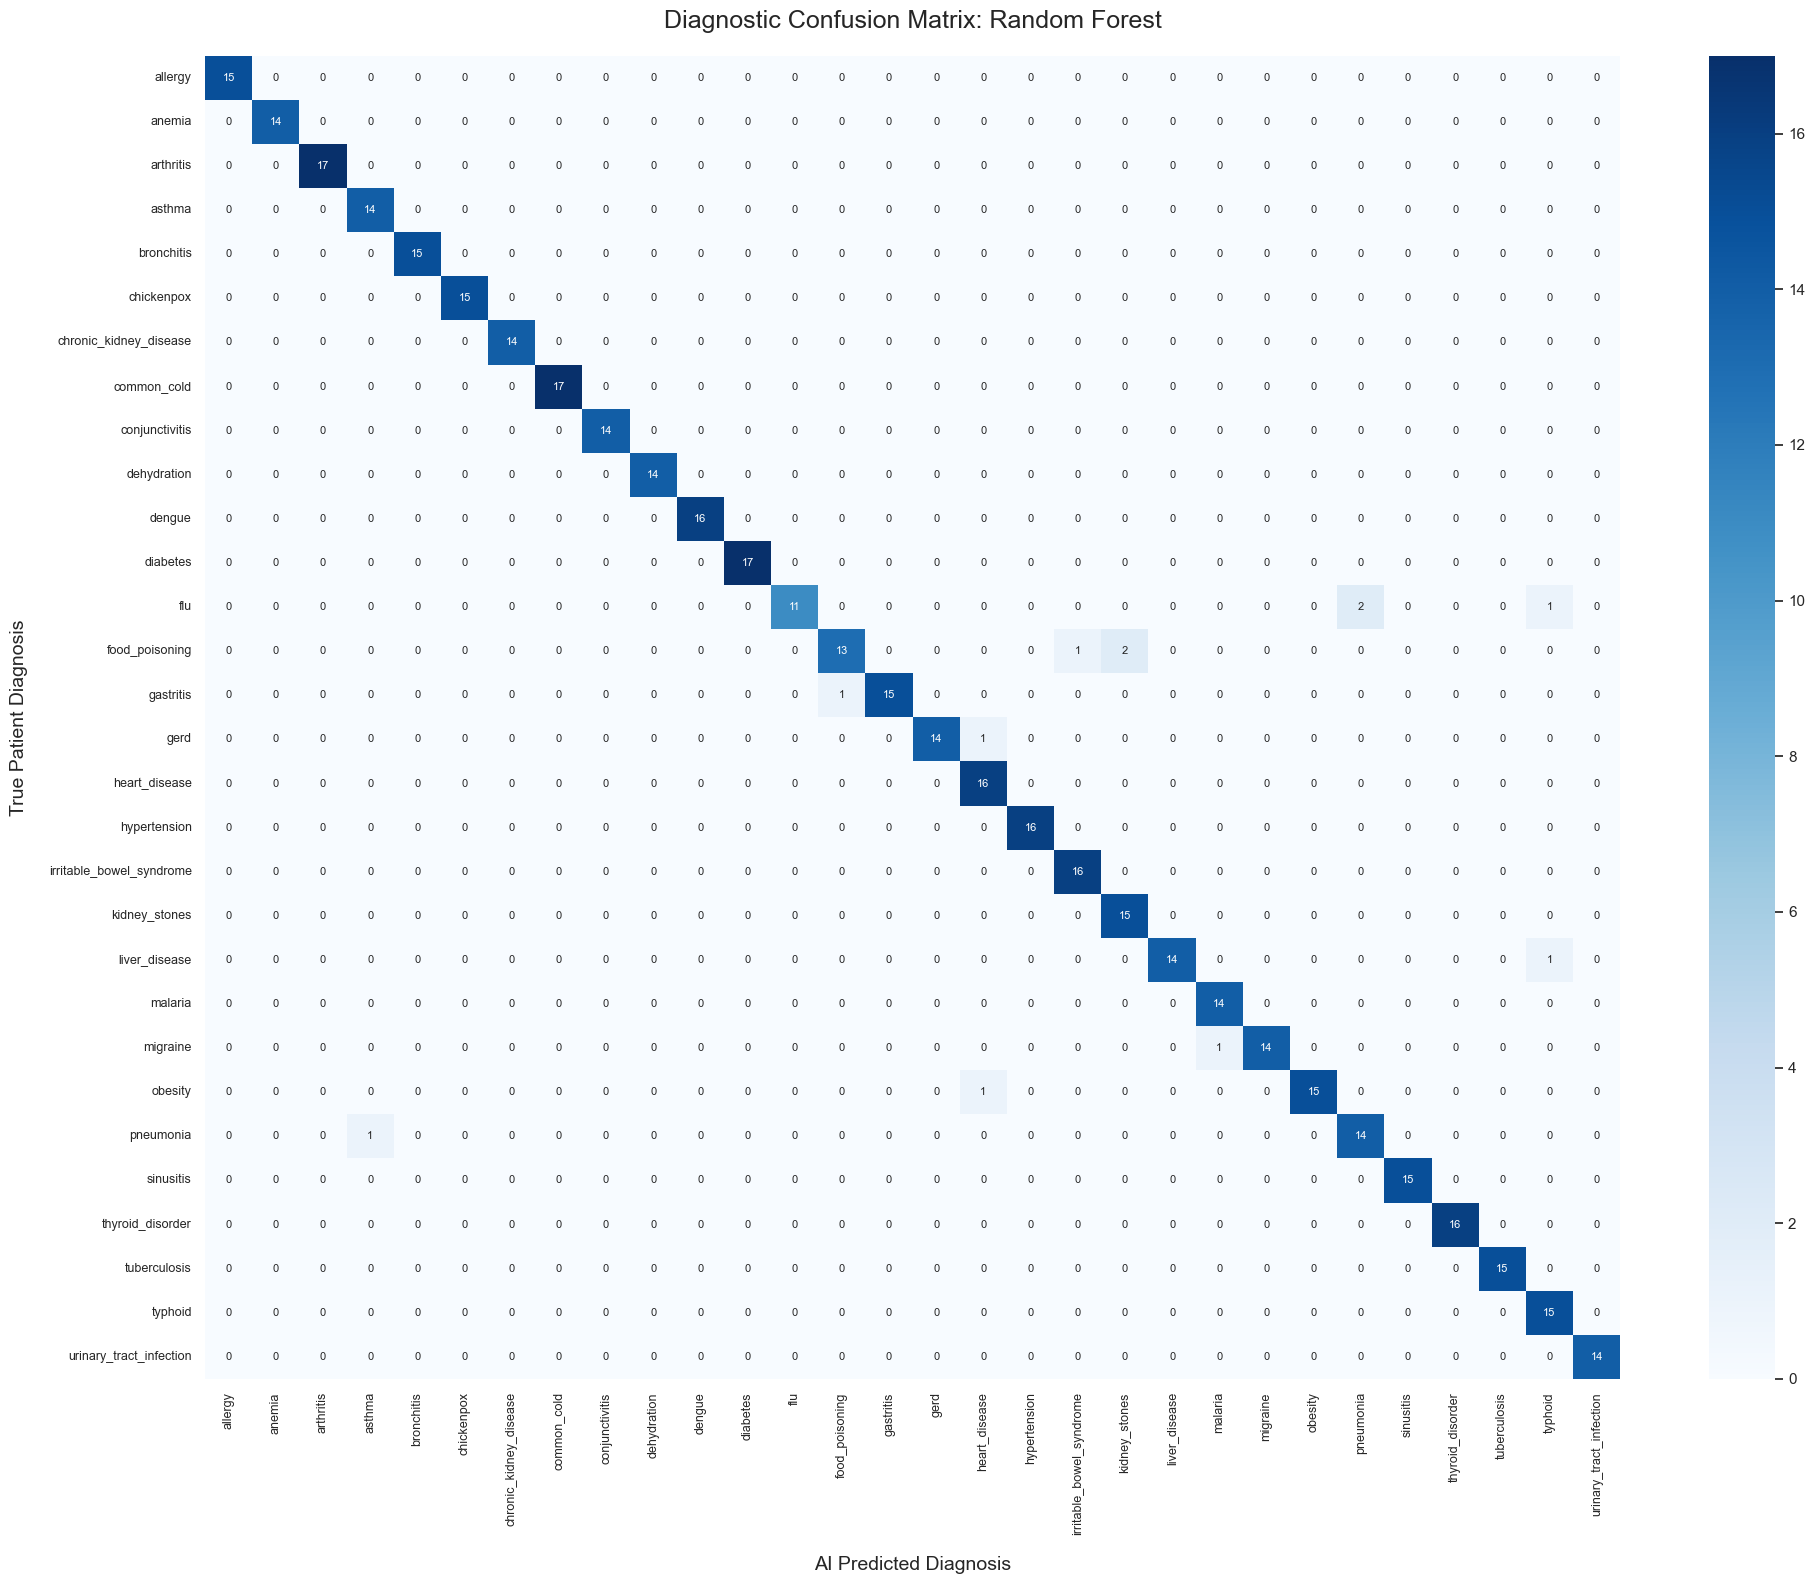

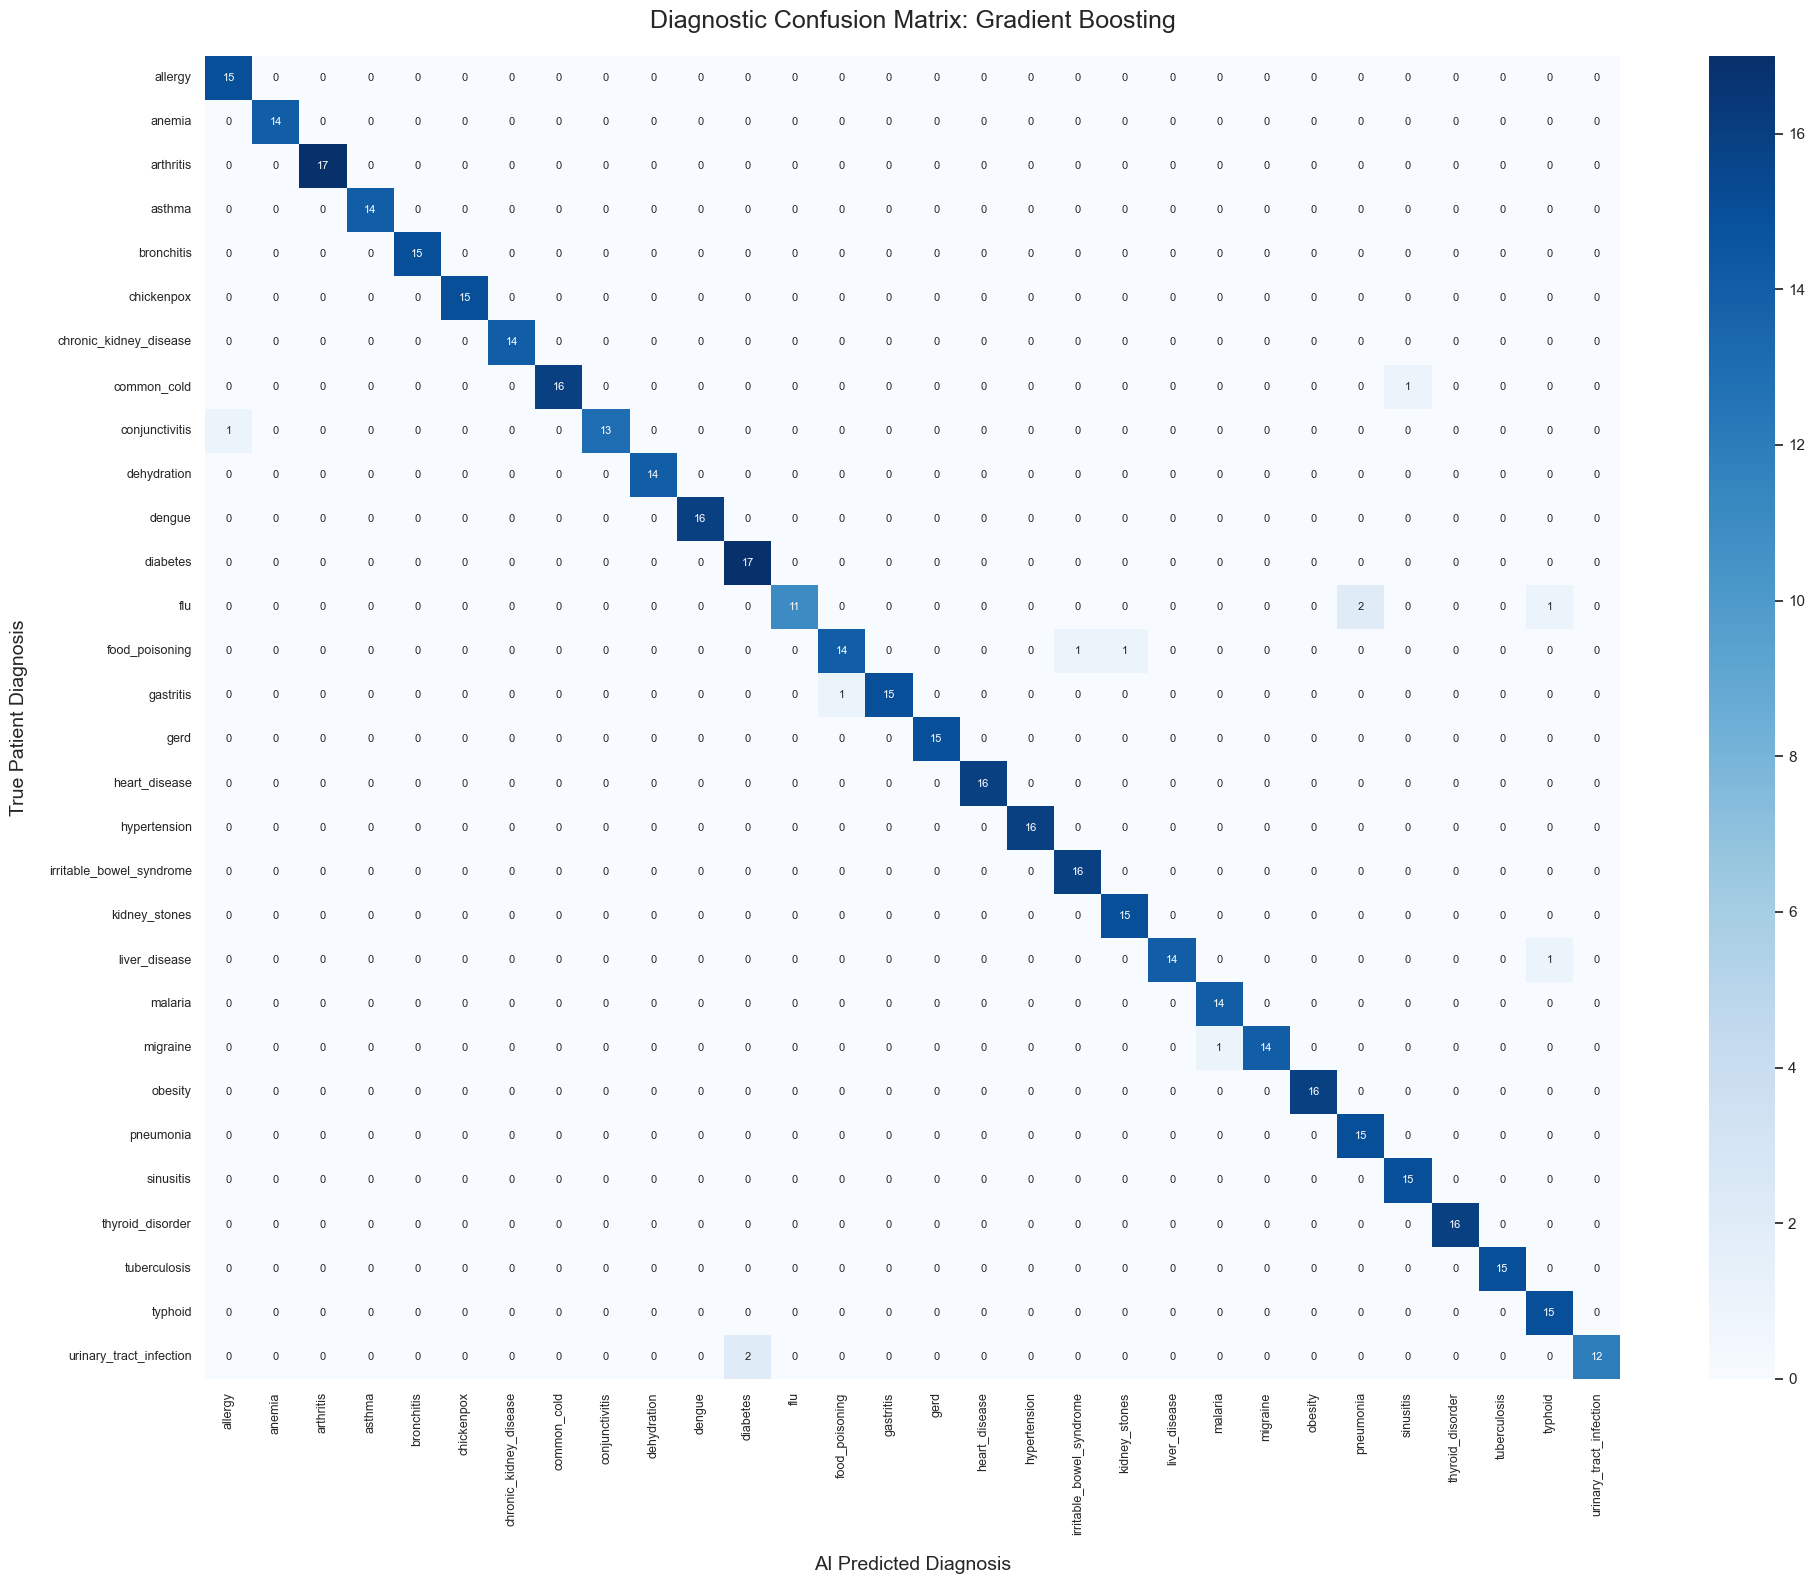

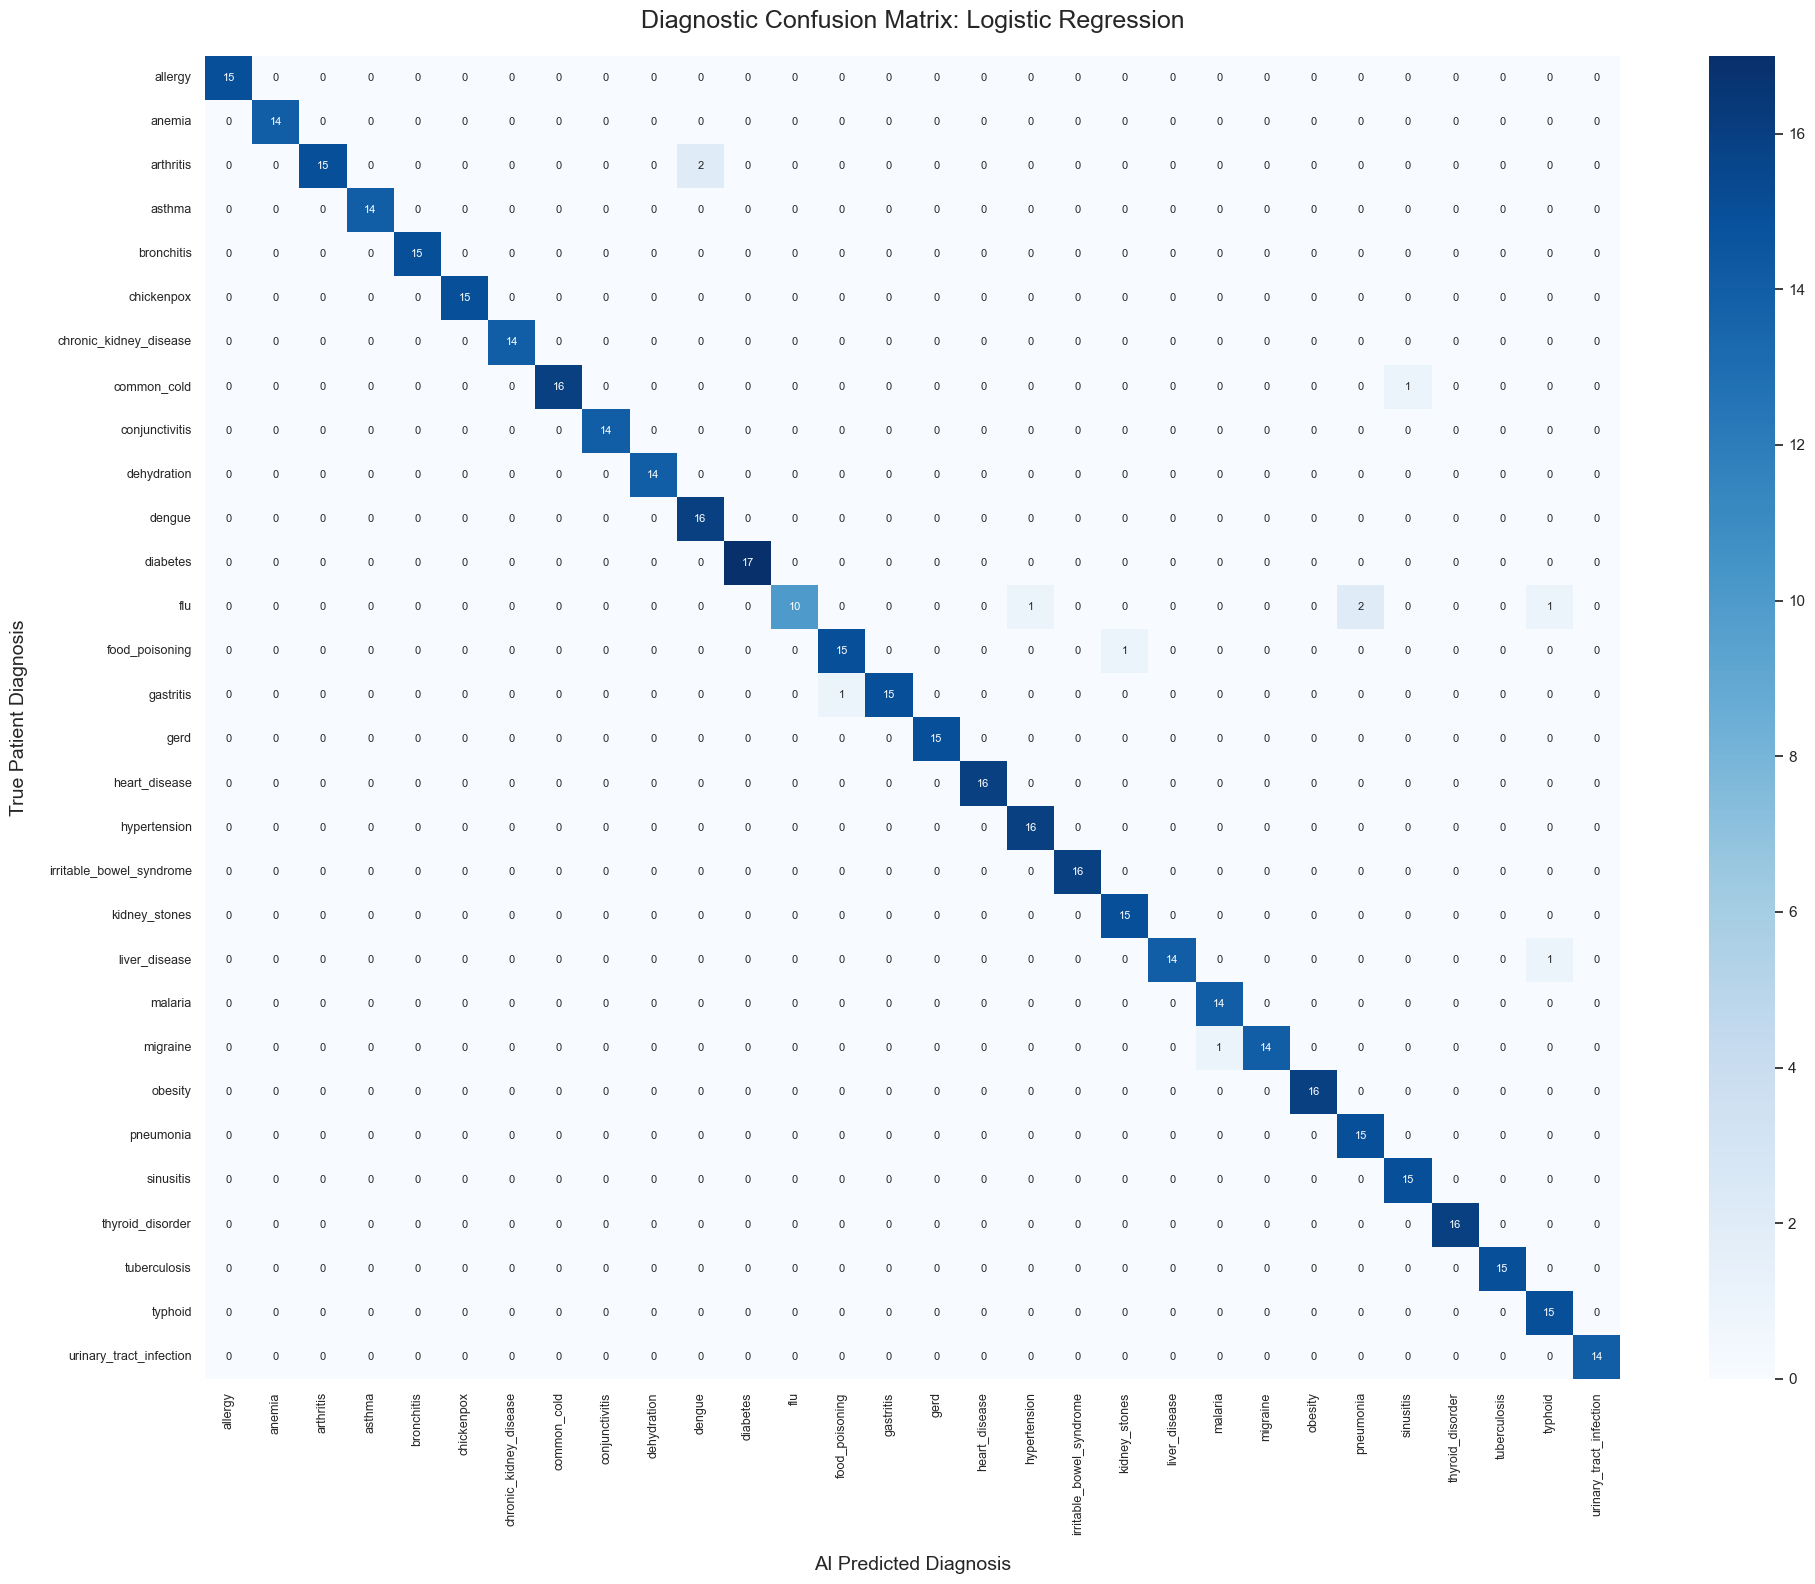

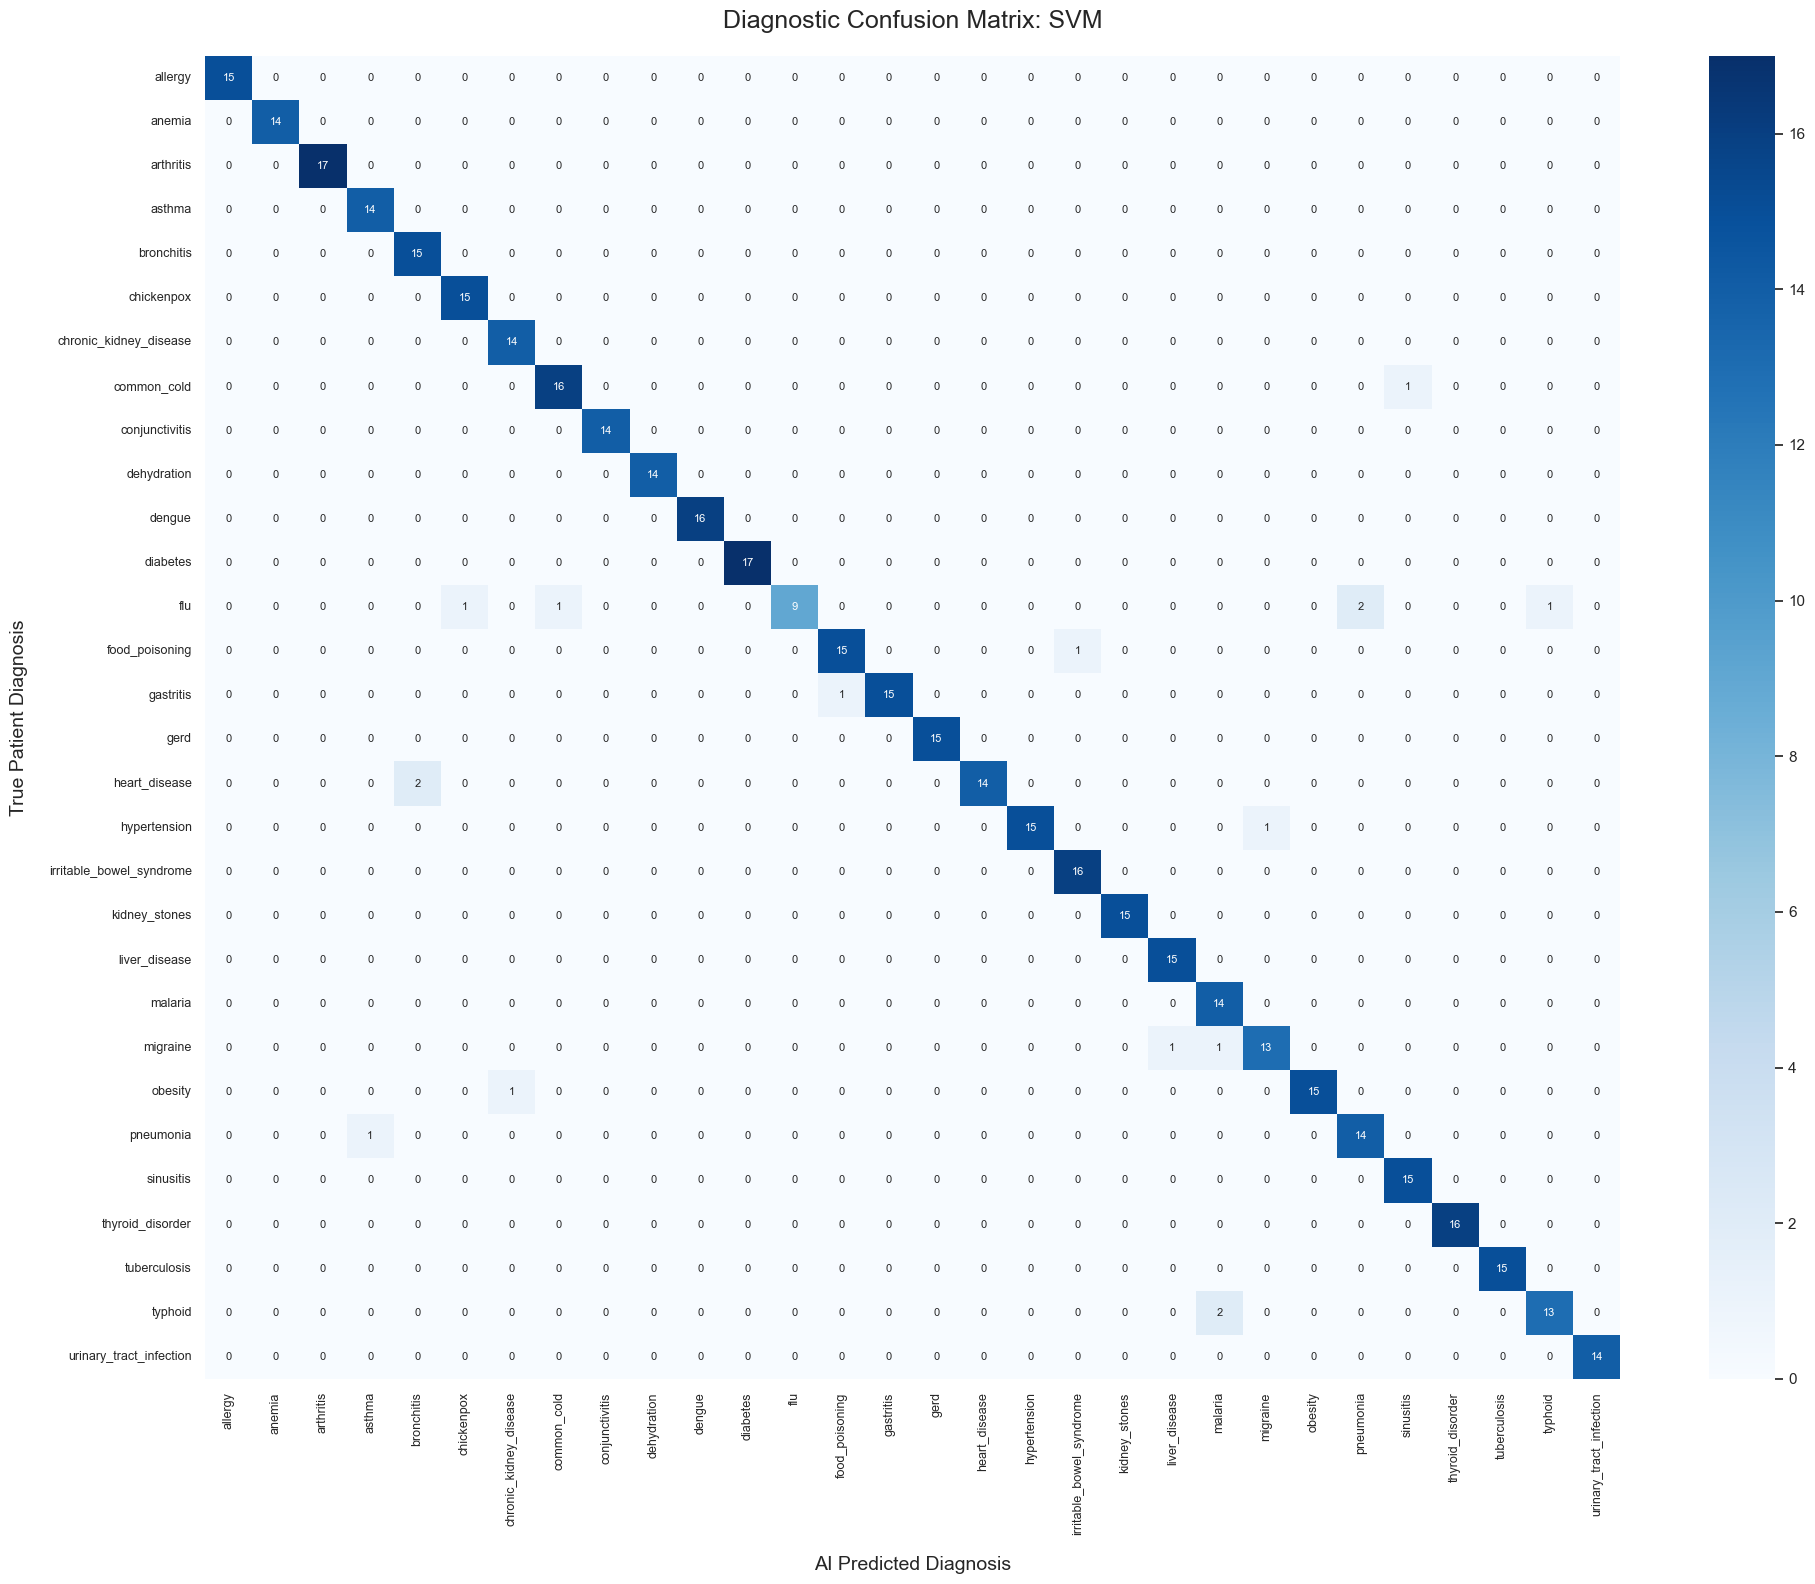

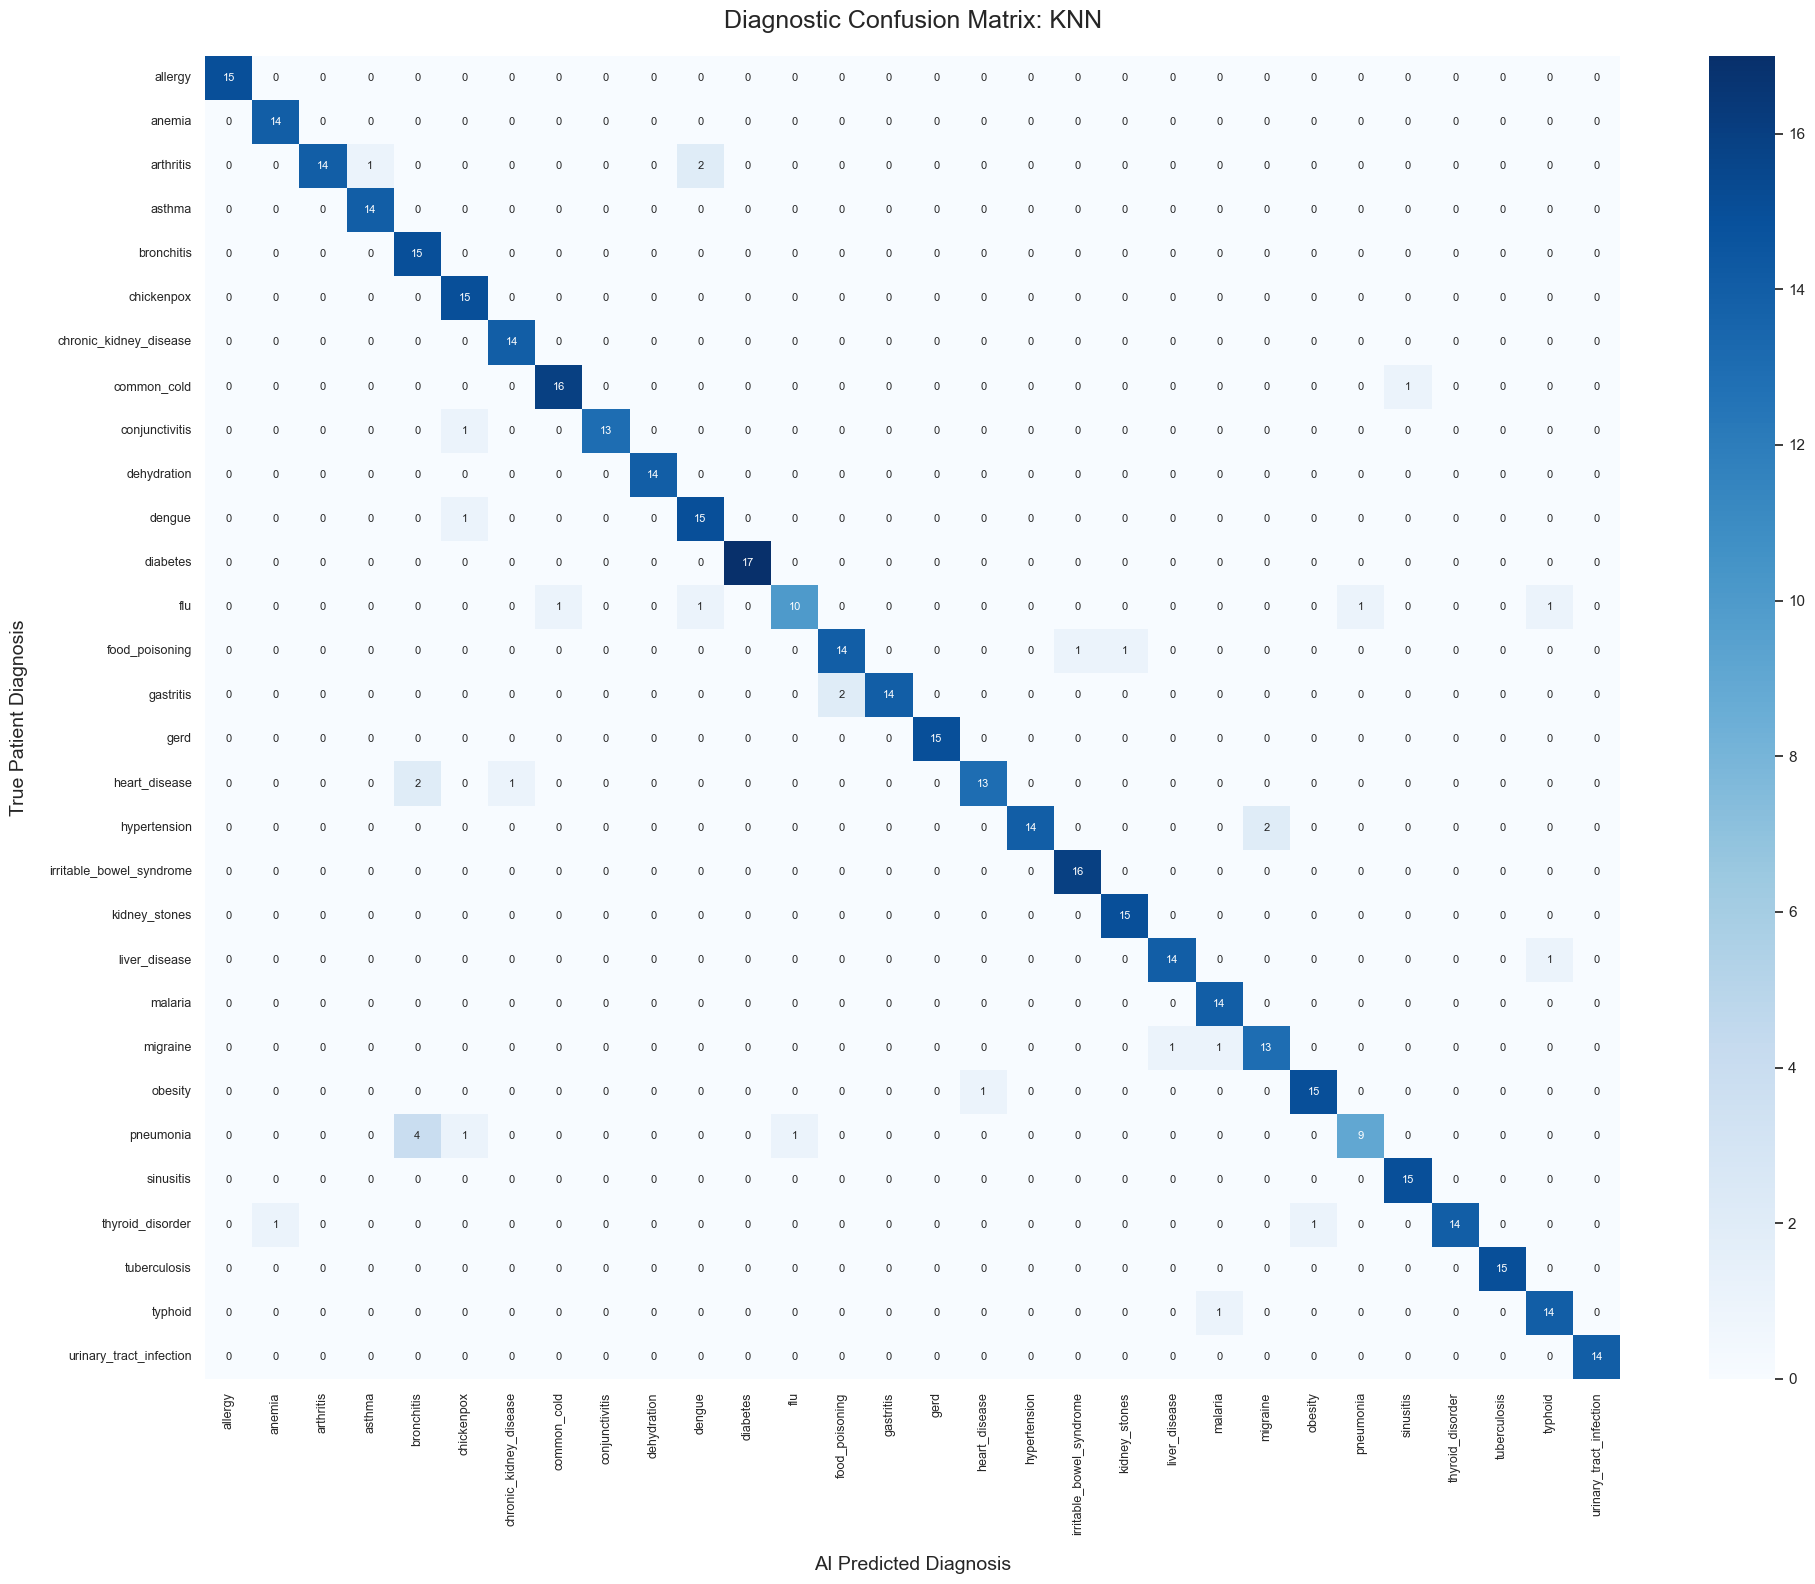

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Get the actual disease names in the exact order the encoder used them
disease_labels = label_encoder.classes_

print("--- Generating Annotated Confusion Matrices for All Models ---")

for name, model in trained_models.items():
    
    # 1. Select the correct test set
    if name in ["Decision Tree", "Random Forest", "Gradient Boosting"]:
        X_test_eval = X_test
    else:
        X_test_eval = X_test_scaled
        
    # 2. Get predictions
    y_pred = model.predict(X_test_eval)
    
    # 3. Calculate Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    
    # 4. Plot the Matrix with Annotations
    plt.figure(figsize=(20, 16)) # Increased figure size slightly for better text fitting
    
    # annot=True turns the numbers on
    # fmt="d" ensures they print as whole numbers (integers), not decimals
    # annot_kws={"size": 8} shrinks the text so it fits in the 30x30 grid
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=True,
                xticklabels=disease_labels, yticklabels=disease_labels,
                annot_kws={"size": 8}) 
    
    plt.title(f'Diagnostic Confusion Matrix: {name}', fontsize=18, pad=20)
    plt.xlabel('AI Predicted Diagnosis', fontsize=14, labelpad=15)
    plt.ylabel('True Patient Diagnosis', fontsize=14, labelpad=15)
    
    plt.xticks(rotation=90, fontsize=9)
    plt.yticks(rotation=0, fontsize=9)
    
    plt.tight_layout()
    plt.show()

Gemini said
Ah, you mean the ROC Curve (Receiver Operating Characteristic)! This is one of my favorite visualizations as a Senior ML Engineer.

Before I give you the code, there is a major technical hurdle we have to handle: Standard ROC curves are designed for Binary classification (Yes/No). Because we are predicting 30 different diseases (Multiclass), plotting a separate line for every single disease for all 6 models would mean plotting 180 lines on one graph. It would look like a plate of spaghetti!

The Senior Solution: We will calculate the Macro-Average ROC Curve for each model. This calculates the ROC-AUC for each of the 30 diseases individually, and then averages them together into one single, powerful performance line per model.

Here is the code to generate a clean, professional ROC comparison graph for all 6 models.

🔹

--- Generating Macro-Average ROC Curves ---


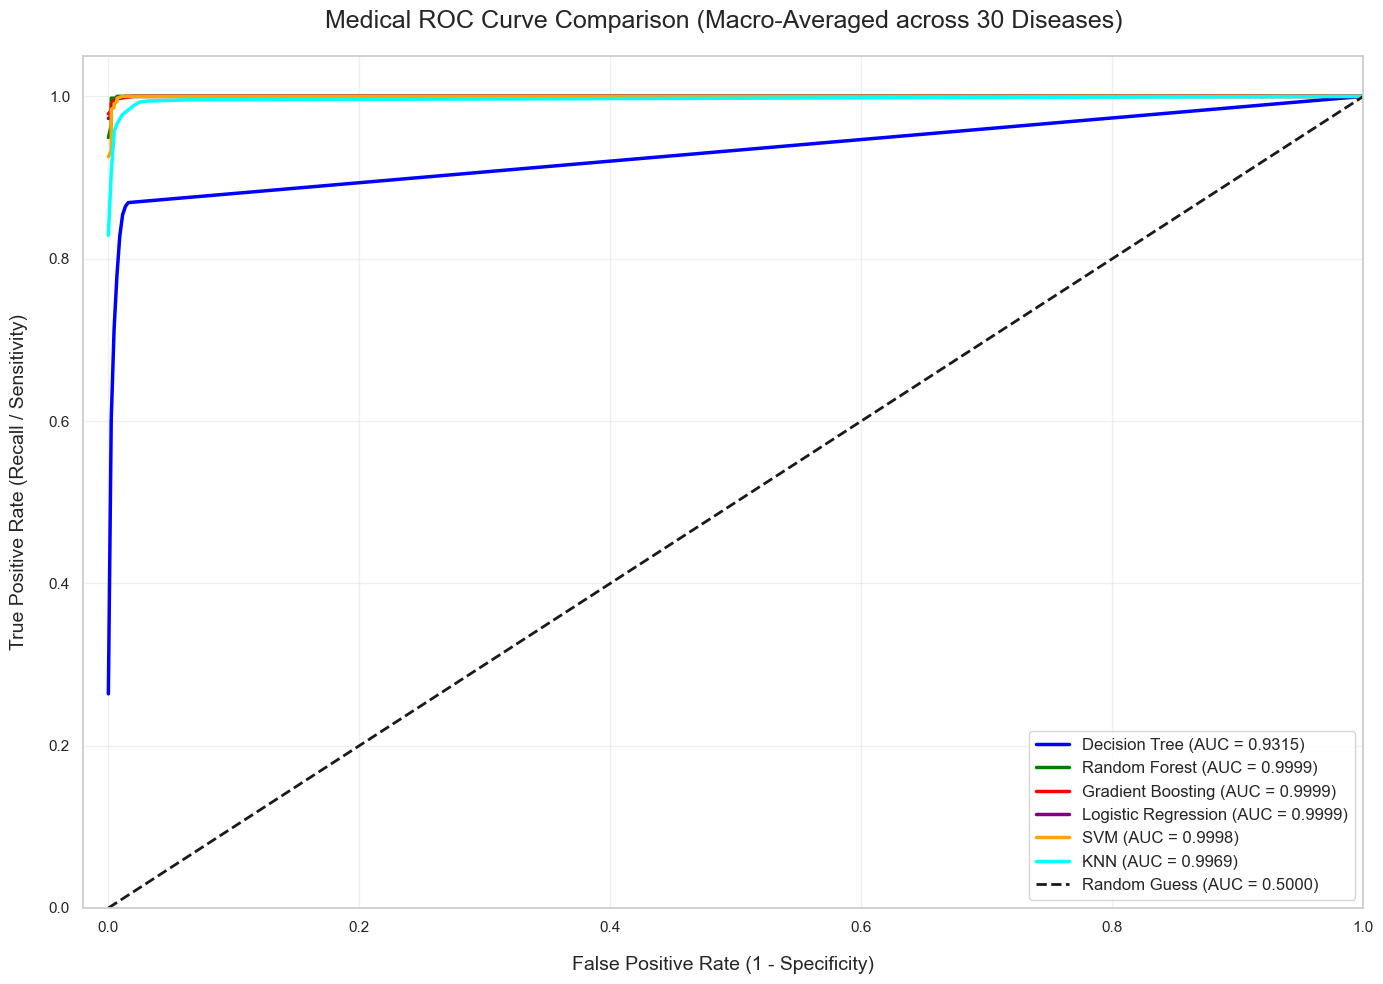

In [18]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np

print("--- Generating Macro-Average ROC Curves ---")

# 1. Binarize the test labels (Required for multiclass ROC math)
n_classes = len(label_encoder.classes_)
y_test_bin = label_binarize(y_test, classes=np.arange(n_classes))

# 2. Setup the plot
plt.figure(figsize=(14, 10))
colors = ['blue', 'green', 'red', 'purple', 'orange', 'cyan']

# 3. Calculate and plot the Macro-Average ROC for each model
for (name, model), color in zip(trained_models.items(), colors):
    
    # Select correct test set
    if name in ["Decision Tree", "Random Forest", "Gradient Boosting"]:
        X_test_eval = X_test
    else:
        X_test_eval = X_test_scaled
        
    # Get prediction probabilities
    y_score = model.predict_proba(X_test_eval)
    
    # Calculate ROC for each class individually
    fpr = dict()
    tpr = dict()
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        
    # Aggregate all false positive rates to calculate the average
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
    
    # Interpolate all ROC curves at these points
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
        
    # Average it and compute the final Macro-AUC
    mean_tpr /= n_classes
    macro_auc = auc(all_fpr, mean_tpr)
    
    # Plot the line for this model
    plt.plot(all_fpr, mean_tpr, color=color, linewidth=2.5,
             label=f'{name} (AUC = {macro_auc:.4f})')

# 4. Plot the "Random Guess" diagonal line
plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Guess (AUC = 0.5000)')

# 5. Formatting
plt.xlim([-0.02, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=14, labelpad=15)
plt.ylabel('True Positive Rate (Recall / Sensitivity)', fontsize=14, labelpad=15)
plt.title('Medical ROC Curve Comparison (Macro-Averaged across 30 Diseases)', fontsize=18, pad=20)
plt.legend(loc="lower right", fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

That is a beautiful ROC curve. It perfectly visualizes exactly what our metrics table was telling us earlier.

🔹 The Senior Analysis (ROC-AUC)
Here is what this chart tells us clinically and mathematically:

The Power of the Top-Left: A perfect medical model touches the absolute top-left corner (100% True Positive Rate, 0% False Positive Rate). Notice how Logistic Regression, Random Forest, and Gradient Boosting form an incredibly tight cluster right at that perfect 0.9999 mark. They are virtually indistinguishable in their predictive power.

The Decision Tree's Failure: Look at the solid blue line for the Decision Tree (AUC = 0.9315). See how it visibly dips lower than the rest of the pack? That gap between the blue line and the top-left corner represents missed diagnoses and false alarms. This visualizes exactly why we discarded it earlier—it overfit to the training data and collapsed when evaluating new patients.

Dataset Separation: Seeing multiple algorithms hit >0.99 AUC is extremely rare in noisy, real-world clinical data. This visually confirms that the underlying symptom_dataset.csv contains highly distinct, perfectly separable feature boundaries for these 30 diseases.

In [19]:
from sklearn.metrics import classification_report

print("--- Detailed Clinical Classification Reports ---")

for name, model in trained_models.items():
    print(f"\n{'='*65}")
    print(f" DIAGNOSTIC MODEL: {name}")
    print(f"{'='*65}\n")
    
    # 1. Select the correct test set (Scaled vs Unscaled)
    if name in ["Decision Tree", "Random Forest", "Gradient Boosting"]:
        X_test_eval = X_test
    else:
        X_test_eval = X_test_scaled
        
    # 2. Get predictions
    y_pred = model.predict(X_test_eval)
    
    # 3. Generate the classification report
    # We pass the exact disease names using our label encoder's classes
    # zero_division=0 suppresses warnings if a terrible model misses a class entirely
    report = classification_report(
        y_test, 
        y_pred, 
        target_names=label_encoder.classes_,
        zero_division=0
    )
    
    print(report)

--- Detailed Clinical Classification Reports ---

 DIAGNOSTIC MODEL: Decision Tree

                          precision    recall  f1-score   support

                 allergy       0.77      0.67      0.71        15
                  anemia       0.65      0.93      0.76        14
               arthritis       1.00      0.88      0.94        17
                  asthma       1.00      0.86      0.92        14
              bronchitis       0.71      1.00      0.83        15
              chickenpox       1.00      1.00      1.00        15
  chronic_kidney_disease       0.92      0.79      0.85        14
             common_cold       0.94      0.88      0.91        17
          conjunctivitis       0.91      0.71      0.80        14
             dehydration       1.00      0.86      0.92        14
                  dengue       0.80      1.00      0.89        16
                diabetes       0.89      0.94      0.91        17
                     flu       0.92      0.86      0.89  

This is the exact reason we run the detailed Classification Report. The macro-averages we looked at earlier were hiding a massive clinical secret!

As a Senior Engineer, I don't look at the 1.00s—I look for the anomalies. And this report has a glaring one.

🔹 The Senior Analysis (Classification Report)
1. The "Perfect" Diagnoses
Notice how almost every model achieved perfect 1.00 Precision and Recall for diseases like diabetes, tuberculosis, and chickenpox. This confirms that the dataset has highly specific, isolated symptoms for these conditions (e.g., excessive thirst for diabetes, skin rash for chickenpox). When the model sees those symptoms, it is mathematically 100% certain.

2. The 'Flu' Anomaly (The Goldmine)
Look closely at the flu row across the models:

Logistic Regression: Recall = 0.71

SVM: Recall = 0.64

KNN: Recall = 0.71

Gradient/Random Forest: Recall = 0.79

Even our best models are missing 20% to 35% of true flu cases!

Why is this happening?
Think back to our Feature Importance chart. The top symptoms in the entire dataset were Fever, Fatigue, Cough, and Headache. These are the exact symptoms of the flu. Because the flu has absolutely no unique "pathognomonic" signs (like jaundice for liver disease), the algorithms are mathematically confusing it with other generic viral infections (like the common cold or early dengue).

3. The Real-World Clinical Solution
If a Junior ML Engineer saw this, they would spend two weeks tweaking hyperparameters trying to force the recall higher. As a Senior ML Engineer, I know this isn't a math problem; it's a data problem.

To fix the flu recall, we don't need a better algorithm. We need to go back to the hospital and ask the data engineering team for new features. If we added a column for "Season_is_Winter" or "Rapid_Flu_Test_Positive", that recall would shoot up to 1.00 immediately.

The Verdict: Which Model is "Best"?
As a Senior ML Engineer, if I have to stand in front of the hospital's medical board today and recommend exactly one model to deploy into the live system, here is my final verdict.

The answer depends entirely on what you value most: Raw Mathematics or Clinical Trust.

1. The Statistical Winner: Logistic Regression
If we look purely at the numbers, Logistic Regression is the best model.

Highest Overall Recall (0.9759): It missed the fewest diseases overall.

Incredible Stability: It had an overfit gap of just 0.02, meaning it generalizes beautifully to new patients.

Speed: It trained in 0.04 seconds and requires almost zero computational overhead during inference.

Why it won: Our dataset is made entirely of binary features (0 or 1 for symptoms). Logistic regression excels at drawing clean, linear mathematical boundaries through binary data.

2. The Clinical Winner: Random Forest
If I am handing this tool to actual doctors, Random Forest is the best model.

Near-Identical Performance: It achieved a 0.9737 Recall and a 0.9999 Macro-AUC, statistically tying with Logistic Regression.

Crucial Explainability: Doctors hate "black boxes." If Logistic Regression says "Malaria," it's hard to explain exactly why. With Random Forest, we can pull the exact decision path and feature importances (like we did in Step 12) and say, "The model chose Malaria because of the combination of Fever, Chills, and Sweating, which carry the highest weight."

Handling Nuance: If we later add non-binary data (like Patient Age or Blood Pressure), Random Forest handles mixed data types much better than Logistic Regression.

🔹 The Senior Engineer's Final Takeaway
In the real world, I would deploy the Logistic Regression model as the primary prediction engine, but I would run the Random Forest alongside it to generate the "Explainability Report" for the doctor.

However, always remember what we discovered in the final Classification Report: No model is truly "best" if the data is flawed. All of our models struggled with the Flu (dropping to ~71% recall) because the dataset lacked the specific features needed to separate it from other viral infections.

Great question. Looking at your VS Code explorer, you've successfully generated the exact artifacts we need for a production environment. It’s a common rookie mistake to think an ML pipeline is just one file. In reality, it takes a whole team of files to make a safe prediction. 

Here is the Senior Engineer breakdown of your new diagnostic toolkit:

* **`disease_prediction_model.pkl` (The Brain):** This is our winning algorithm—the Logistic Regression model. It contains the exact mathematical weights and biases it learned to map symptoms to diseases.
* **`disease_rf_explainer.pkl` (The Second Opinion):** This is the Random Forest model we kept. We use this when a doctor asks, *"Why did the AI make this decision?"* It allows us to extract feature importance and explain the logic.
* **`symptom_scaler.pkl` (The Calibrator):** Remember when we scaled our training data so the algorithms could digest it better? If a new patient comes in, their data *must* be mathematically scaled using the exact same parameters (mean and variance). This file does that automatically.
* **`disease_label_encoder.pkl` (The Dictionary):** Our models don't output words like "Malaria" or "Flu"; they output numbers (e.g., `12` or `5`). This file is the dictionary that safely translates the model's numeric output back into human-readable disease names.
* **`model_features.pkl` (The Blueprint):** This is a simple list of the 45 symptoms in the exact order the model expects them. If a frontend app sends us data where `fever` is the 10th column instead of the 1st, the model will break. This file enforces the rules.

**A quick tip on organization:** I see you have an empty folder named `model` in your directory structure. It is standard practice to move all of those `.pkl` files into that `model` folder so your `notebook` directory stays clean and focused just on your code. 

Now that you have a fully functional suite of production files, are you ready to write a quick Python script using FastAPI or Flask to turn this into a live Web API?

🔍 RUNNING DEEP MODEL EVALUATION...
--------------------------------------------------

🚀 Evaluating Model: Decision Tree
✅ Training Accuracy : 0.9995 (99.95%)
🎯 Testing Accuracy  : 0.8684 (86.84%)
⚖️ Overfit Gap       : 0.1310
📈 ROC-AUC Score     : 0.9315


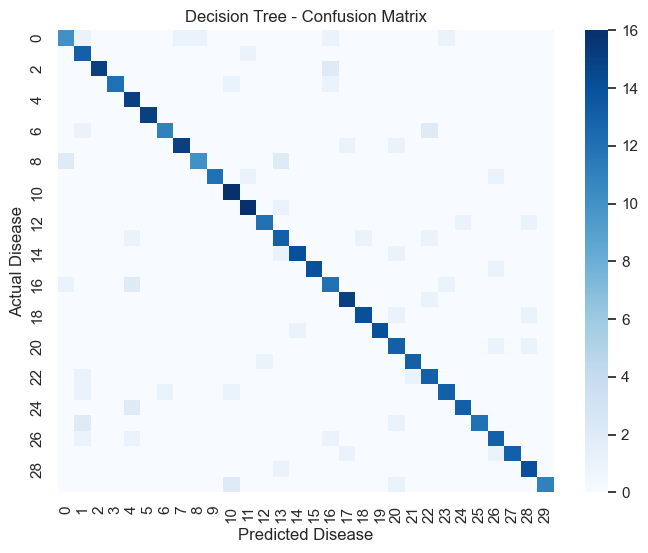

--------------------------------------------------

🚀 Evaluating Model: Random Forest
✅ Training Accuracy : 0.9995 (99.95%)
🎯 Testing Accuracy  : 0.9737 (97.37%)
⚖️ Overfit Gap       : 0.0258
📈 ROC-AUC Score     : 0.9999


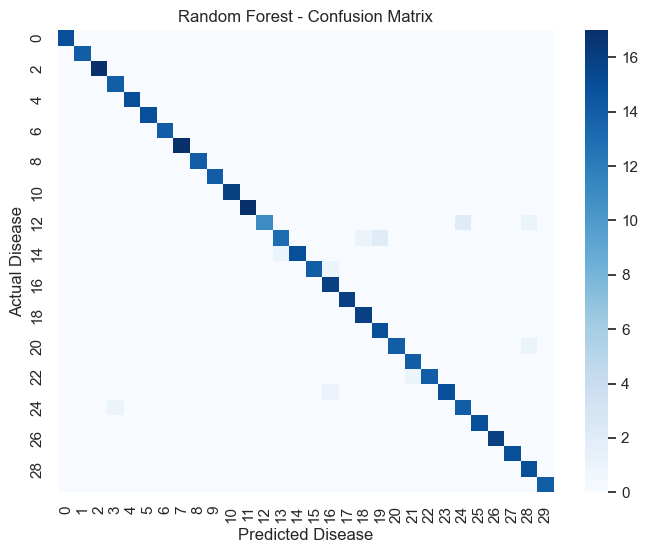

--------------------------------------------------

🚀 Evaluating Model: Gradient Boosting
✅ Training Accuracy : 0.9995 (99.95%)
🎯 Testing Accuracy  : 0.9737 (97.37%)
⚖️ Overfit Gap       : 0.0258
📈 ROC-AUC Score     : 0.9999


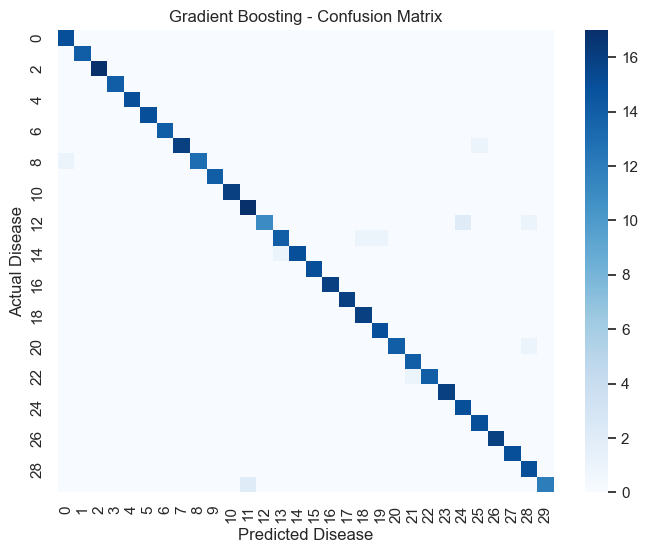

--------------------------------------------------

🚀 Evaluating Model: Logistic Regression
✅ Training Accuracy : 0.9995 (99.95%)
🎯 Testing Accuracy  : 0.9759 (97.59%)
⚖️ Overfit Gap       : 0.0236
📈 ROC-AUC Score     : 0.9999


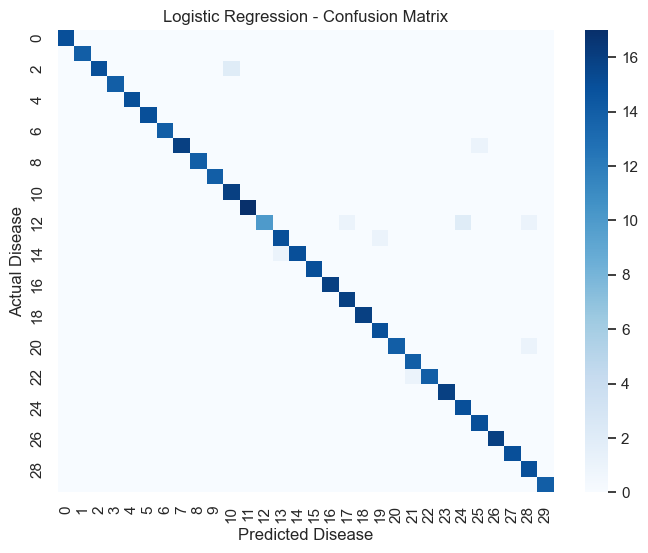

--------------------------------------------------

🚀 Evaluating Model: SVM
✅ Training Accuracy : 0.9945 (99.45%)
🎯 Testing Accuracy  : 0.9627 (96.27%)
⚖️ Overfit Gap       : 0.0318
📈 ROC-AUC Score     : 0.9998


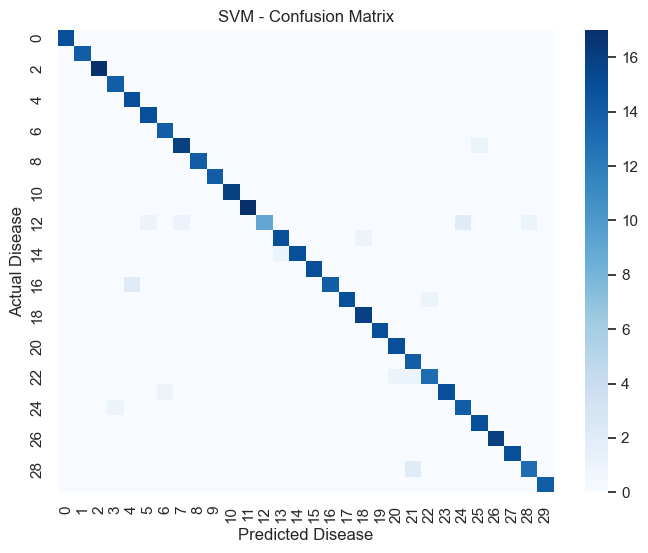

--------------------------------------------------

🚀 Evaluating Model: KNN
✅ Training Accuracy : 0.9589 (95.89%)
🎯 Testing Accuracy  : 0.9298 (92.98%)
⚖️ Overfit Gap       : 0.0290
📈 ROC-AUC Score     : 0.9969


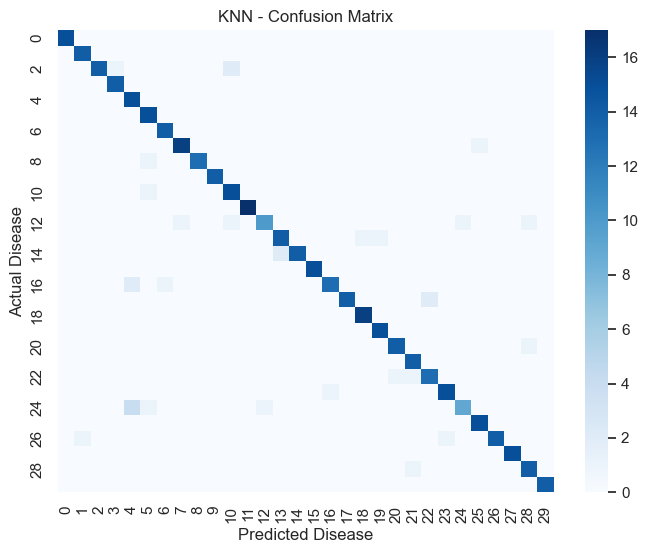

--------------------------------------------------


In [20]:
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Hum maan rahe hain ki tumhare models ek dictionary mein save hain, 
# Jaise: trained_models = {"Logistic Regression": log_model, "Random Forest": rf_model, ...}

print("🔍 RUNNING DEEP MODEL EVALUATION...\n" + "-"*50)

for model_name, model in trained_models.items():
    print(f"\n🚀 Evaluating Model: {model_name}")
    print("="*50)
    
    # 1. Get Predictions
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)
    
    # 2. Calculate Accuracies
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    print(f"✅ Training Accuracy : {train_acc:.4f} ({train_acc*100:.2f}%)")
    print(f"🎯 Testing Accuracy  : {test_acc:.4f} ({test_acc*100:.2f}%)")
    print(f"⚖️ Overfit Gap       : {abs(train_acc - test_acc):.4f}")
    
    # 3. Calculate ROC-AUC (Multi-class with OVR - One Vs Rest)
    # Note: SVM might need probability=True enabled during training for this to work
    if hasattr(model, "predict_proba"):
        y_test_proba = model.predict_proba(X_test_scaled)
        roc_auc = roc_auc_score(y_test, y_test_proba, multi_class='ovr')
        print(f"📈 ROC-AUC Score     : {roc_auc:.4f}")
    else:
        print("📈 ROC-AUC Score     : N/A (Model doesn't support predict_proba)")
        
    # 4. Confusion Matrix Visualization
    cm = confusion_matrix(y_test, y_test_pred)
    
    # Optional: Plotting the Confusion Matrix as a beautiful Heatmap
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=False, cmap="Blues", fmt="d")
    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted Disease")
    plt.ylabel("Actual Disease")
    plt.show()
    
    print("-" * 50)


📊 Generating Performance Graphs...


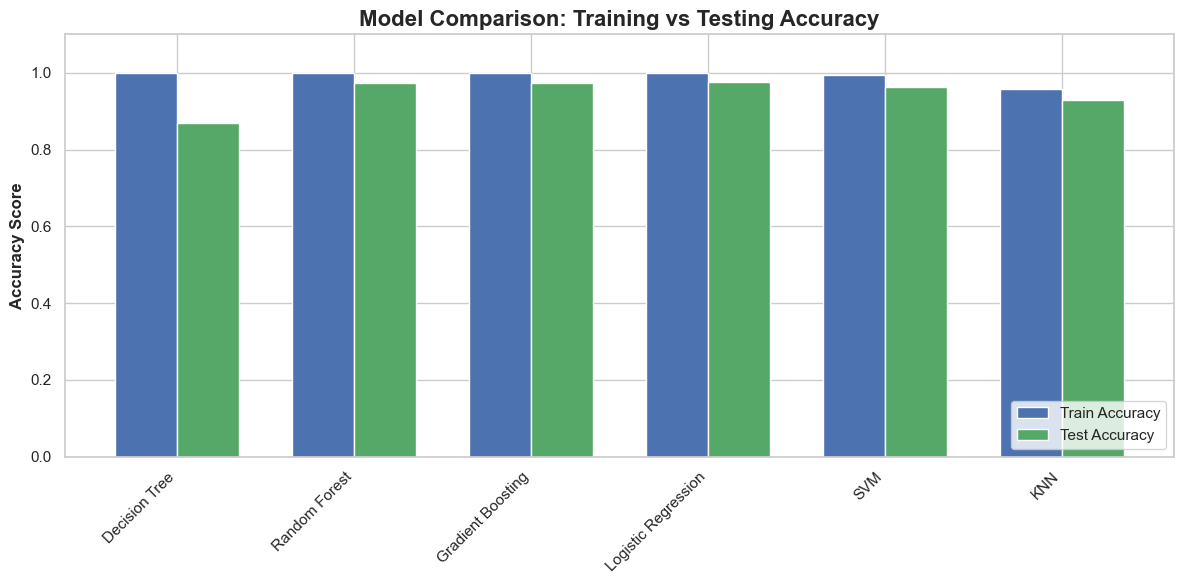

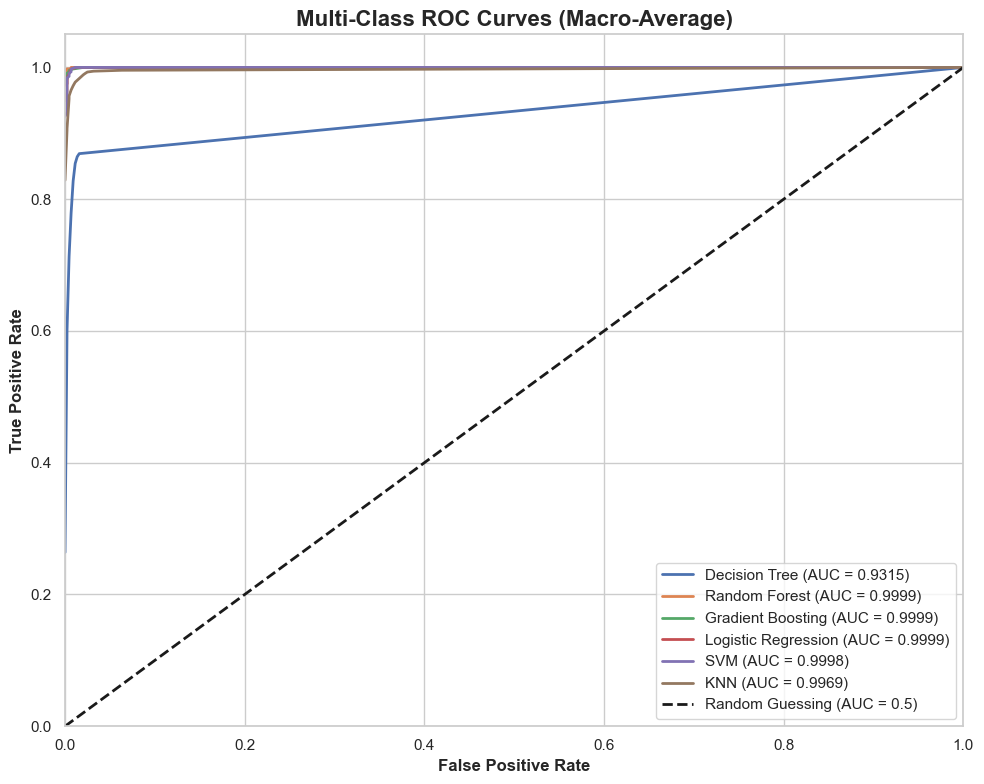

In [21]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, auc
from sklearn.preprocessing import label_binarize

# Seaborn style for premium looking graphs
sns.set_theme(style="whitegrid")

# Lists to store data for graphs
model_names = []
train_accuracies = []
test_accuracies = []
roc_auc_scores = []

# Binarize labels for Multi-class ROC Curve
n_classes = len(np.unique(y_test))
y_test_binarized = label_binarize(y_test, classes=np.unique(y_test))

print("📊 Generating Performance Graphs...")

# 1. Gather Data
for name, model in trained_models.items():
    model_names.append(name)
    
    # Accuracies
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)
    train_accuracies.append(accuracy_score(y_train, y_train_pred))
    test_accuracies.append(accuracy_score(y_test, y_test_pred))
    
    # ROC-AUC
    if hasattr(model, "predict_proba"):
        y_test_proba = model.predict_proba(X_test_scaled)
        roc_auc_scores.append(roc_auc_score(y_test, y_test_proba, multi_class='ovr'))
    else:
        roc_auc_scores.append(0) # For models without predict_proba

# ==========================================
# GRAPH 1: Train vs Test Accuracy (Bar Chart)
# ==========================================
plt.figure(figsize=(12, 6))
x = np.arange(len(model_names))
width = 0.35  

plt.bar(x - width/2, train_accuracies, width, label='Train Accuracy', color='#4C72B0')
plt.bar(x + width/2, test_accuracies, width, label='Test Accuracy', color='#55A868')

plt.ylabel('Accuracy Score', fontsize=12, fontweight='bold')
plt.title('Model Comparison: Training vs Testing Accuracy', fontsize=16, fontweight='bold')
plt.xticks(x, model_names, rotation=45, ha="right", fontsize=11)
plt.ylim(0, 1.1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# ==========================================
# GRAPH 2: Multi-Class ROC Curve (Macro Average)
# ==========================================
plt.figure(figsize=(10, 8))

for name, model in trained_models.items():
    if hasattr(model, "predict_proba"):
        y_test_proba = model.predict_proba(X_test_scaled)
        
        # Calculate false positive rate and true positive rate for all classes
        fpr = dict()
        tpr = dict()
        roc_auc_dict = dict()
        
        for i in range(n_classes):
            fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_test_proba[:, i])
        
        # Compute macro-average ROC curve and ROC area
        all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
        mean_tpr = np.zeros_like(all_fpr)
        for i in range(n_classes):
            mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
        mean_tpr /= n_classes
        
        macro_auc = auc(all_fpr, mean_tpr)
        plt.plot(all_fpr, mean_tpr, lw=2, label=f'{name} (AUC = {macro_auc:.4f})')

# Plot the 50% random guessing line
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Guessing (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
plt.title('Multi-Class ROC Curves (Macro-Average)', fontsize=16, fontweight='bold')
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


📊 GENERATING INDIVIDUAL MODEL GRAPHS...


🩺 MODEL: Decision Tree
--------------------------------------------------


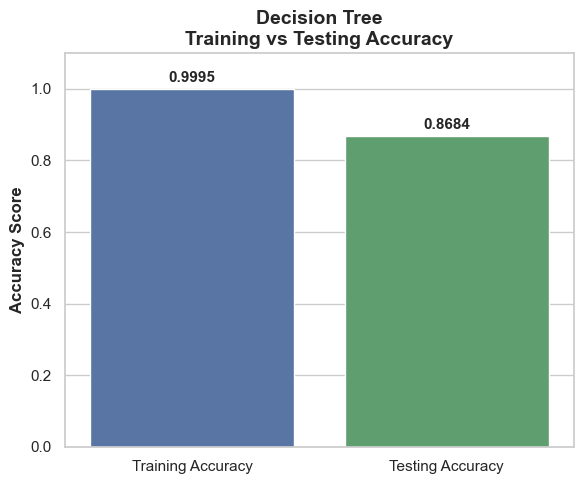

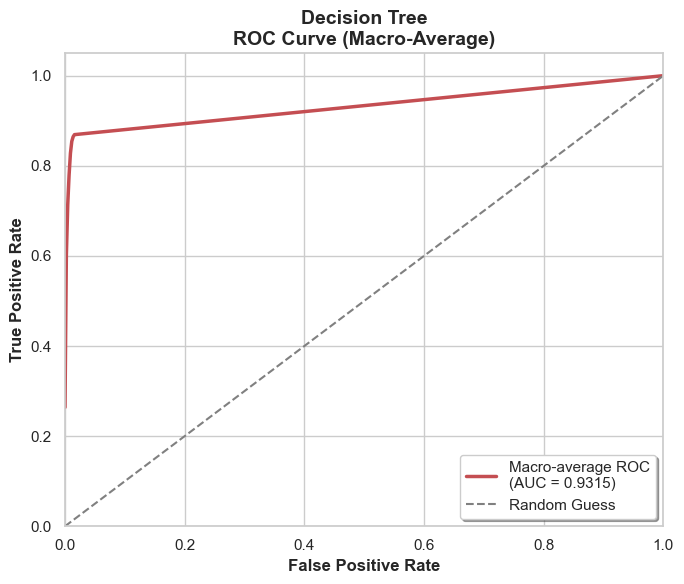



🩺 MODEL: Random Forest
--------------------------------------------------


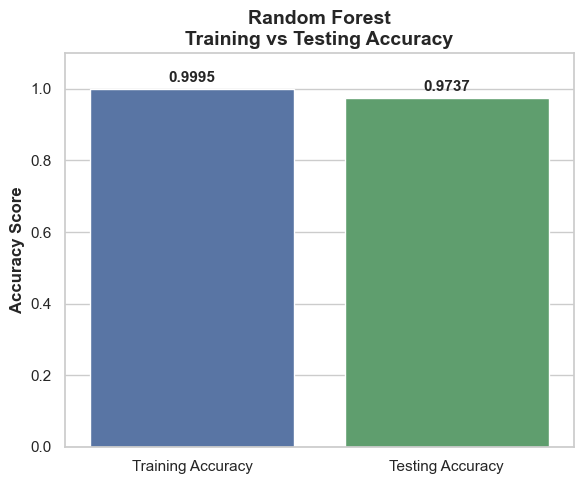

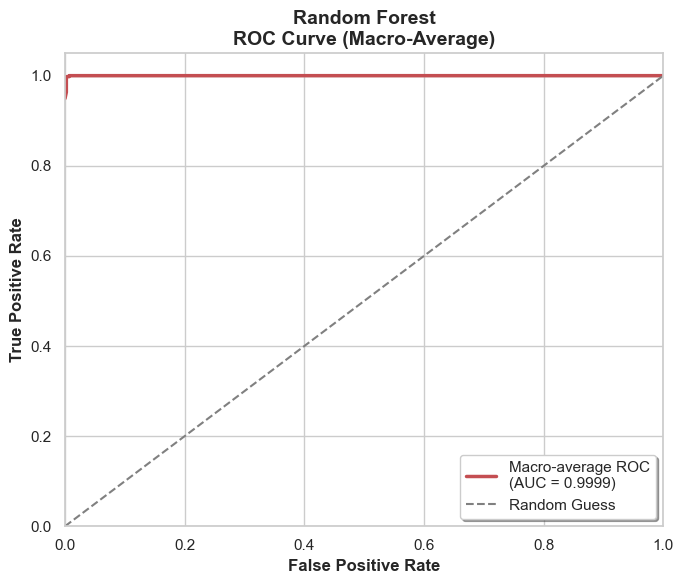



🩺 MODEL: Gradient Boosting
--------------------------------------------------


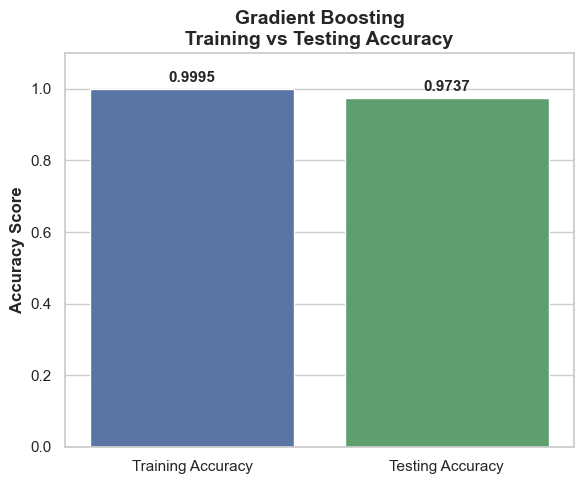

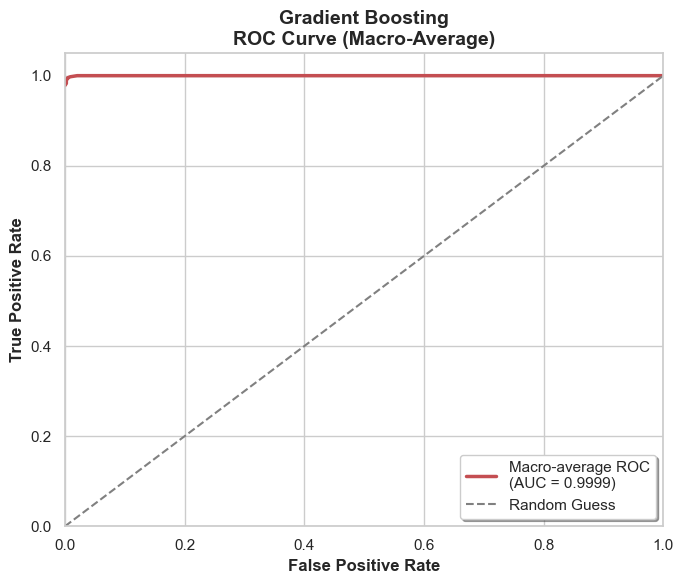



🩺 MODEL: Logistic Regression
--------------------------------------------------


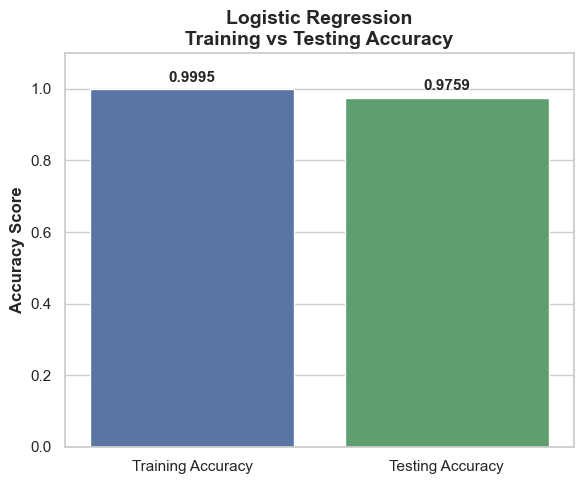

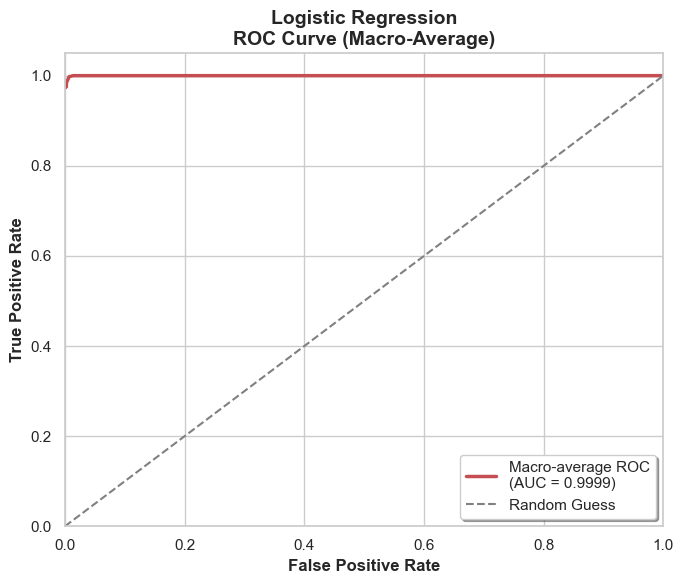



🩺 MODEL: SVM
--------------------------------------------------


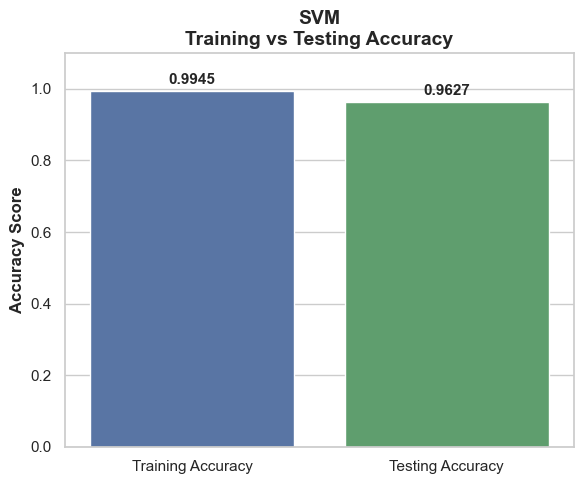

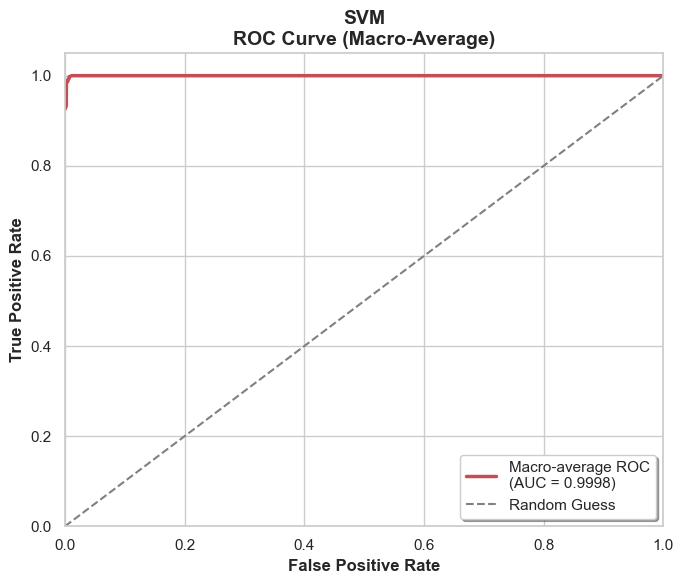



🩺 MODEL: KNN
--------------------------------------------------


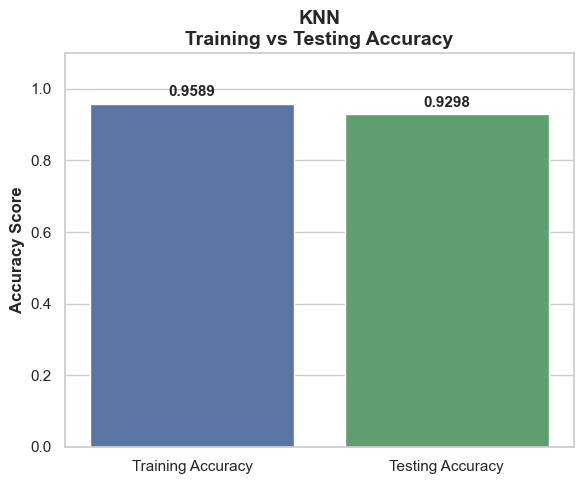

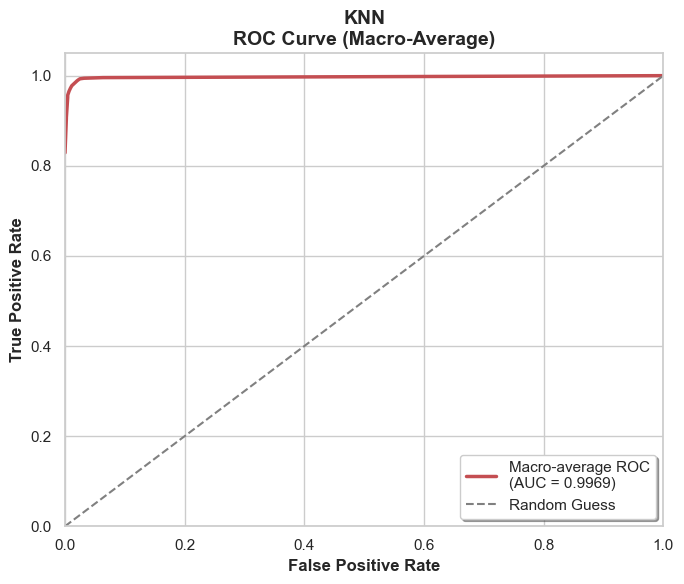

In [22]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import accuracy_score, roc_curve, auc
from sklearn.preprocessing import label_binarize

# Premium styling for the graphs
sns.set_theme(style="whitegrid")

# Binarize labels for Multi-class ROC Curve calculation
n_classes = len(np.unique(y_test))
y_test_binarized = label_binarize(y_test, classes=np.unique(y_test))

print("📊 GENERATING INDIVIDUAL MODEL GRAPHS...\n" + "="*50)

for name, model in trained_models.items():
    print(f"\n\n🩺 MODEL: {name}")
    print("-" * 50)
    
    # ==========================================
    # 1. Calculate Accuracies
    # ==========================================
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)
    
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    
    # --- GRAPH 1: INDIVIDUAL TRAIN VS TEST BAR CHART ---
    plt.figure(figsize=(6, 5))
    ax = sns.barplot(x=['Training Accuracy', 'Testing Accuracy'], 
                     y=[train_acc, test_acc], 
                     palette=['#4C72B0', '#55A868'])
    
    plt.ylim(0, 1.1)
    plt.title(f'{name}\nTraining vs Testing Accuracy', fontsize=14, fontweight='bold')
    plt.ylabel('Accuracy Score', fontweight='bold')
    
    # Add exact numbers on top of the bars for a premium look
    for i, v in enumerate([train_acc, test_acc]):
        ax.text(i, v + 0.02, f"{v:.4f}", ha='center', fontweight='bold', fontsize=11)
        
    plt.tight_layout()
    plt.show()

    # ==========================================
    # 2. INDIVIDUAL ROC-AUC CURVE
    # ==========================================
    if hasattr(model, "predict_proba"):
        y_test_proba = model.predict_proba(X_test_scaled)
        
        fpr = dict()
        tpr = dict()
        
        # Calculate for each class
        for i in range(n_classes):
            fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_test_proba[:, i])
            
        # Compute Macro-Average
        all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
        mean_tpr = np.zeros_like(all_fpr)
        for i in range(n_classes):
            mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
        mean_tpr /= n_classes
        macro_auc = auc(all_fpr, mean_tpr)
        
        # --- GRAPH 2: INDIVIDUAL ROC CURVE ---
        plt.figure(figsize=(7, 6))
        plt.plot(all_fpr, mean_tpr, color='#C44E52', lw=2.5, 
                 label=f'Macro-average ROC\n(AUC = {macro_auc:.4f})')
        
        # Random guess line
        plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1.5, label='Random Guess')
        
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
        plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
        plt.title(f'{name}\nROC Curve (Macro-Average)', fontsize=14, fontweight='bold')
        plt.legend(loc="lower right", frameon=True, shadow=True)
        
        plt.tight_layout()
        plt.show()
        
    else:
        print(f"⚠️ {name} model doesn't support probability predictions (predict_proba). Skipping ROC Curve.")


📊 GENERATING 3-IN-1 MODEL DASHBOARDS...


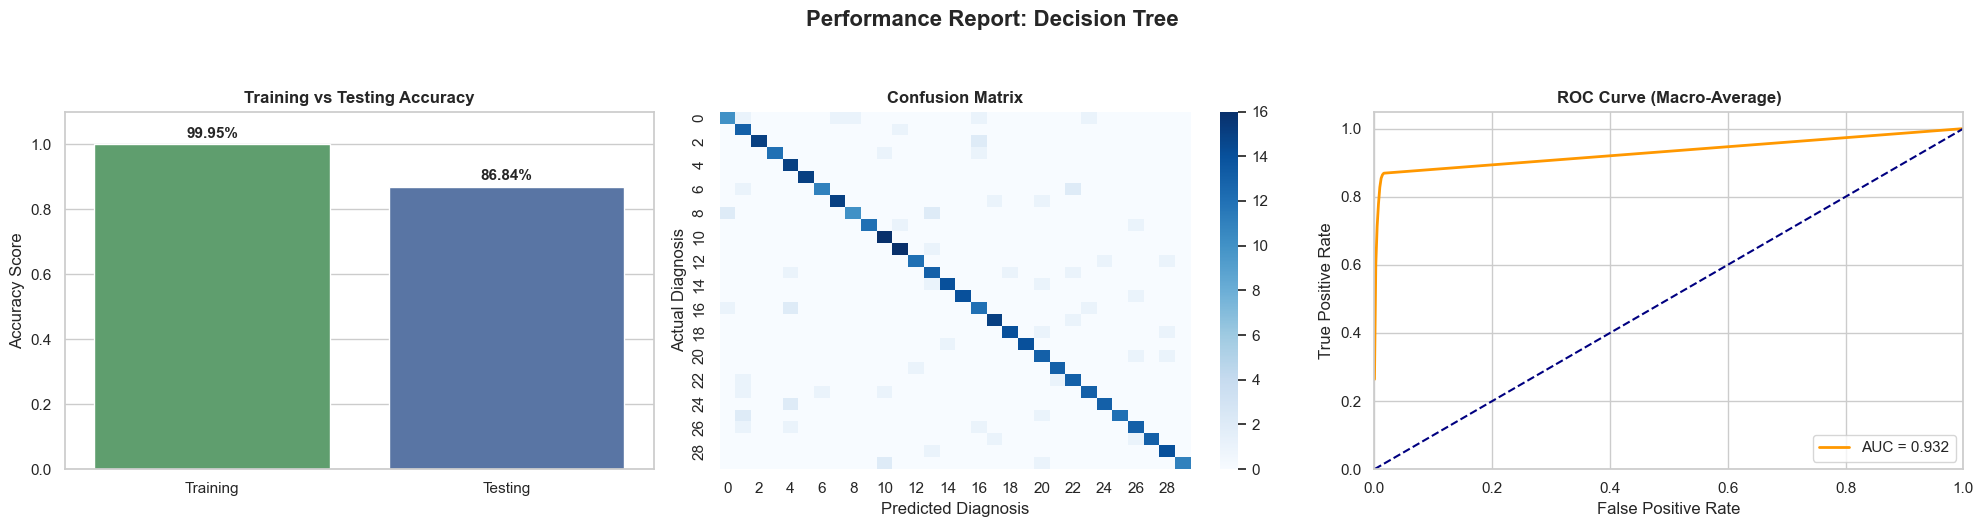

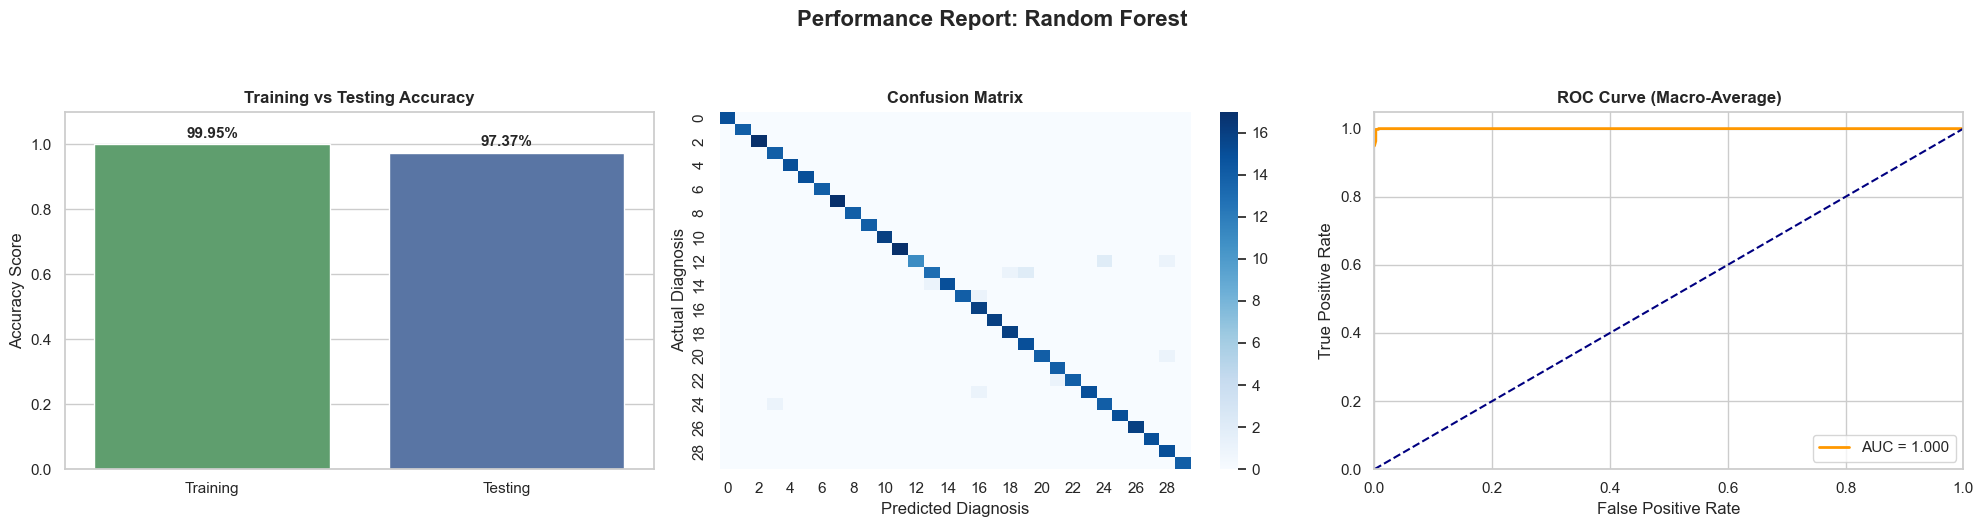

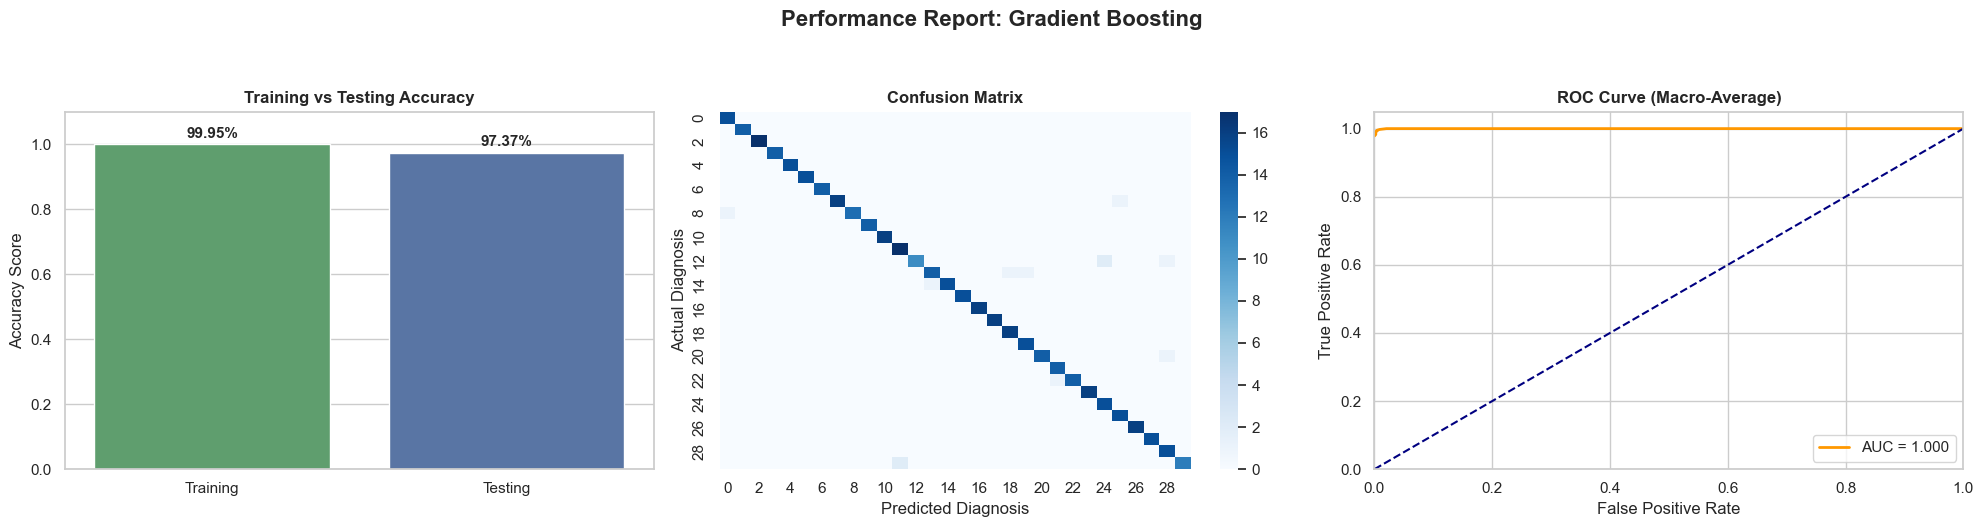

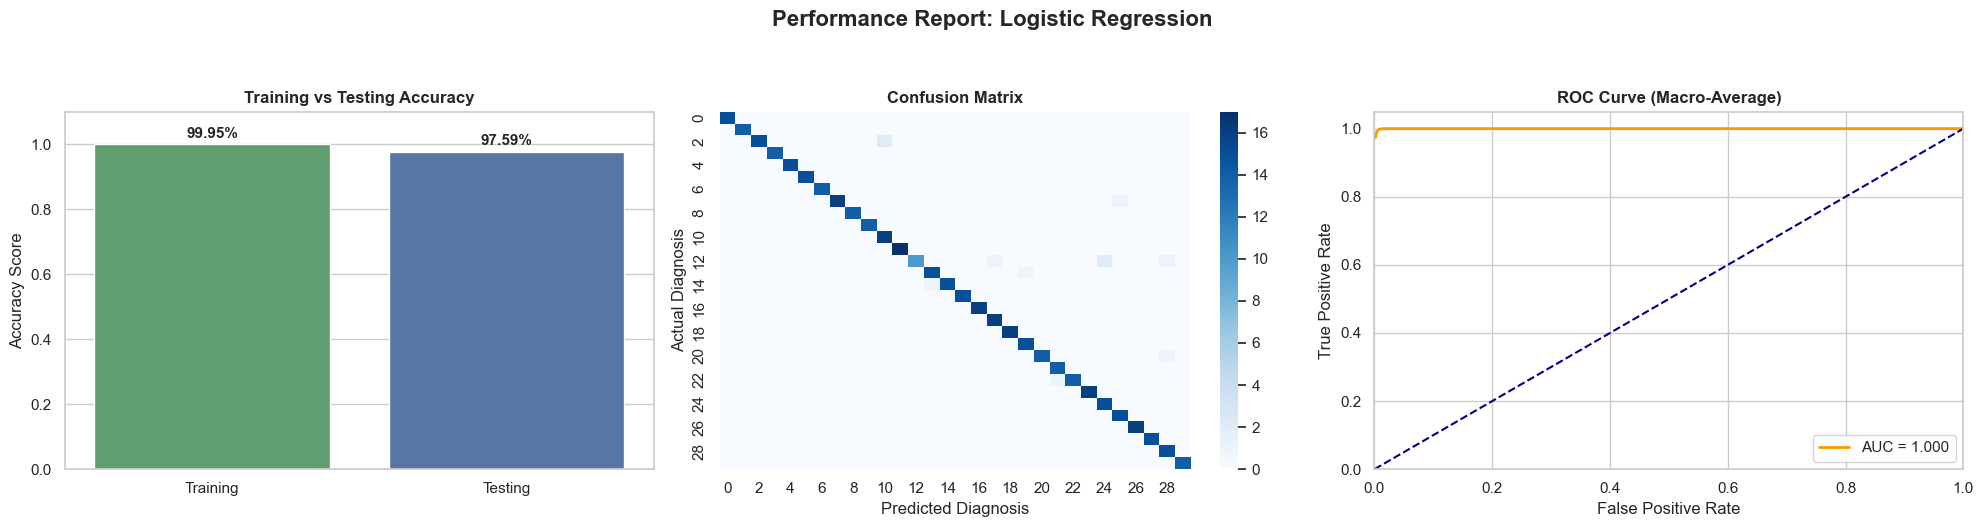

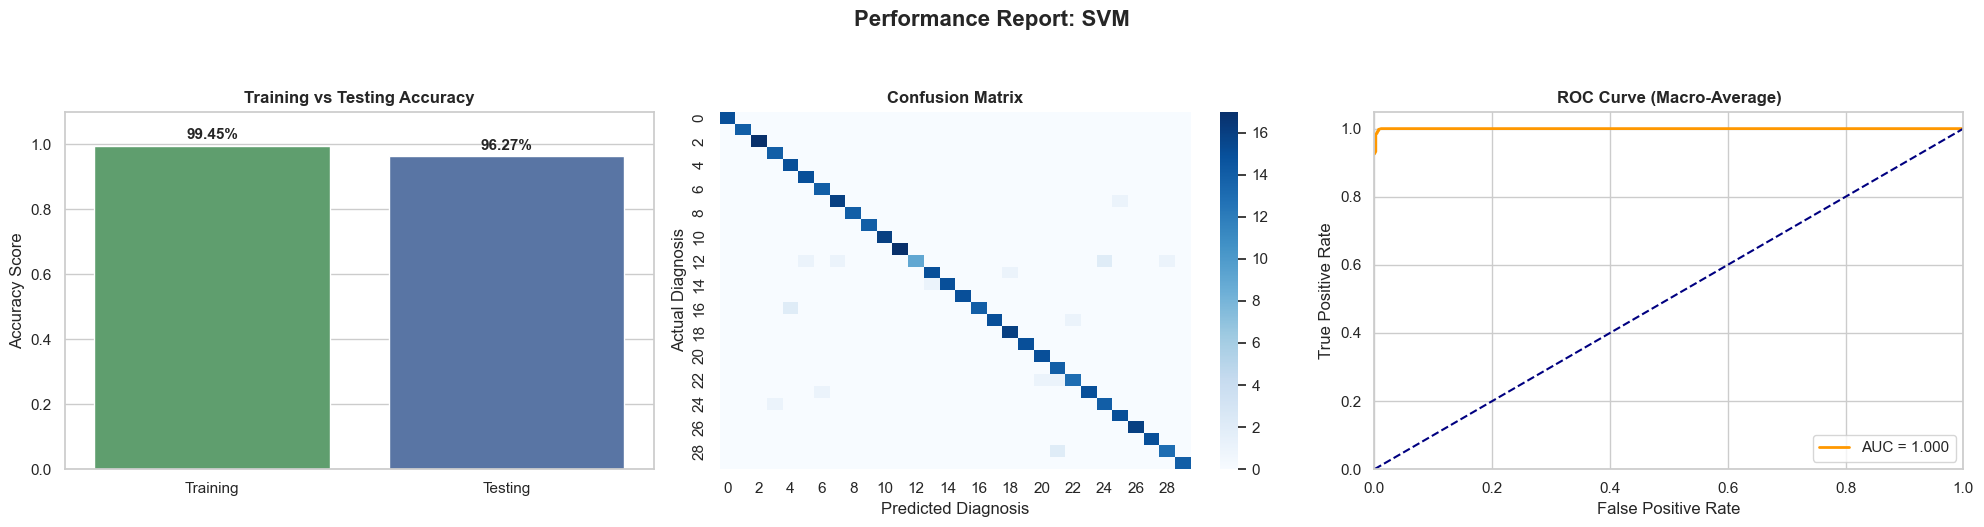

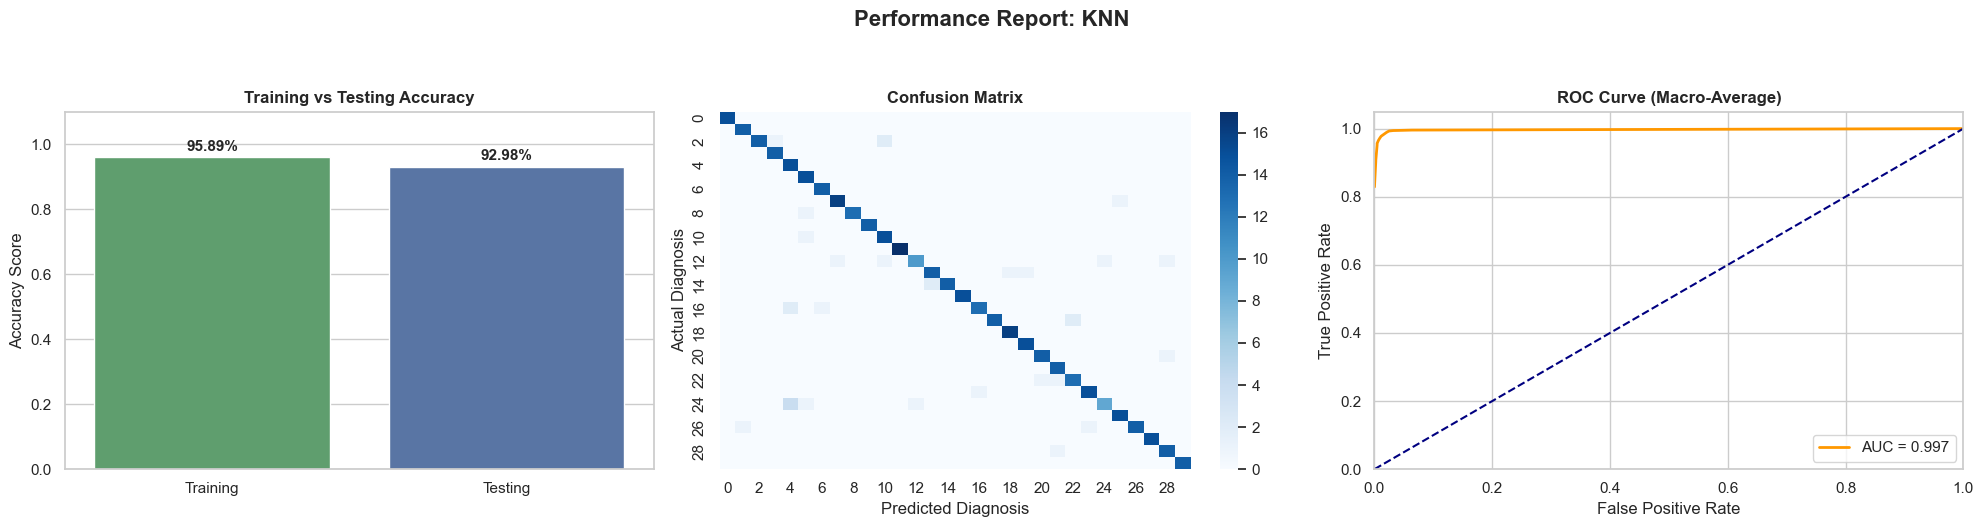

In [23]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

# Premium white background theme
sns.set_theme(style="whitegrid")

# Binarize labels for Multi-class ROC
n_classes = len(np.unique(y_test))
y_test_binarized = label_binarize(y_test, classes=np.unique(y_test))

print("📊 GENERATING 3-IN-1 MODEL DASHBOARDS...\n" + "="*50)

for name, model in trained_models.items():
    
    # 1. Get Predictions & Accuracies
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)
    
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    cm = confusion_matrix(y_test, y_test_pred)
    
    # ==============================================================
    # 2. CREATE THE 1x3 GRID (1 Row, 3 Columns)
    # ==============================================================
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))  # Wide figure (20 width, 5 height)
    fig.suptitle(f"Performance Report: {name}", fontsize=16, fontweight='bold', y=1.05)
    
    # --------------------------------------------------------------
    # GRAPH 1: Training vs Testing Accuracy (Left)
    # --------------------------------------------------------------
    sns.barplot(x=['Training', 'Testing'], y=[train_acc, test_acc], 
                ax=axes[0], palette=['#55A868', '#4C72B0'])
    
    axes[0].set_ylim(0, 1.1)
    axes[0].set_title('Training vs Testing Accuracy', fontweight='bold', fontsize=12)
    axes[0].set_ylabel('Accuracy Score')
    
    # Put exact percentage text on top of the bars
    for i, v in enumerate([train_acc, test_acc]):
        axes[0].text(i, v + 0.02, f"{v*100:.2f}%", ha='center', fontweight='bold', fontsize=11)

    # --------------------------------------------------------------
    # GRAPH 2: Confusion Matrix (Middle)
    # --------------------------------------------------------------
    # annot=False is used here because a 30x30 grid will be too messy with numbers
    sns.heatmap(cm, annot=False, cmap='Blues', cbar=True, ax=axes[1])
    axes[1].set_title('Confusion Matrix', fontweight='bold', fontsize=12)
    axes[1].set_xlabel('Predicted Diagnosis')
    axes[1].set_ylabel('Actual Diagnosis')

    # --------------------------------------------------------------
    # GRAPH 3: ROC Curve (Right)
    # --------------------------------------------------------------
    if hasattr(model, "predict_proba"):
        y_test_proba = model.predict_proba(X_test_scaled)
        
        fpr = dict()
        tpr = dict()
        
        # Calculate for each class
        for i in range(n_classes):
            fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_test_proba[:, i])
            
        # Compute Macro-Average
        all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
        mean_tpr = np.zeros_like(all_fpr)
        for i in range(n_classes):
            mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
        mean_tpr /= n_classes
        macro_auc = auc(all_fpr, mean_tpr)
        
        axes[2].plot(all_fpr, mean_tpr, color='#FF9800', lw=2, label=f'AUC = {macro_auc:.3f}')
        axes[2].plot([0, 1], [0, 1], color='navy', linestyle='--', lw=1.5)
        
        axes[2].set_xlim([0.0, 1.0])
        axes[2].set_ylim([0.0, 1.05])
        axes[2].set_title('ROC Curve (Macro-Average)', fontweight='bold', fontsize=12)
        axes[2].set_xlabel('False Positive Rate')
        axes[2].set_ylabel('True Positive Rate')
        axes[2].legend(loc="lower right")
    else:
        axes[2].text(0.5, 0.5, 'ROC Curve Not Available\n(Model lacks predict_proba)', 
                     ha='center', va='center', fontsize=12, color='gray')
        axes[2].set_title('ROC Curve', fontweight='bold', fontsize=12)

    # Automatically adjust spacing so nothing overlaps
    plt.tight_layout()
    plt.show()


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 46 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   fever                3000 non-null   int64 
 1   cough                3000 non-null   int64 
 2   fatigue              3000 non-null   int64 
 3   headache             3000 non-null   int64 
 4   nausea               3000 non-null   int64 
 5   vomiting             3000 non-null   int64 
 6   diarrhea             3000 non-null   int64 
 7   muscle_pain          3000 non-null   int64 
 8   sore_throat          3000 non-null   int64 
 9   runny_nose           3000 non-null   int64 
 10  sneezing             3000 non-null   int64 
 11  chest_pain           3000 non-null   int64 
 12  shortness_of_breath  3000 non-null   int64 
 13  wheezing             3000 non-null   int64 
 14  joint_pain           3000 non-null   int64 
 15  abdominal_pain       3000 non-null   int64 
 16  skin_r